# WWTW CNN — Model Comparison (all facilities)

Loads every pickled result under `../results/` -- one per (architecture, held-out facility)
combination produced by `run.py` (or by running the training notebooks by hand) -- and builds
a comparison table, accuracy/AUC charts, and a per-facility/per-model gallery of confusion
matrices, ROC curves, and training curves (train/val/test loss and accuracy).

Doesn't need a GPU, torch, or any of the trained models in memory. Everything here comes from
the small pickled metrics/history dicts plus the PNGs `wwtw_utils.py` already saved to
`../results/figures/` during training.

Set `COMPONENT` below to whichever component you want to compare (`aerobic_zone` or
`clarifier`) -- results are saved per-component, so training both won't overwrite each other,
but you do need to pick one here to compare.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"

COMPONENT = "clarifier"   # or "aerobic_zone" -- must match what you trained

# save_name -> display name, matches TRAIN_NOTEBOOKS in run.py / ARCH_HYPERPARAMS in wwtw_utils.py
MODELS = {
    "resnet18": "ResNet-18",
    "resnet50": "ResNet-50",
    "densenet121": "DenseNet-121",
    "inception_v3": "InceptionNet v3",
    "efficientnet_b0": "EfficientNet-B0",
    "convnext_tiny": "ConvNeXt-Tiny",
}

# Matches ALL_FACILITIES in split_dataset_facility.py / run.py.
ALL_FACILITIES = ["Atlantis", "CapeFlats", "Waterval", "Fisantekraal", "NoordelikeWerke"]


def slugify(name: str) -> str:
    # Must match _slugify() in wwtw_utils.py, since that's what the saved
    # figure filenames were built with.
    return name.strip().lower().replace(" ", "_").replace("-", "_")


def figure_path(model_name: str, facility: str, kind: str) -> Path:
    return FIGURES_DIR / f"{COMPONENT}_{slugify(model_name)}_{facility}_{kind}.png"

## Load the pickled results

In [2]:
# results[facility][save_name] = payload dict (as written by save_result()).
# Missing combinations (not yet trained) are skipped with a note rather than
# raising, so this still works fine with a partially finished run.
results = {}
missing = []
for facility in ALL_FACILITIES:
    results[facility] = {}
    for save_name in MODELS:
        path = RESULTS_DIR / f"results_{COMPONENT}_{save_name}_{facility}.pkl"
        if not path.exists():
            missing.append(str(path))
            continue
        with open(path, "rb") as f:
            results[facility][save_name] = pickle.load(f)

n_loaded = sum(len(v) for v in results.values())
n_total = len(ALL_FACILITIES) * len(MODELS)
print(f"Loaded {n_loaded} / {n_total} (facility, model) results.")
if missing:
    print(f"\nMissing ({len(missing)}) -- run these via run.py or the corresponding training notebook:")
    for m in missing:
        print(f"  {m}")

Loaded 30 / 30 (facility, model) results.


## Comparison table

Precision/recall/F1 are macro-averaged across classes (unweighted mean over classes, so a
rare class counts as much as a common one). Rows come only from the `classification_report`
now persisted in each results pickle -- if you're loading an older pickle saved before that
was added, those columns show as NaN for that row.

In [3]:
rows = []
for facility, by_model in results.items():
    for save_name, r in by_model.items():
        report = r.get("classification_report") or {}
        macro = report.get("macro avg", {})
        rows.append({
            "facility": facility,
            "model": MODELS[save_name],
            "test_accuracy": r["test_acc"],
            "mean_auc": r["mean_auc"],
            "macro_precision": macro.get("precision", np.nan),
            "macro_recall": macro.get("recall", np.nan),
            "macro_f1": macro.get("f1-score", np.nan),
        })

comparison = pd.DataFrame(rows).set_index(["facility", "model"]).sort_index()
display(comparison)

test_accuracy  mean_auc  macro_precision  \
facility        model                                                       
Atlantis        ConvNeXt-Tiny         0.822222  0.972471         0.678571   
                DenseNet-121          0.866667  0.983103         0.684265   
                EfficientNet-B0       0.877778  0.974428         0.688630   
                InceptionNet v3       0.866667  0.963334         0.687500   
                ResNet-18             0.811111  0.956989         0.668269   
                ResNet-50             0.722222  0.899738         0.583425   
CapeFlats       ConvNeXt-Tiny         0.724255  0.867970         0.677958   
                DenseNet-121          0.686992  0.875847         0.677770   
                EfficientNet-B0       0.651762  0.896717         0.690803   
                InceptionNet v3       0.720190  0.868924         0.710698   
                ResNet-18             0.565718  0.855707         0.622248   
                ResNet-50             0.694444  0.885341         0.684607   
Fisantekraal    ConvNeXt-Tiny         0.603175  0.904515         0.773238   
                DenseNet-121          0.777778  0.930546         0.713306   
                EfficientNet-B0       0.750000  0.934944         0.819796   
                InceptionNet v3       0.750000  0.925360         0.708332   
                ResNet-18             0.678571  0.876403         0.538793   
                ResNet-50             0.738095  0.929720         0.761934   
NoordelikeWerke ConvNeXt-Tiny         0.797531  0.922249         0.739723   
                DenseNet-121          0.861728  0.953529         0.782581   
                EfficientNet-B0       0.780247  0.945323         0.745355   
                InceptionNet v3       0.753086  0.919463         0.745906   
                ResNet-18             0.802469  0.927480         0.662263   
                ResNet-50             0.725926  0.901181         0.694720   
Waterval        ConvNeXt-Tiny         0.792254  0.923287         0.526883   
                DenseNet-121          0.901408  0.977488         0.695469   
                EfficientNet-B0       0.845070  0.928905         0.643622   
                InceptionNet v3       0.799296  0.928945         0.505891   
                ResNet-18             0.823944  0.938620         0.546898   
                ResNet-50             0.760563  0.871643         0.605268   

                                 macro_recall  macro_f1  
facility        model                                    
Atlantis        ConvNeXt-Tiny        0.673077  0.662879  
                DenseNet-121         0.613782  0.634134  
                EfficientNet-B0      0.618590  0.639803  
                InceptionNet v3      0.535256  0.565269  
                ResNet-18            0.668269  0.652299  
                ResNet-50            0.627473  0.576014  
CapeFlats       ConvNeXt-Tiny        0.720705  0.694285  
                DenseNet-121         0.679082  0.663530  
                EfficientNet-B0      0.686771  0.653087  
                InceptionNet v3      0.678725  0.690682  
                ResNet-18            0.580708  0.558525  
                ResNet-50            0.623029  0.641342  
Fisantekraal    ConvNeXt-Tiny        0.738596  0.696075  
                DenseNet-121         0.703110  0.697321  
                EfficientNet-B0      0.814261  0.804945  
                InceptionNet v3      0.766866  0.729807  
                ResNet-18            0.592331  0.544338  
                ResNet-50            0.782855  0.769880  
NoordelikeWerke ConvNeXt-Tiny        0.724605  0.708472  
                DenseNet-121         0.699622  0.718537  
                EfficientNet-B0      0.656963  0.682363  
                InceptionNet v3      0.679515  0.695754  
                ResNet-18            0.621371  0.633127  
                ResNet-50            0.616701  0.617522  
Waterval        ConvNeXt-Tiny        0.590024  0.544995  
  

## Accuracy and AUC across facilities

One bar group per held-out facility, one bar per architecture -- this is the actual
leave-one-facility-out generalization picture: how consistently each architecture holds up
across *different* unseen facilities, not just its average.

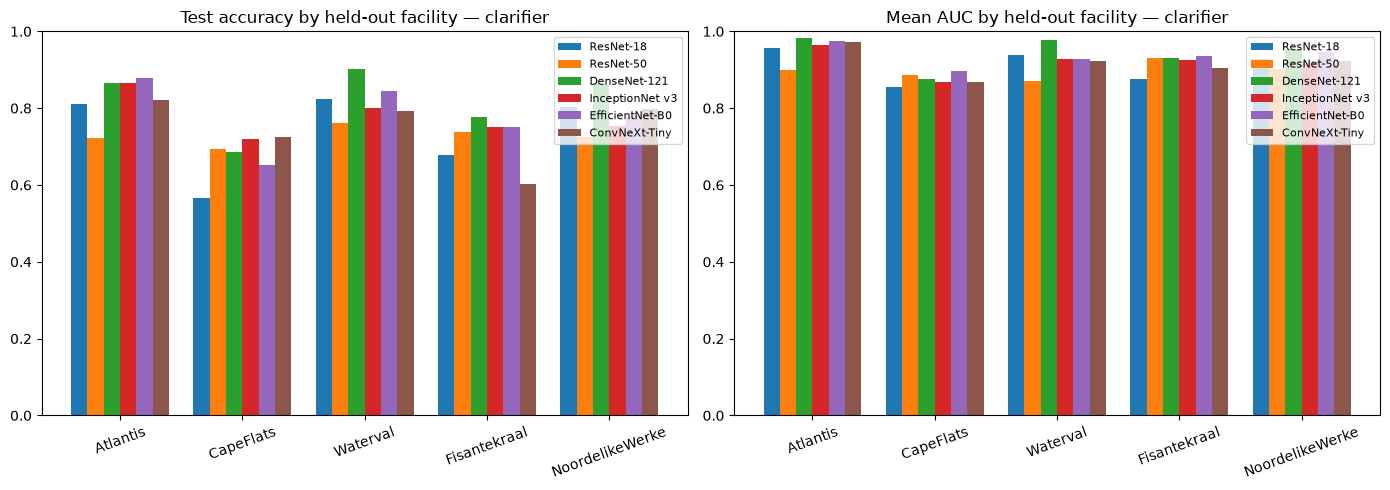

In [4]:
plot_df = comparison.reset_index()
facilities_present = [f for f in ALL_FACILITIES if f in plot_df["facility"].unique()]
models_present = [m for m in MODELS.values() if m in plot_df["model"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(facilities_present))
width = 0.8 / max(len(models_present), 1)

for i, model_name in enumerate(models_present):
    sub = plot_df[plot_df["model"] == model_name].set_index("facility").reindex(facilities_present)
    offset = (i - (len(models_present) - 1) / 2) * width
    axes[0].bar(x + offset, sub["test_accuracy"], width, label=model_name)
    axes[1].bar(x + offset, sub["mean_auc"], width, label=model_name)

for ax, title in zip(axes, ["Test accuracy", "Mean AUC"]):
    ax.set_xticks(x)
    ax.set_xticklabels(facilities_present, rotation=20)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title} by held-out facility — {COMPONENT}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Per-facility, per-model detail

For each held-out facility and each trained architecture: training curves (loss and accuracy,
train/val, plus test if the training notebook passed `test_loader=...` into `train_model()`),
confusion matrix, and ROC/AUC curves. These are the exact PNGs `wwtw_utils.py` saved during
training, not recomputed here, so what you see is exactly what that training run produced.

### Atlantis (held out)

**ResNet-18** — test accuracy 0.811, mean AUC 0.957

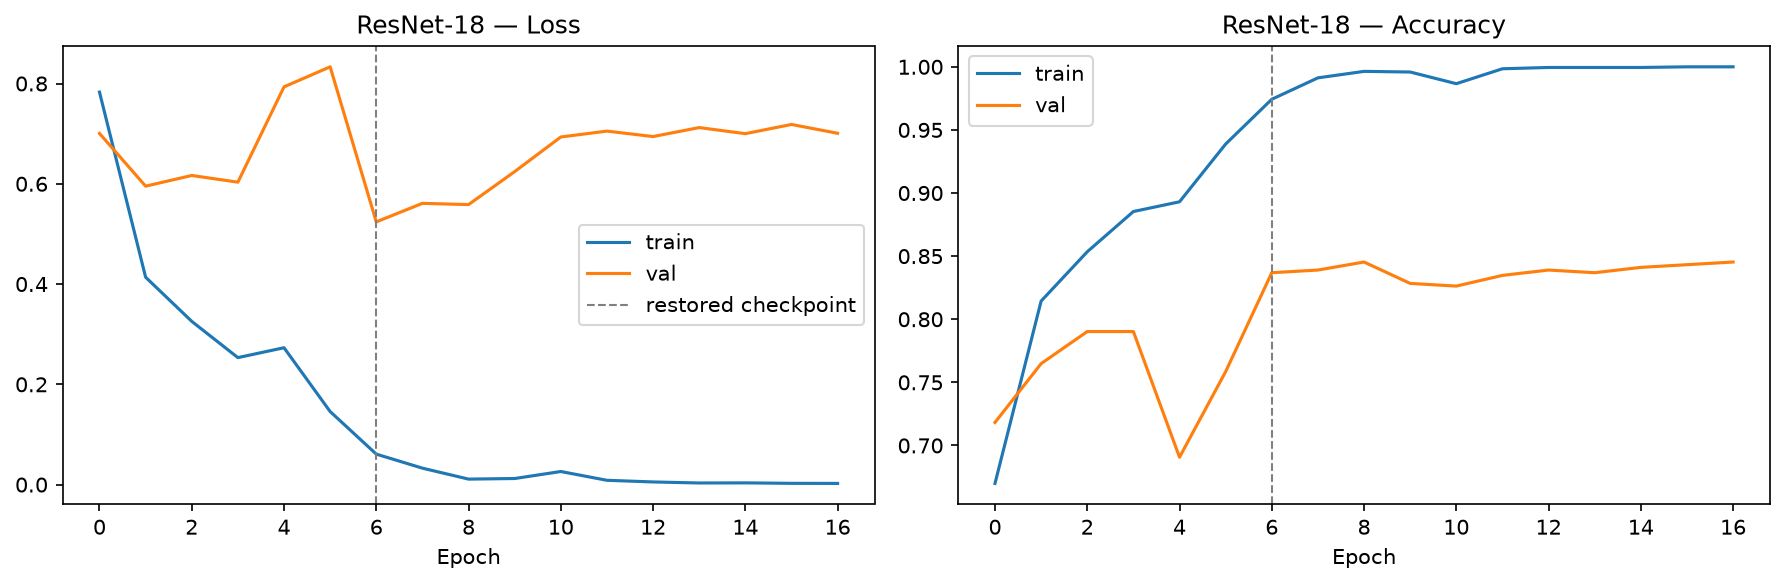

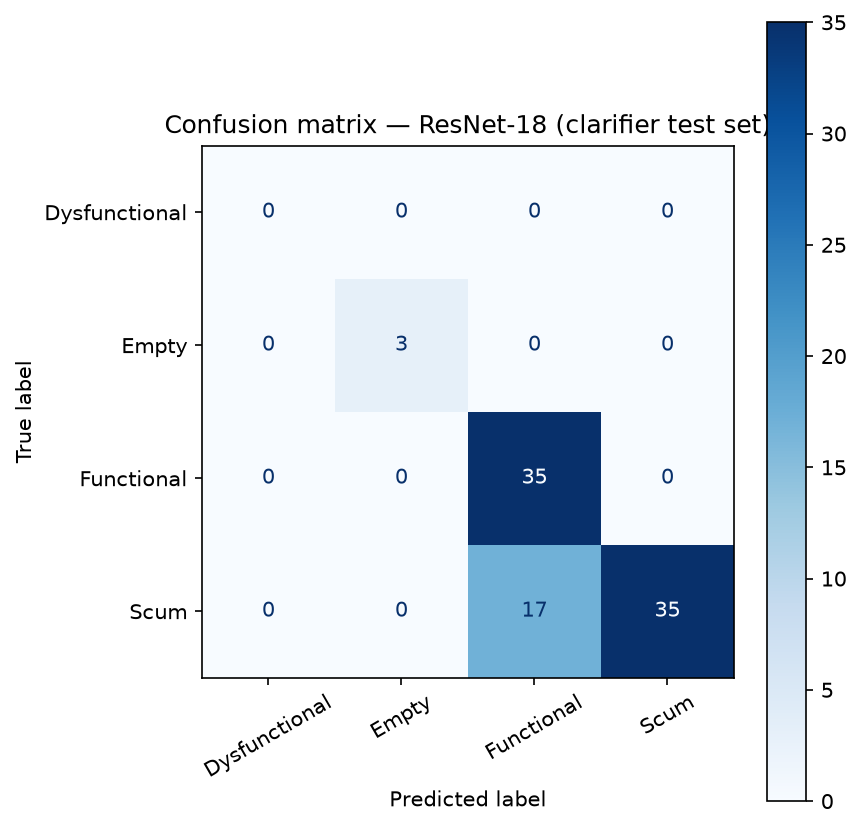

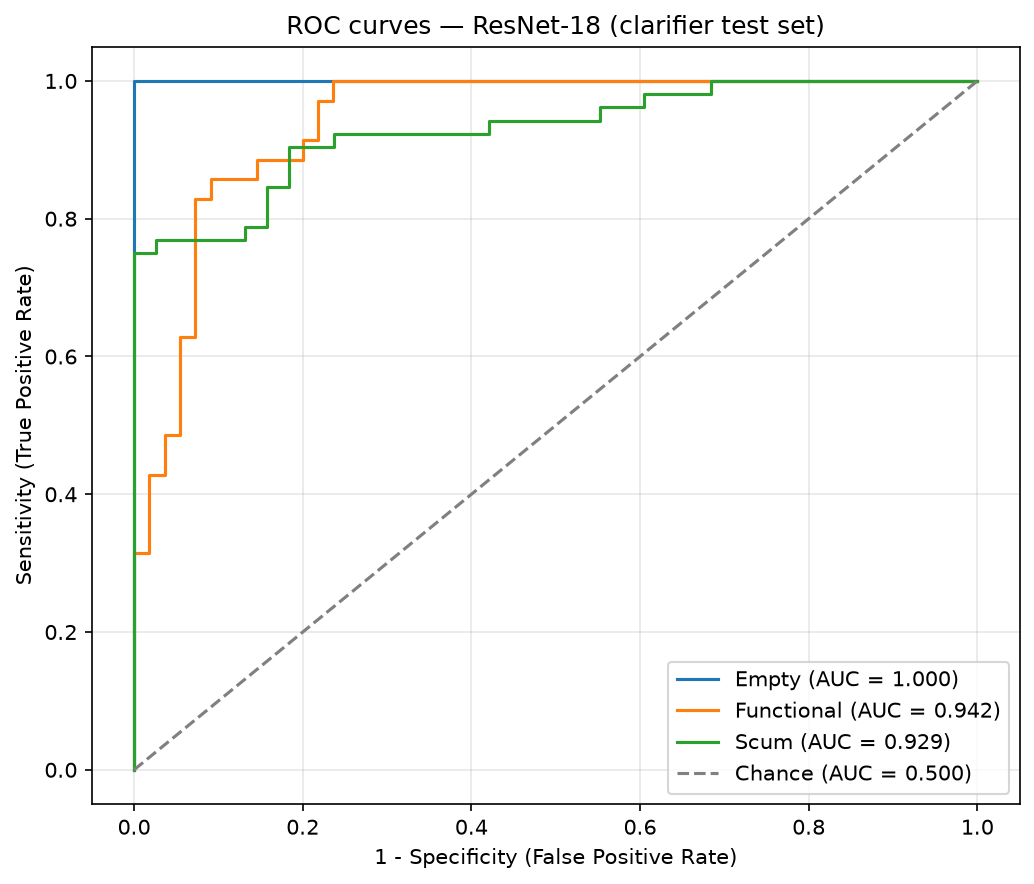

**ResNet-50** — test accuracy 0.722, mean AUC 0.900

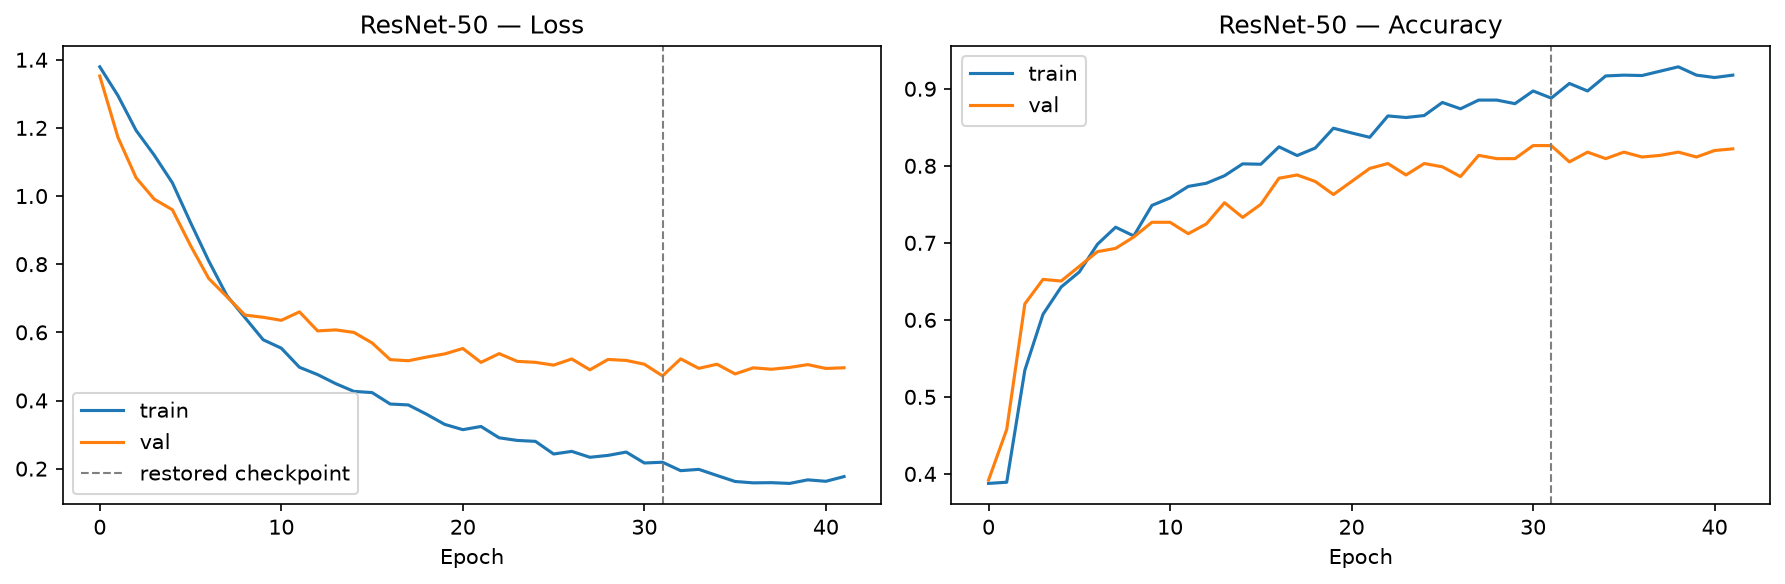

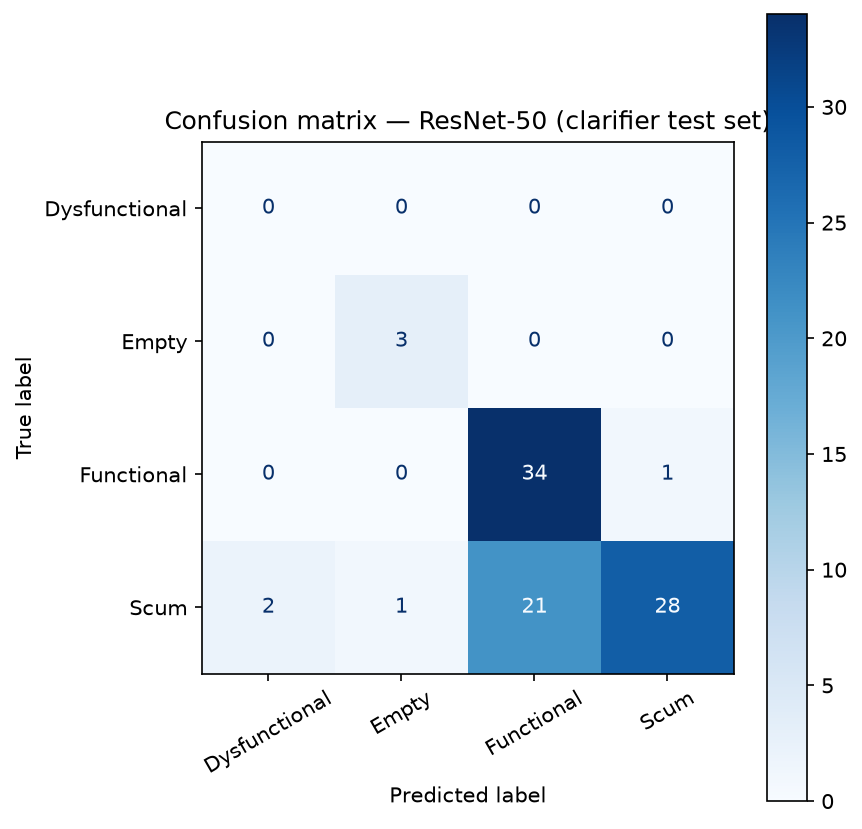

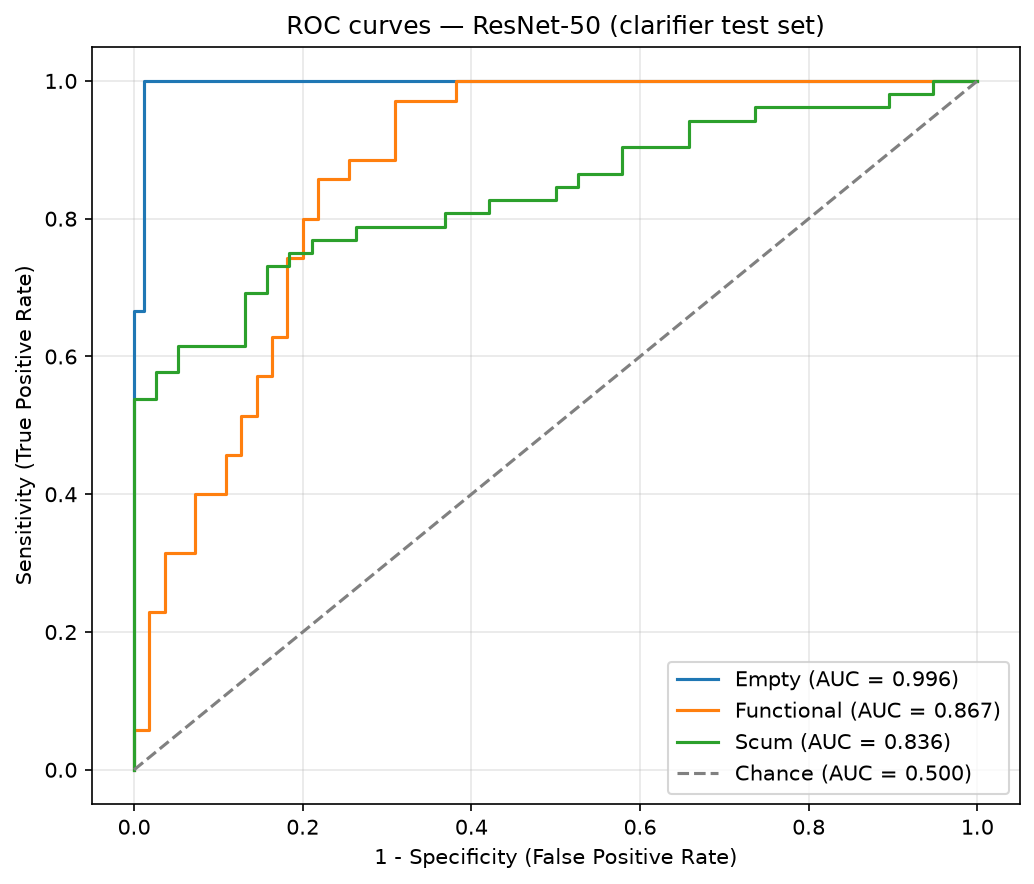

**DenseNet-121** — test accuracy 0.867, mean AUC 0.983

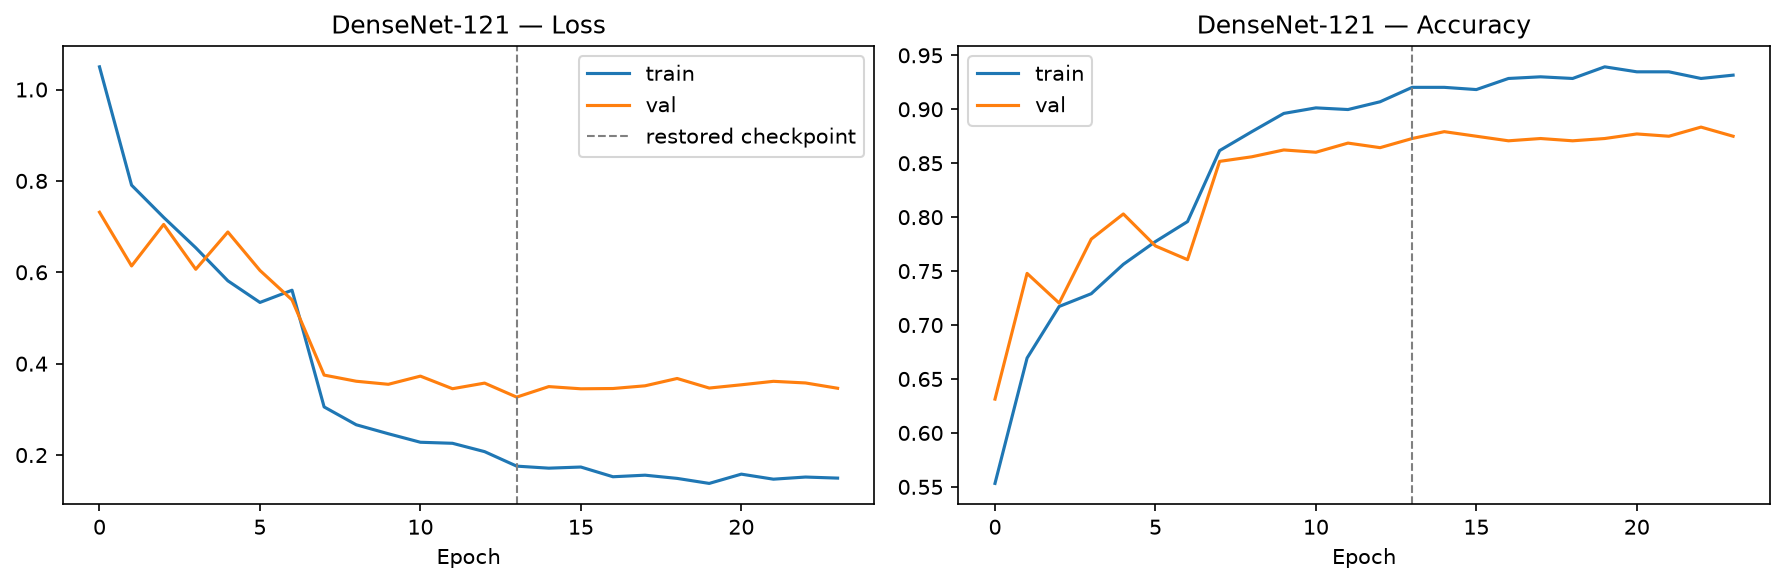

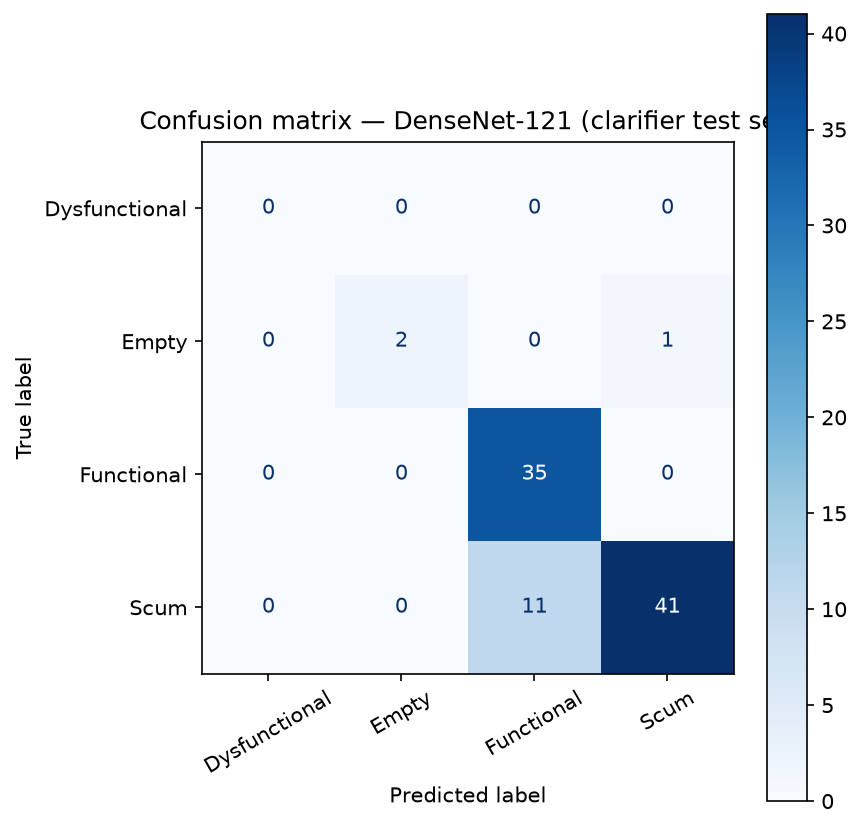

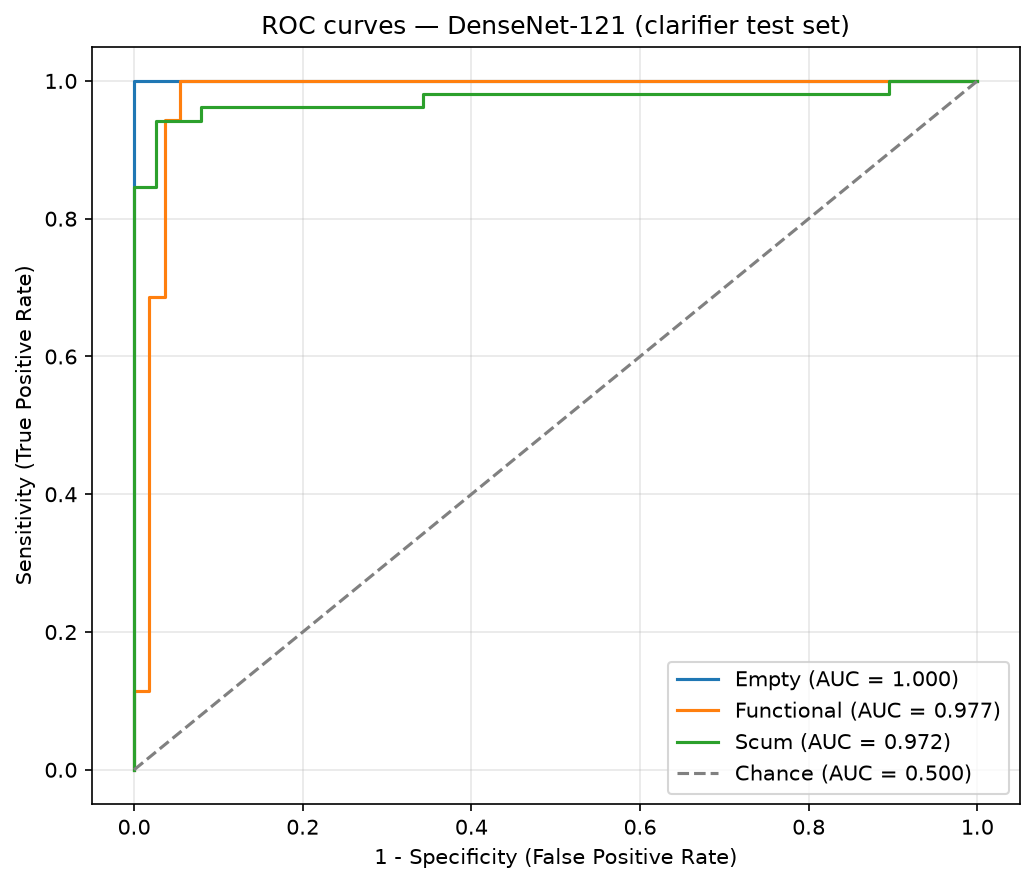

**InceptionNet v3** — test accuracy 0.867, mean AUC 0.963

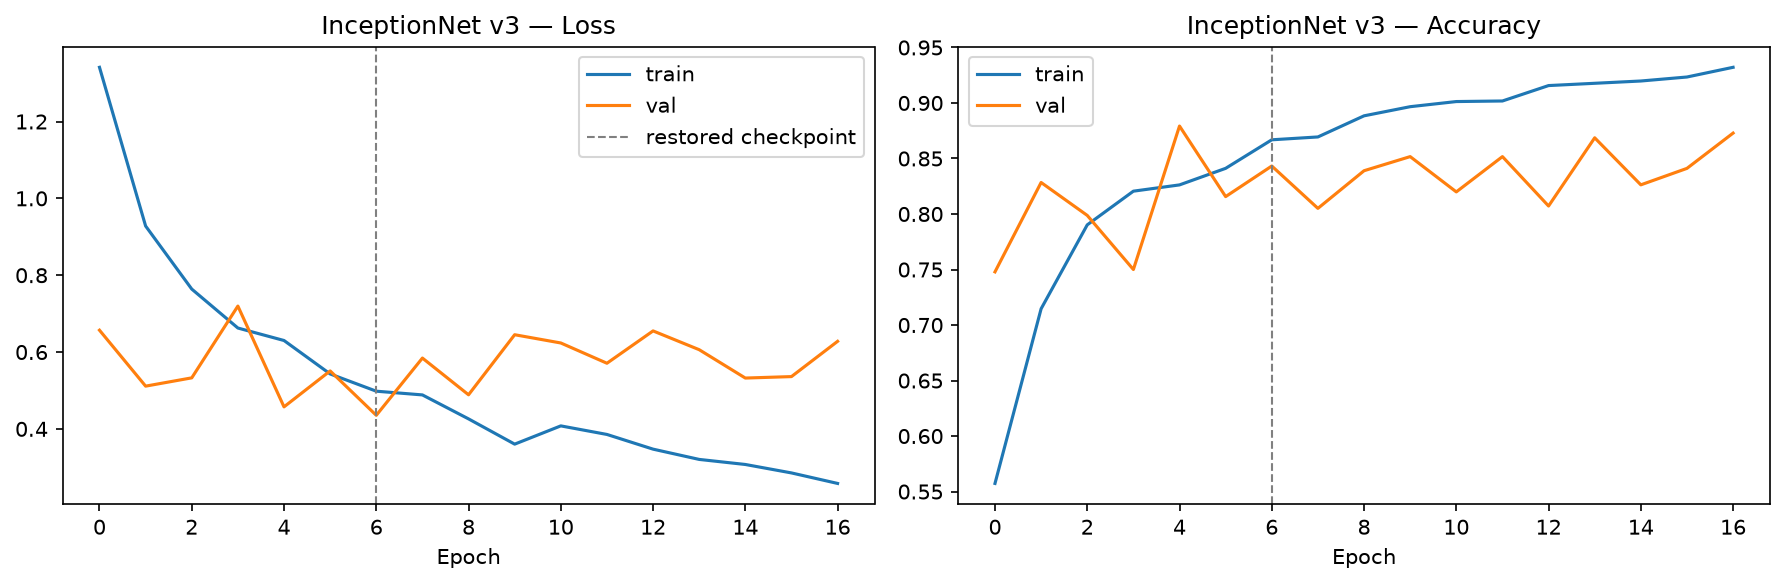

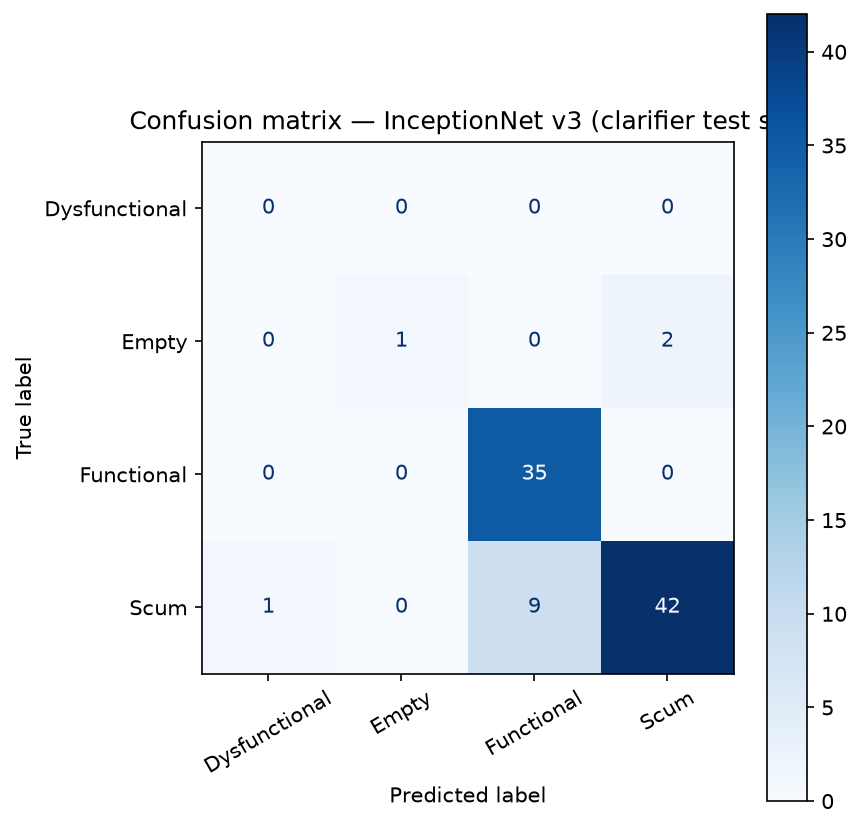

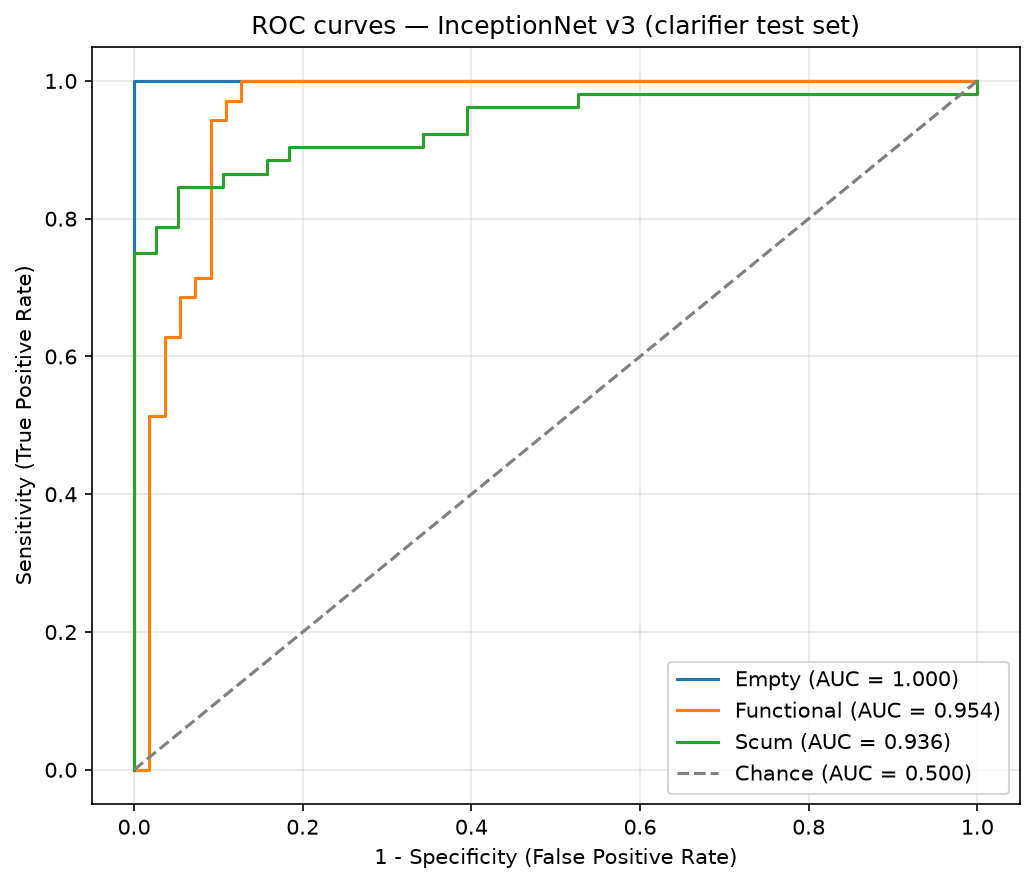

**EfficientNet-B0** — test accuracy 0.878, mean AUC 0.974

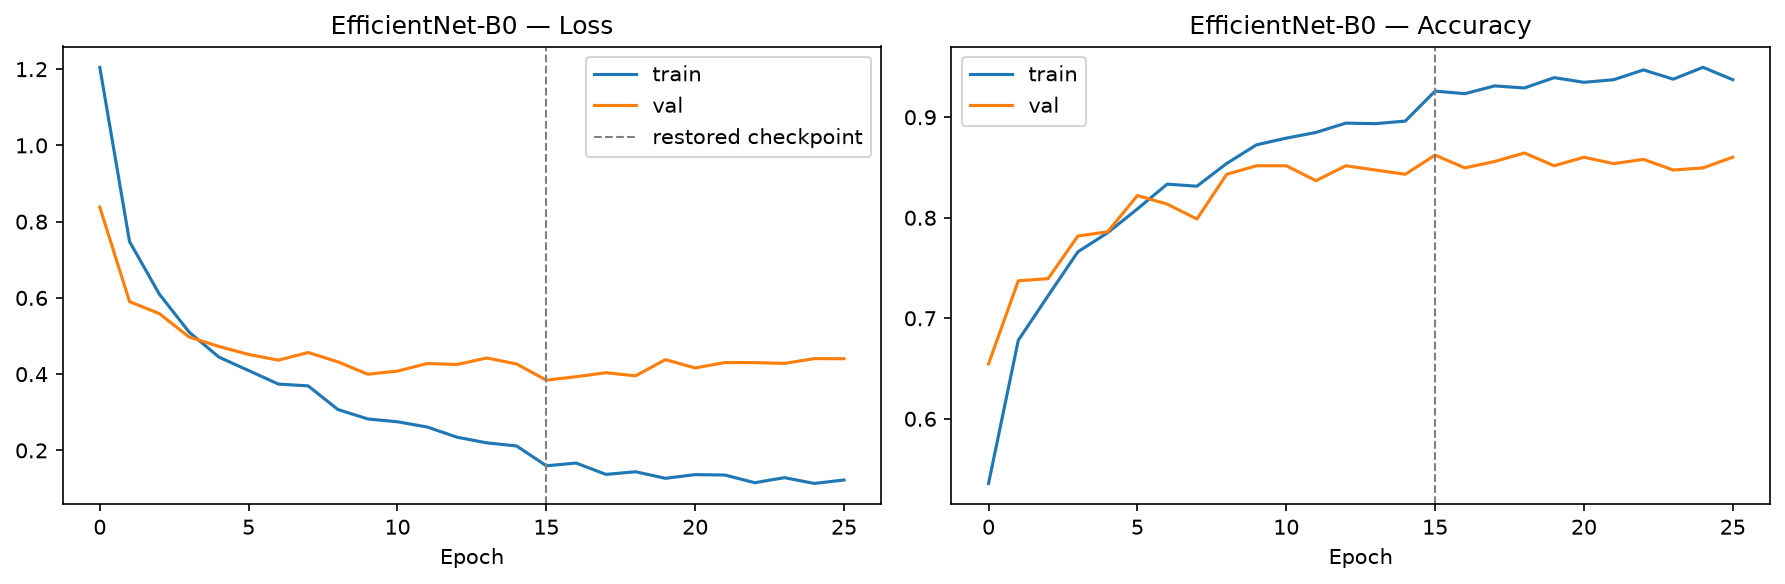

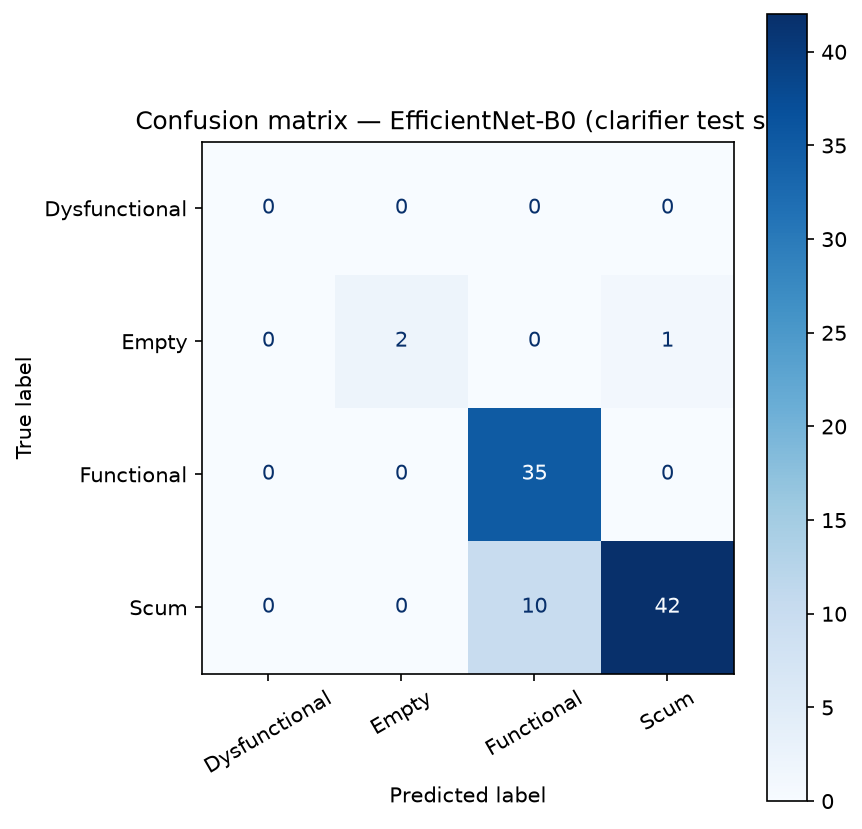

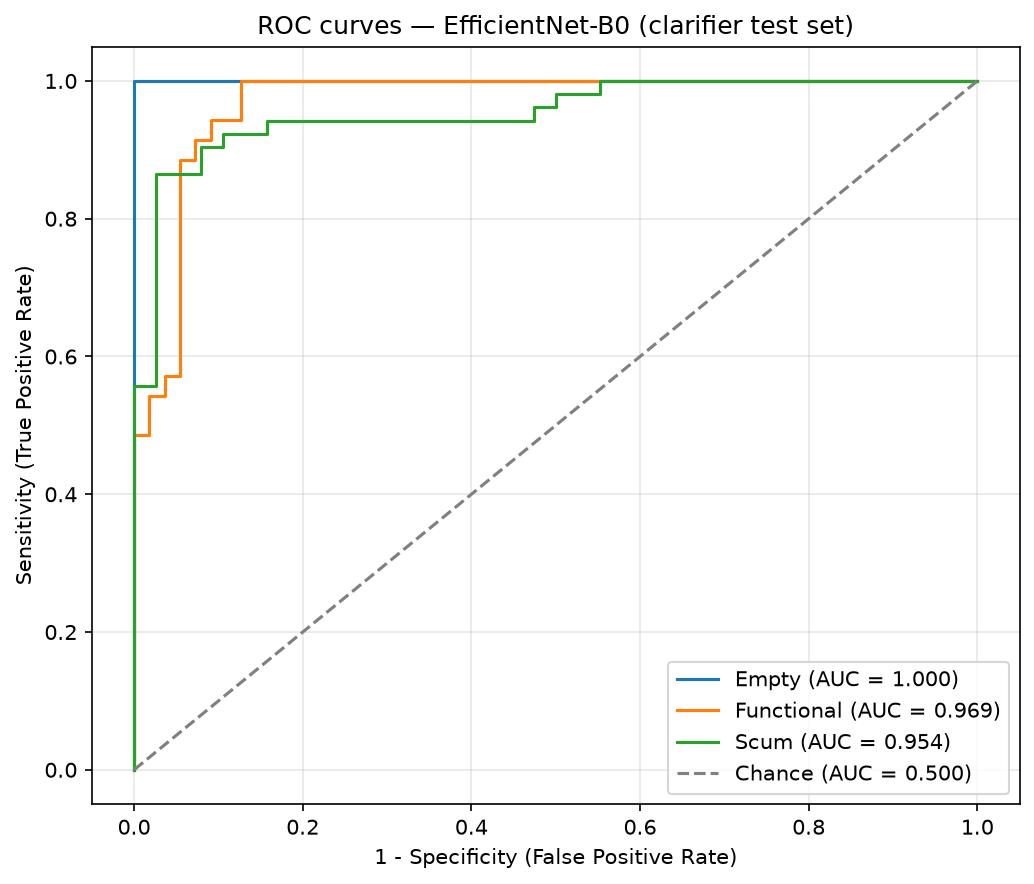

**ConvNeXt-Tiny** — test accuracy 0.822, mean AUC 0.972

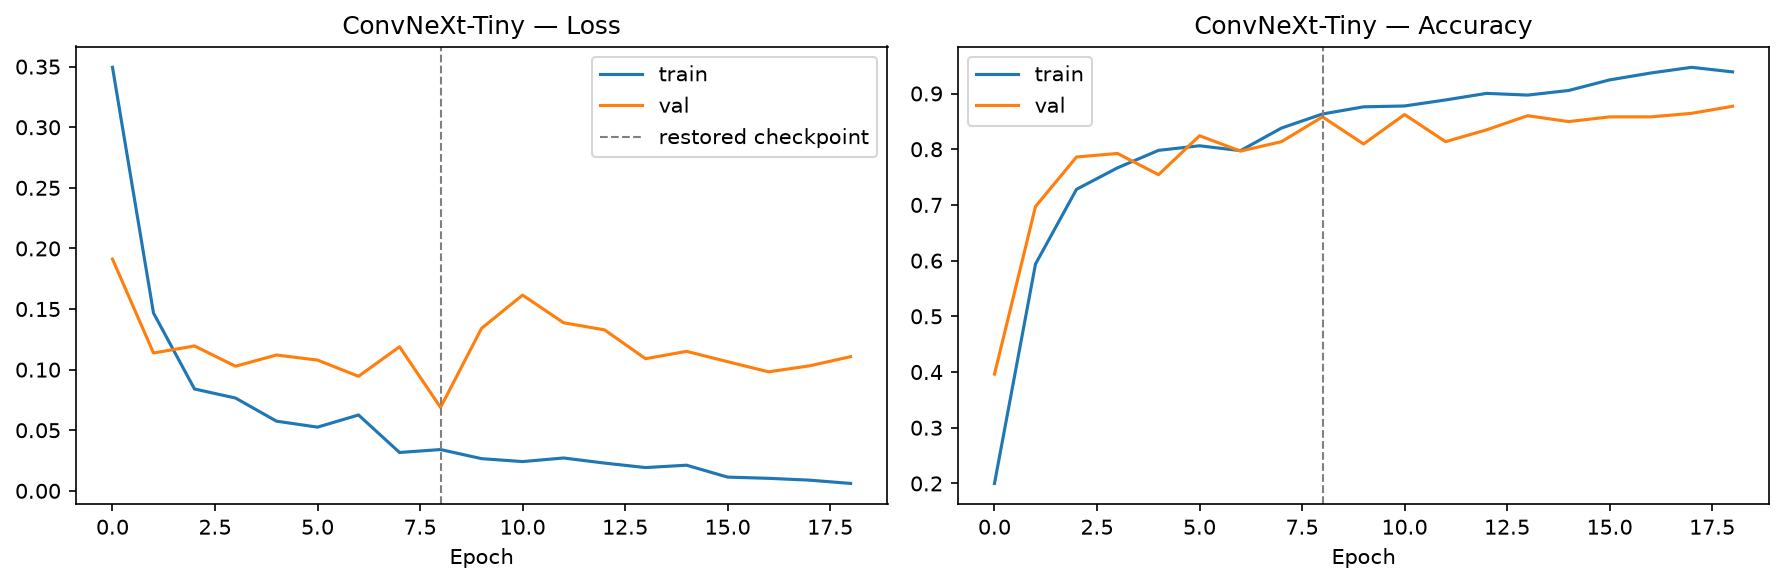

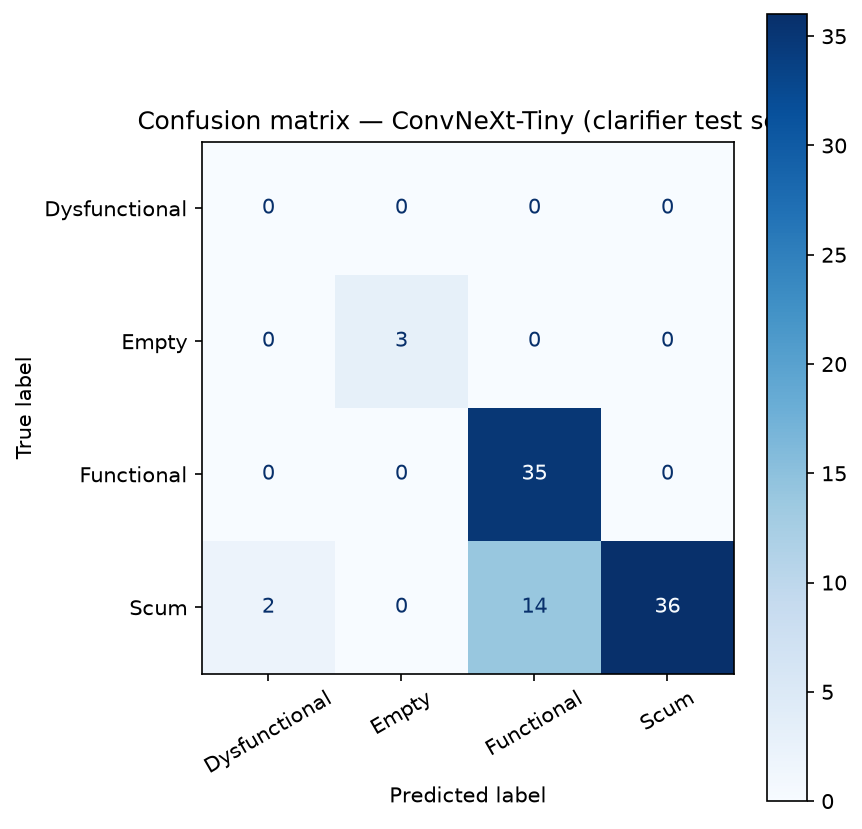

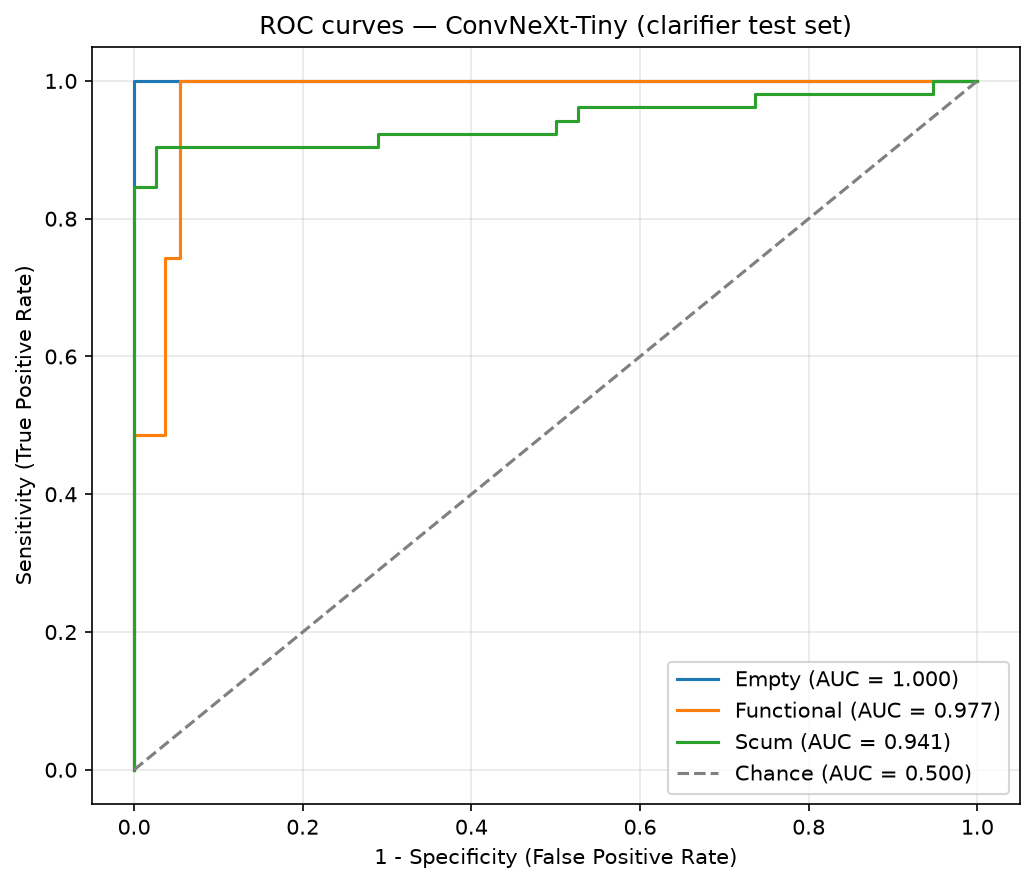

### CapeFlats (held out)

**ResNet-18** — test accuracy 0.566, mean AUC 0.856

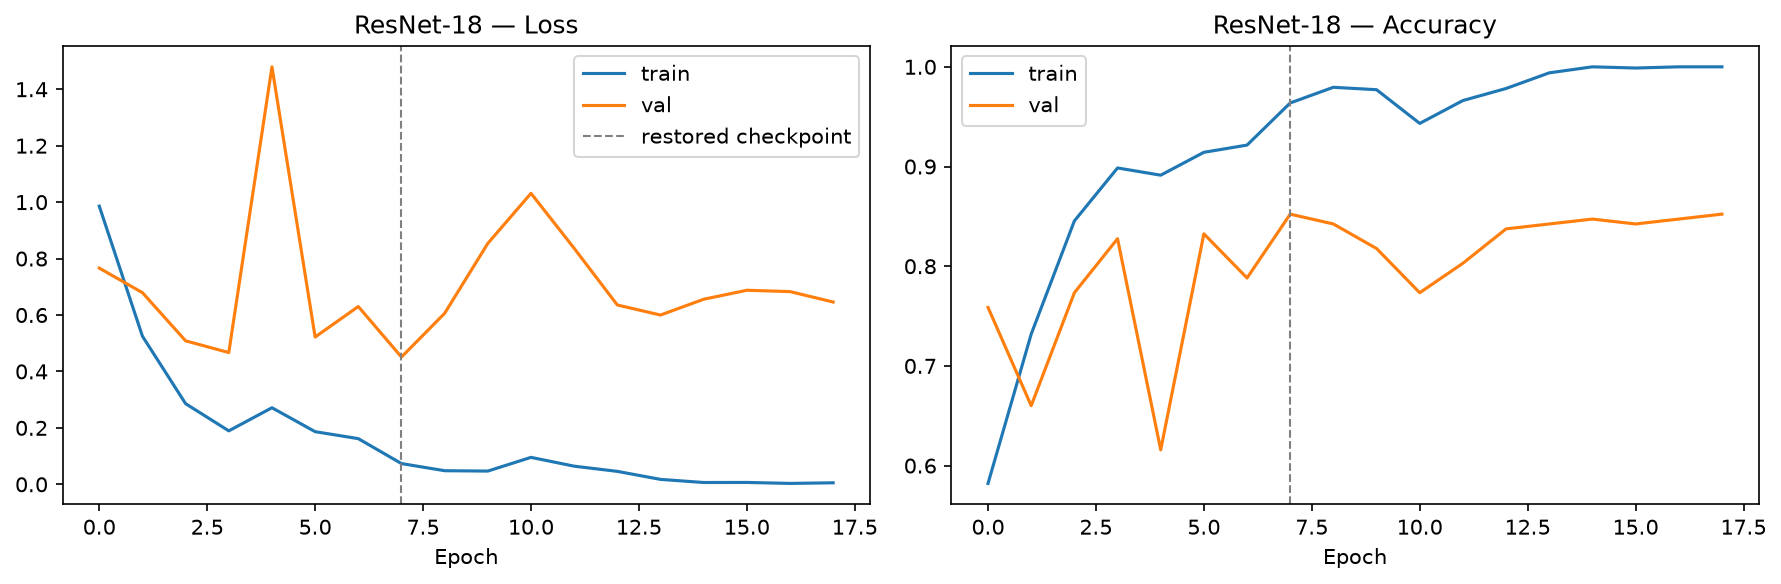

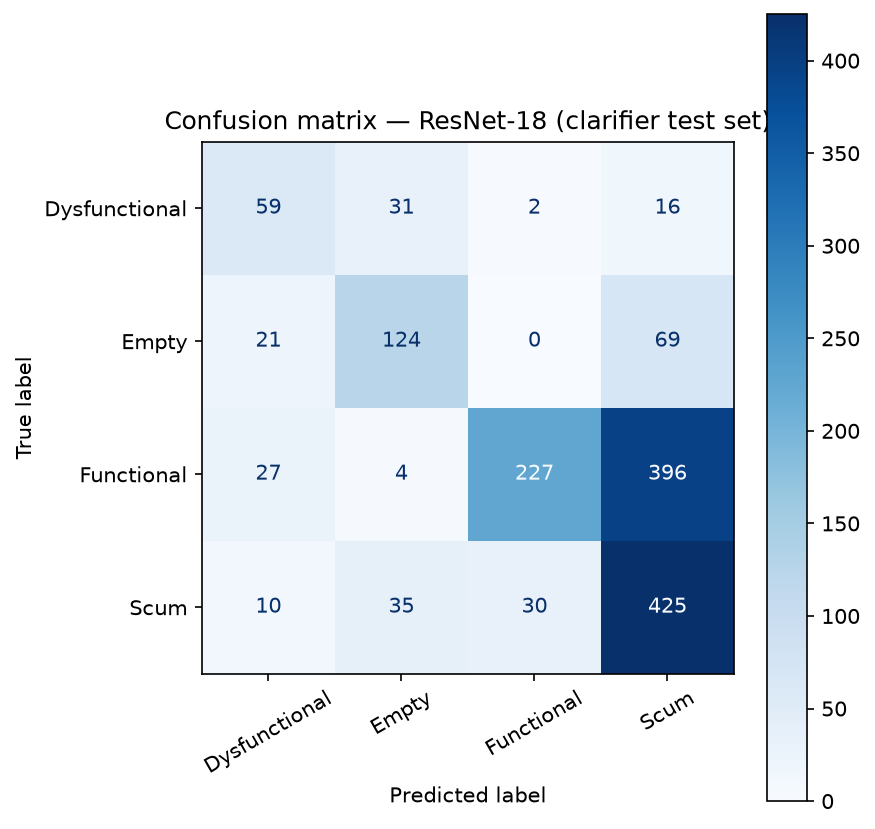

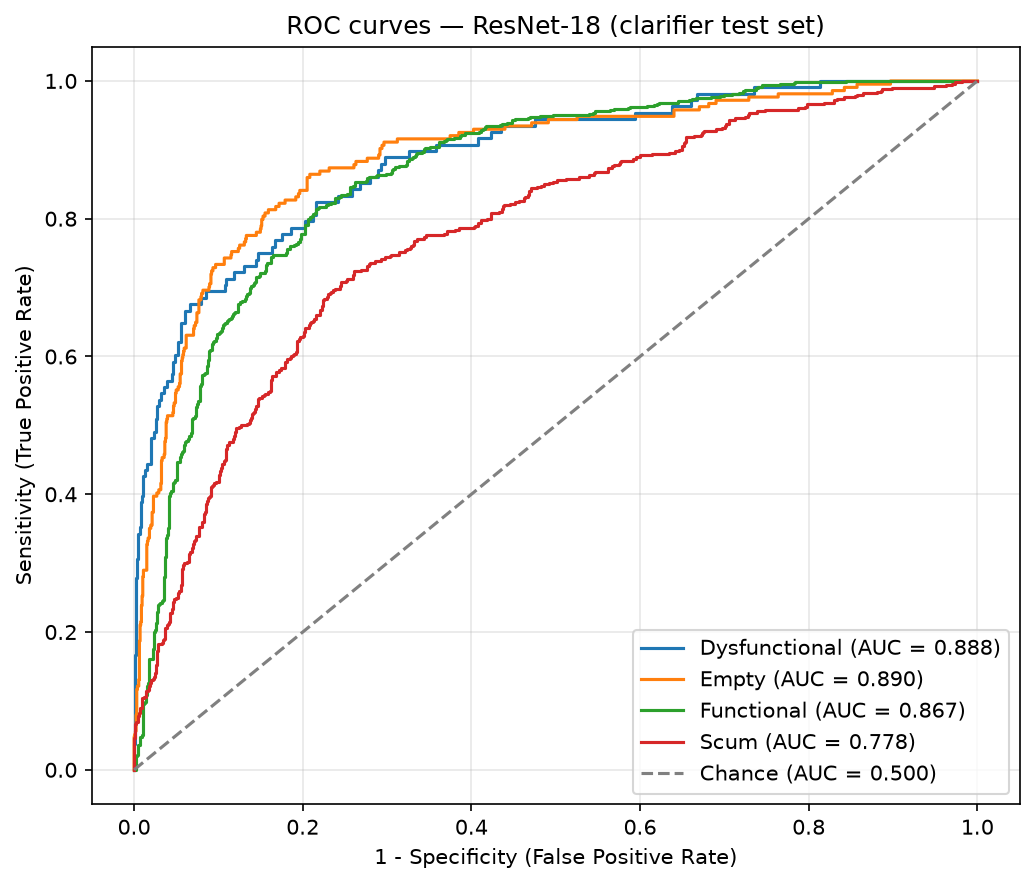

**ResNet-50** — test accuracy 0.694, mean AUC 0.885

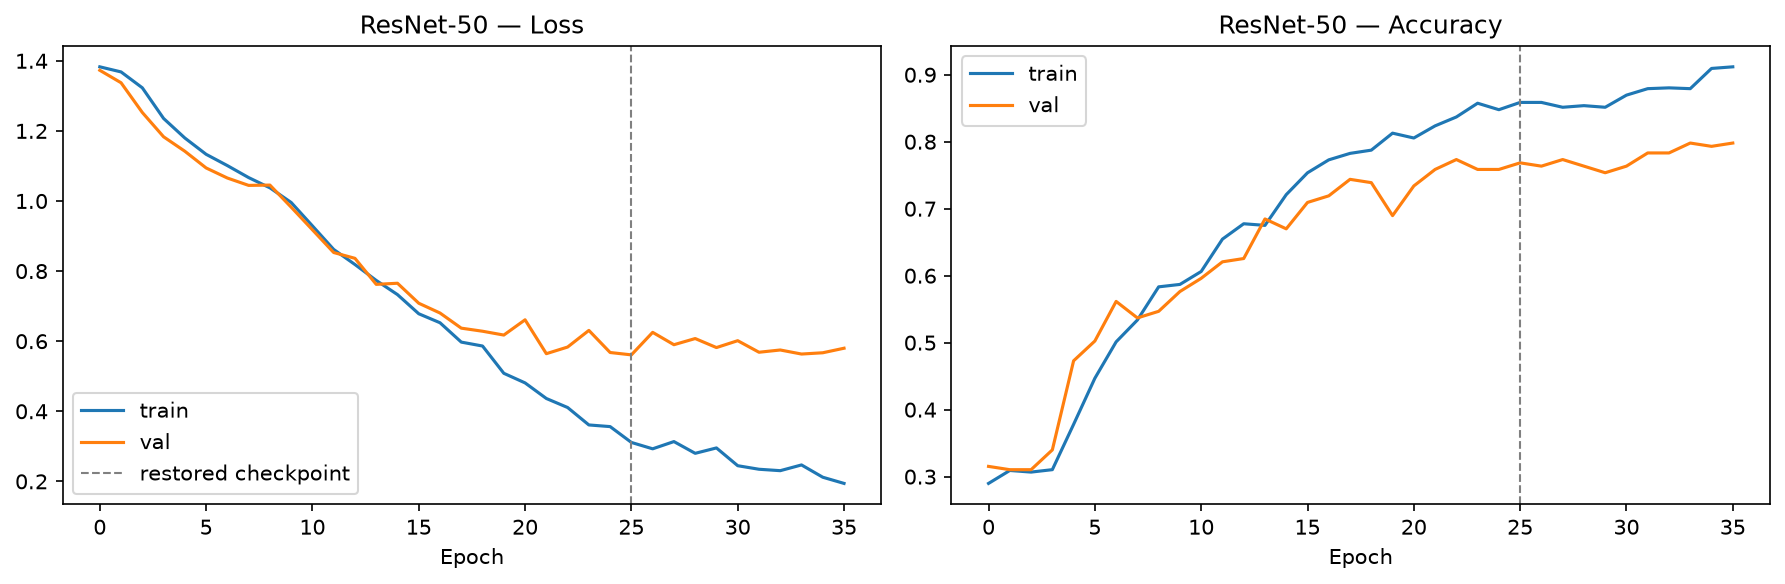

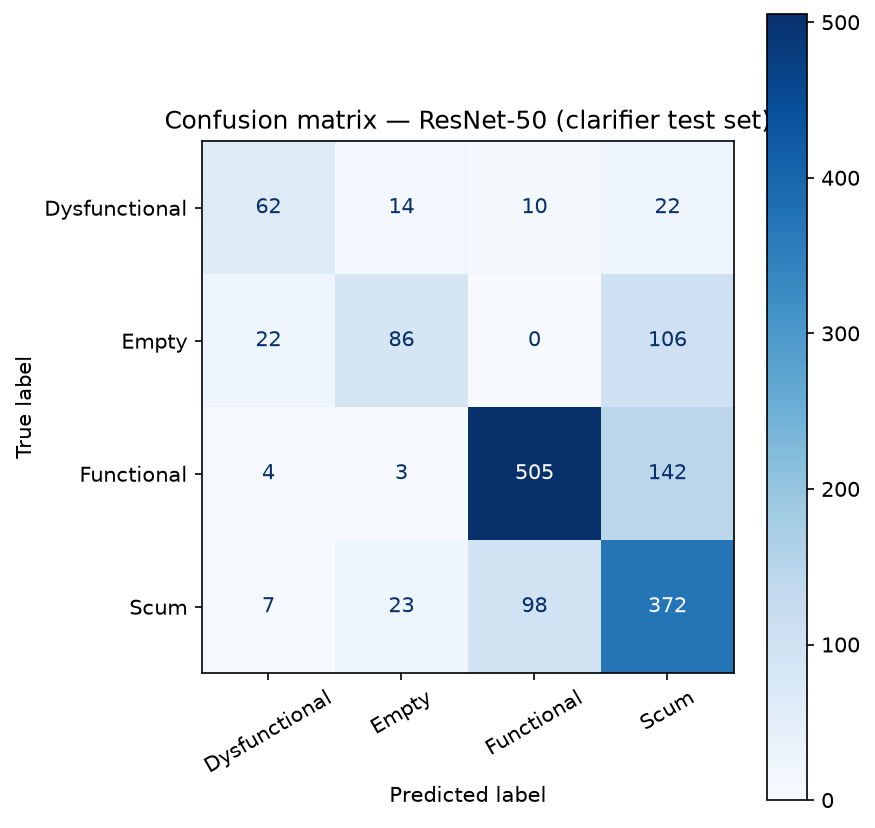

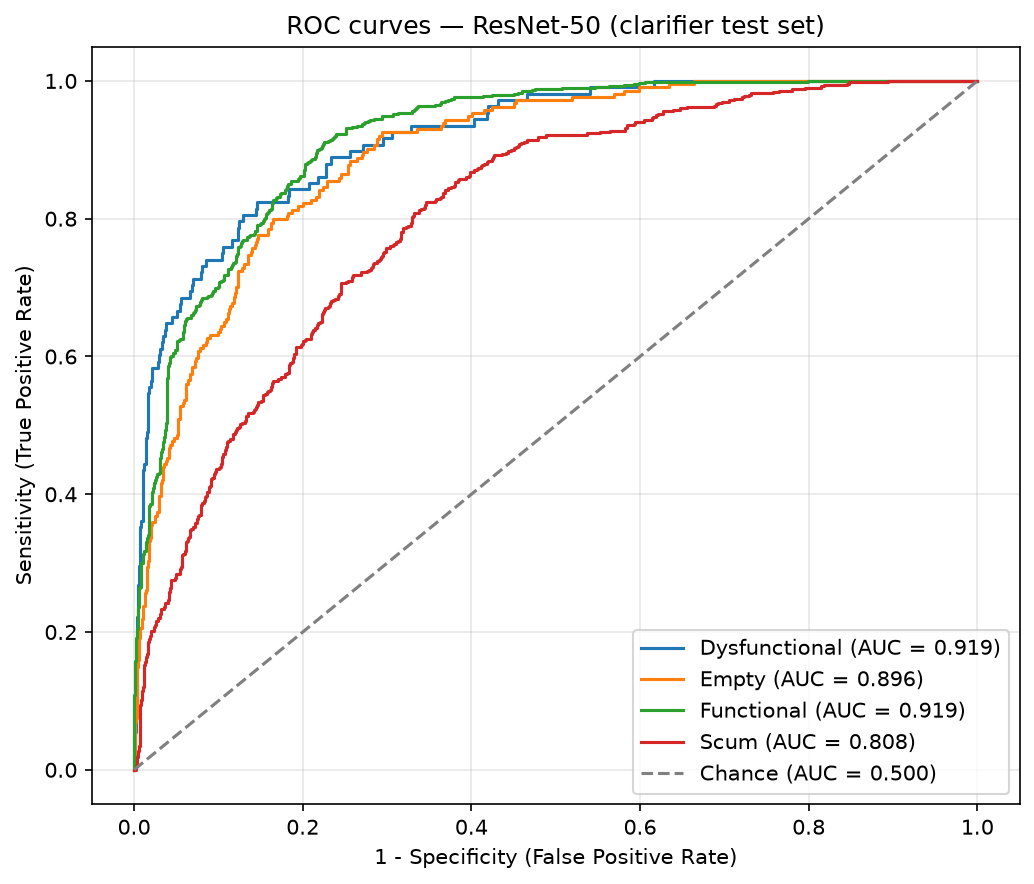

**DenseNet-121** — test accuracy 0.687, mean AUC 0.876

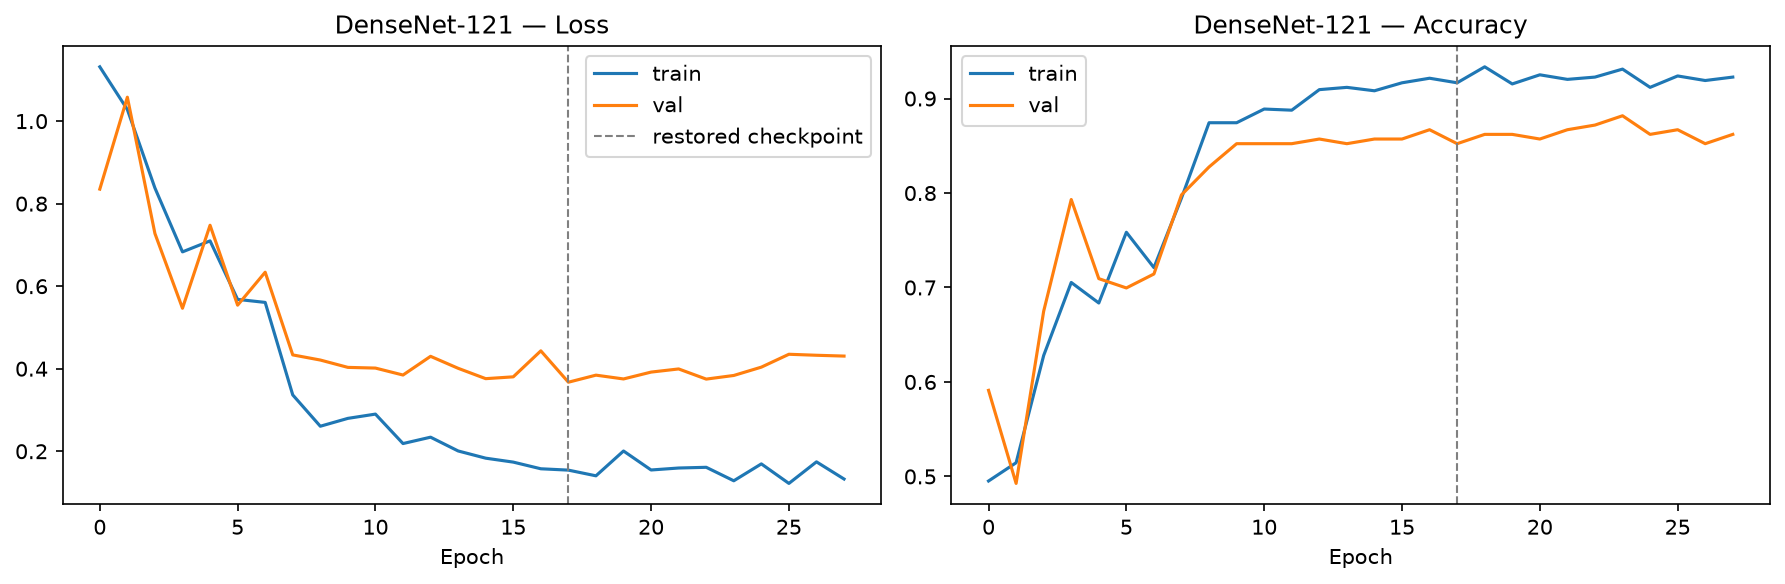

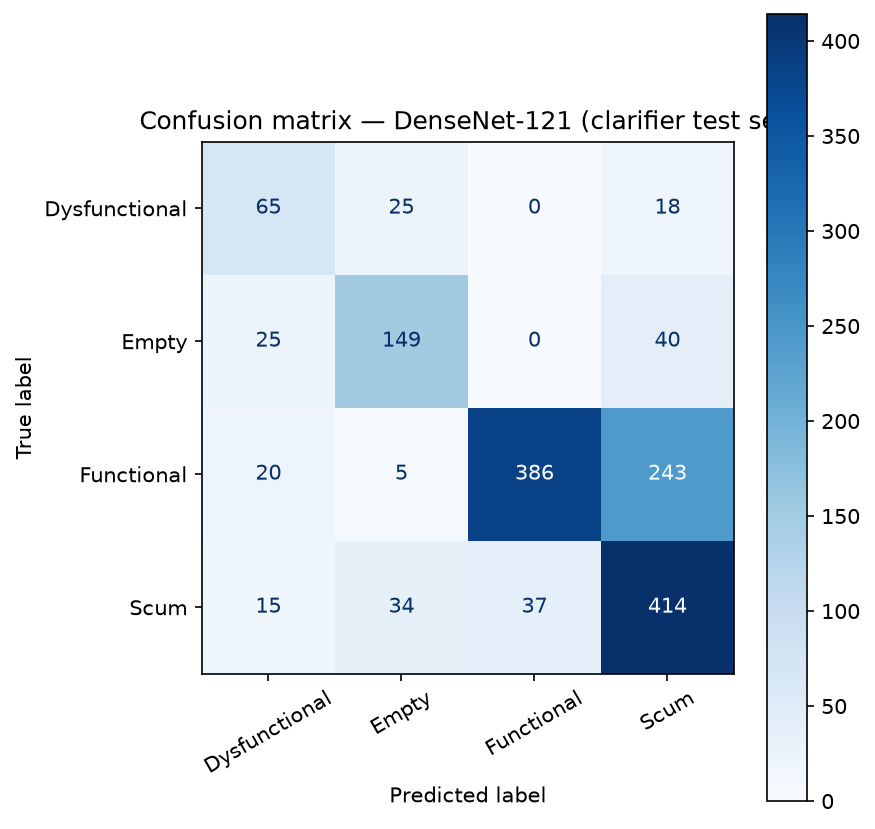

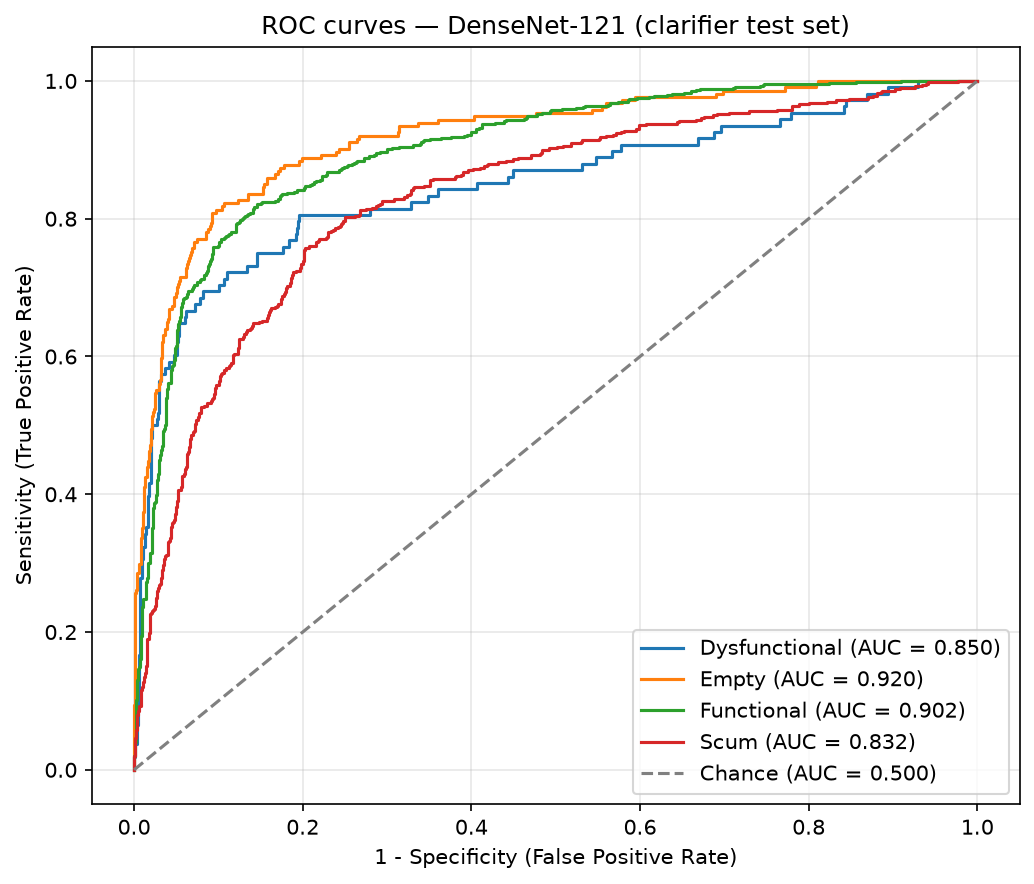

**InceptionNet v3** — test accuracy 0.720, mean AUC 0.869

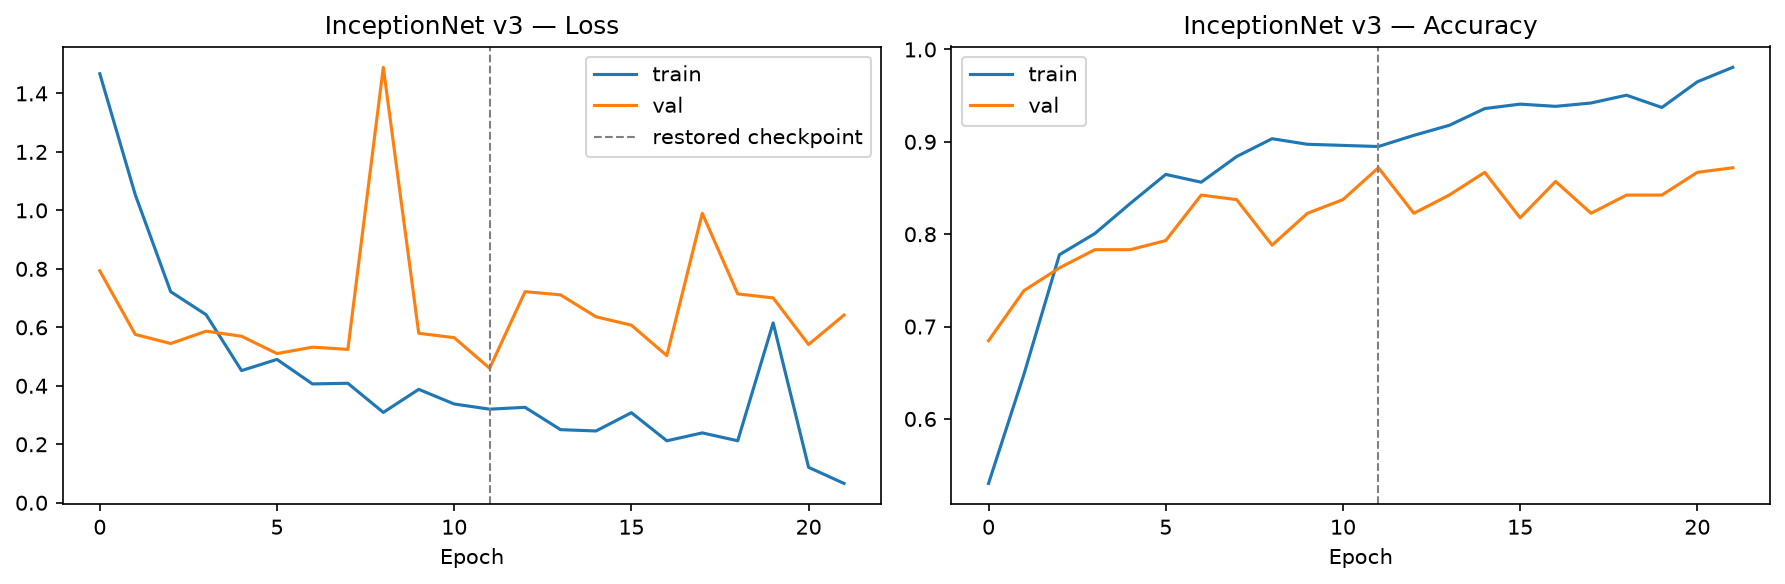

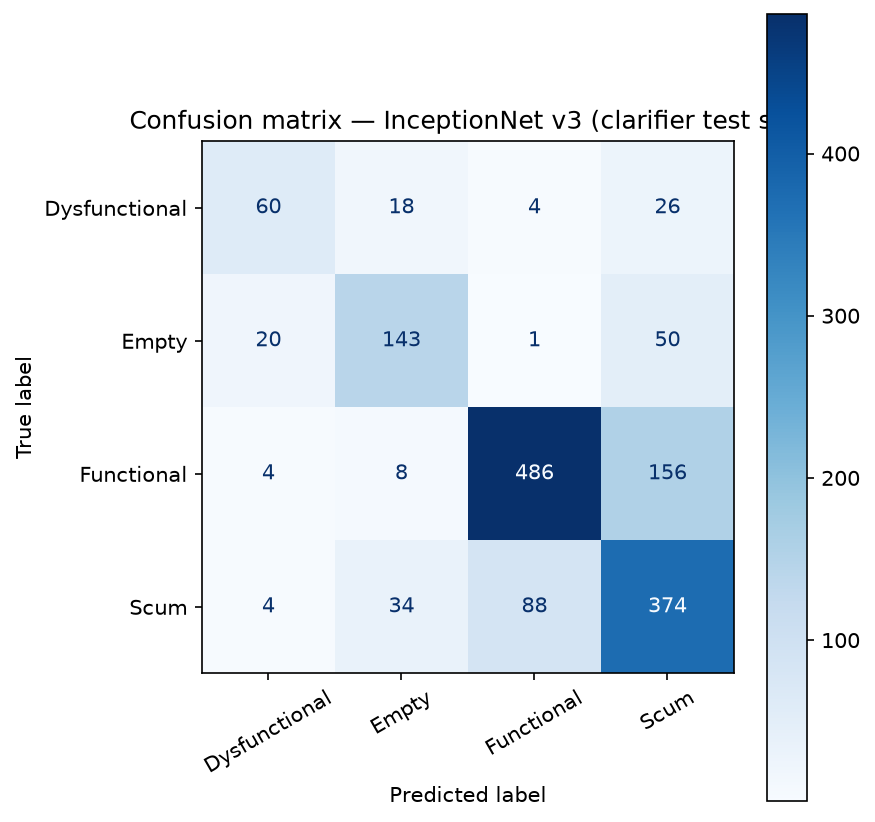

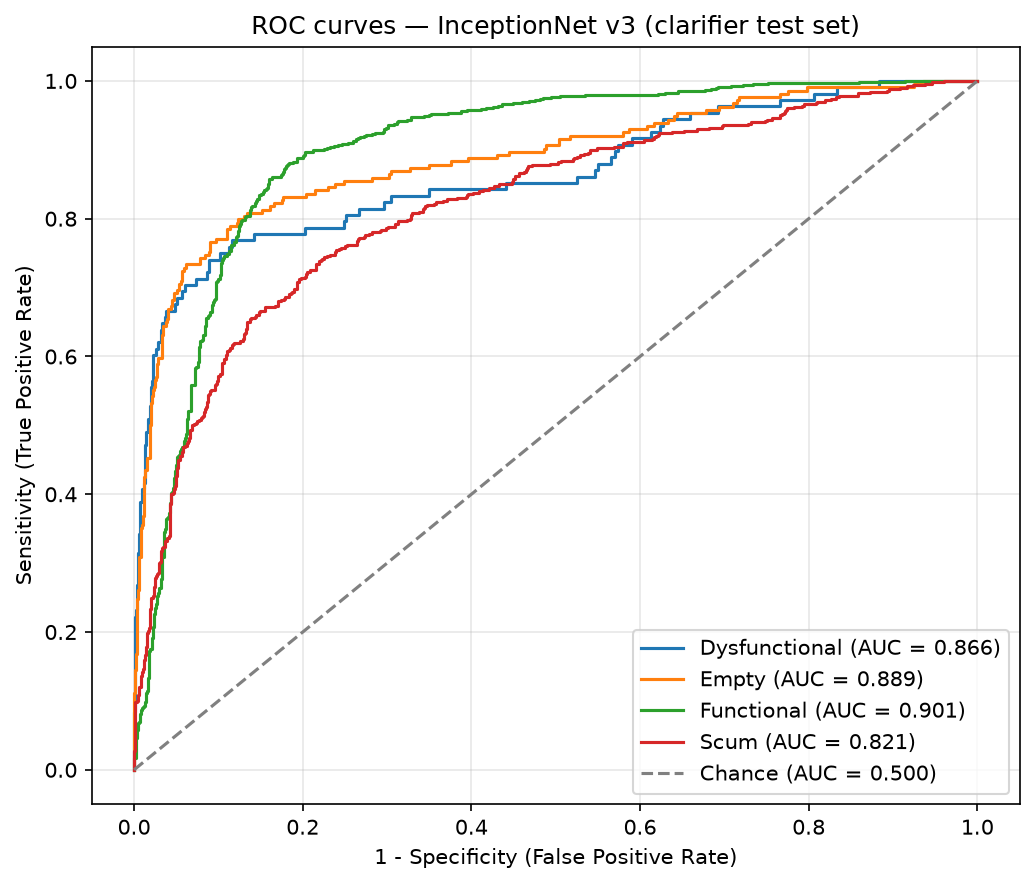

**EfficientNet-B0** — test accuracy 0.652, mean AUC 0.897

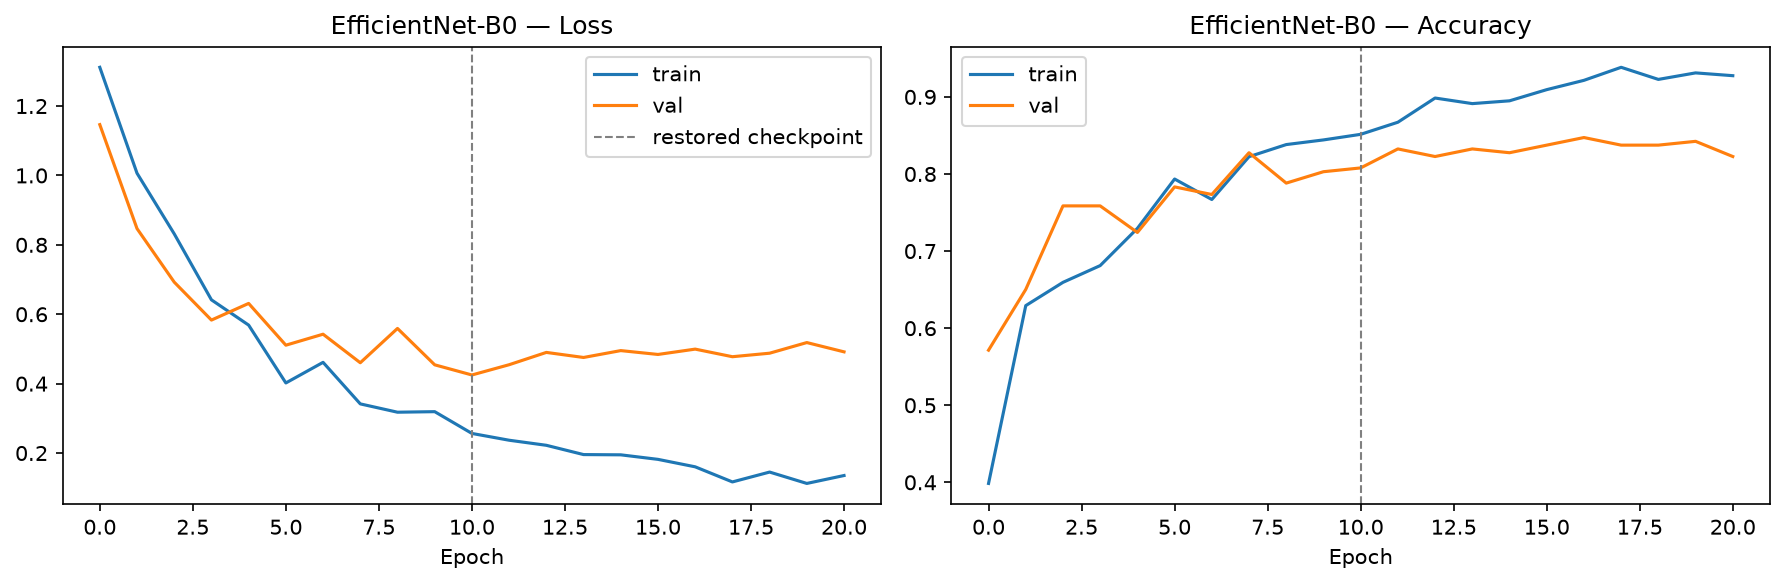

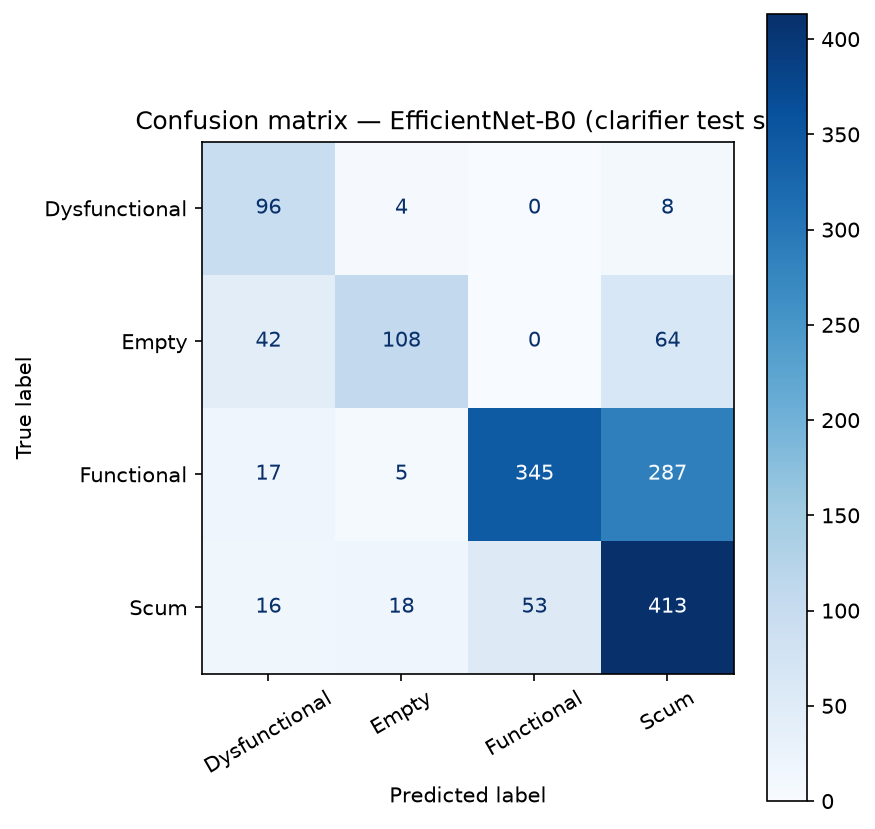

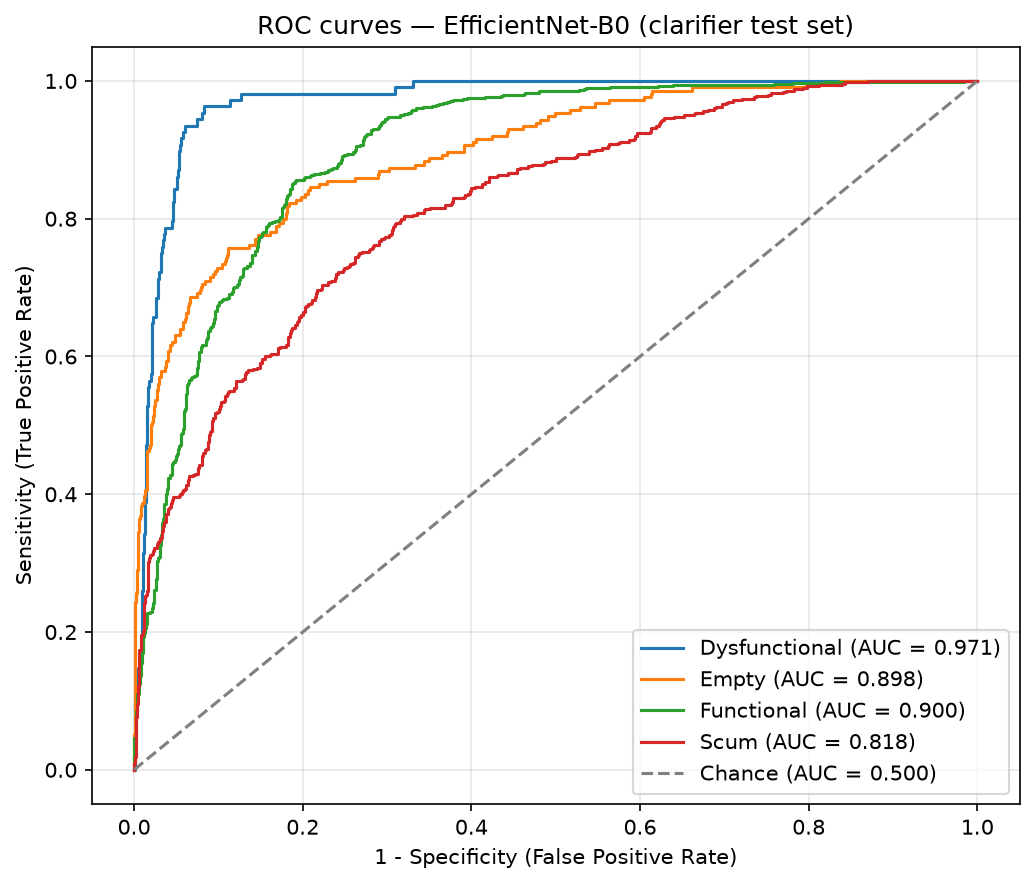

**ConvNeXt-Tiny** — test accuracy 0.724, mean AUC 0.868

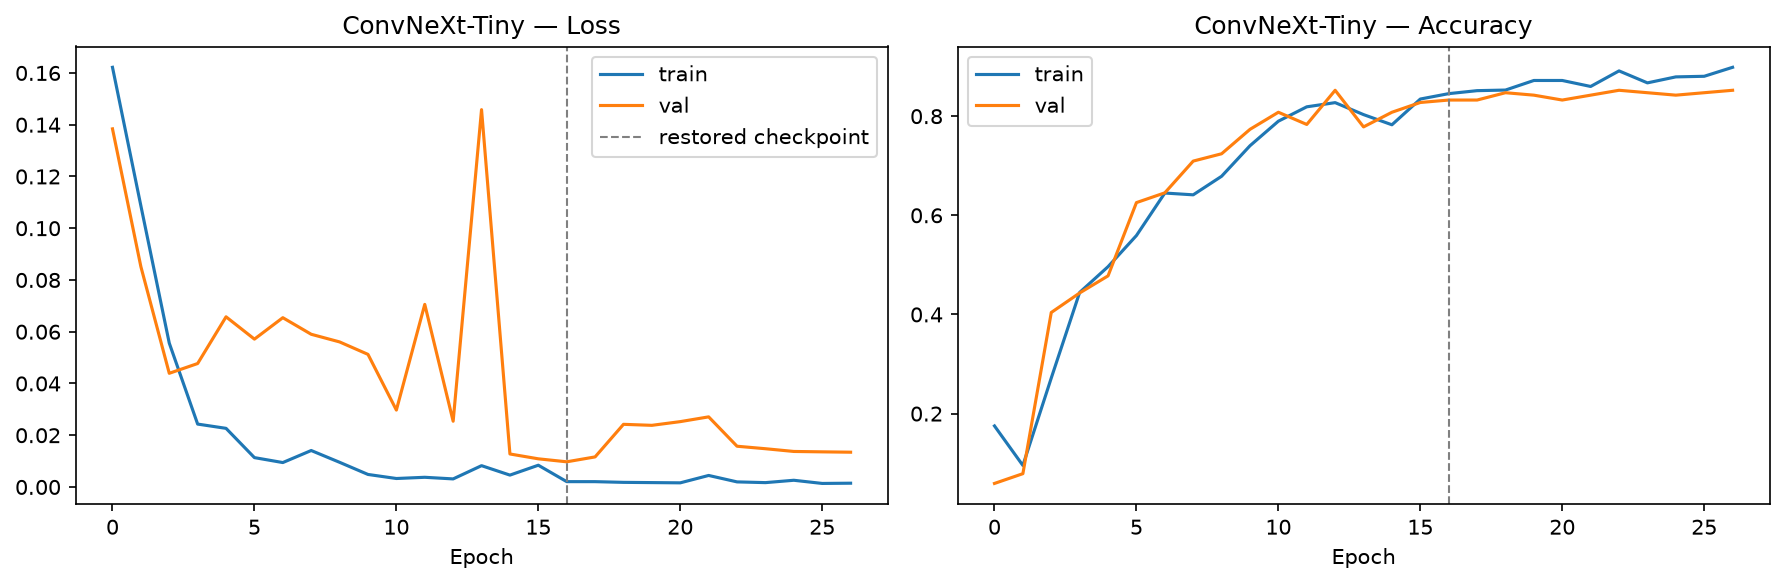

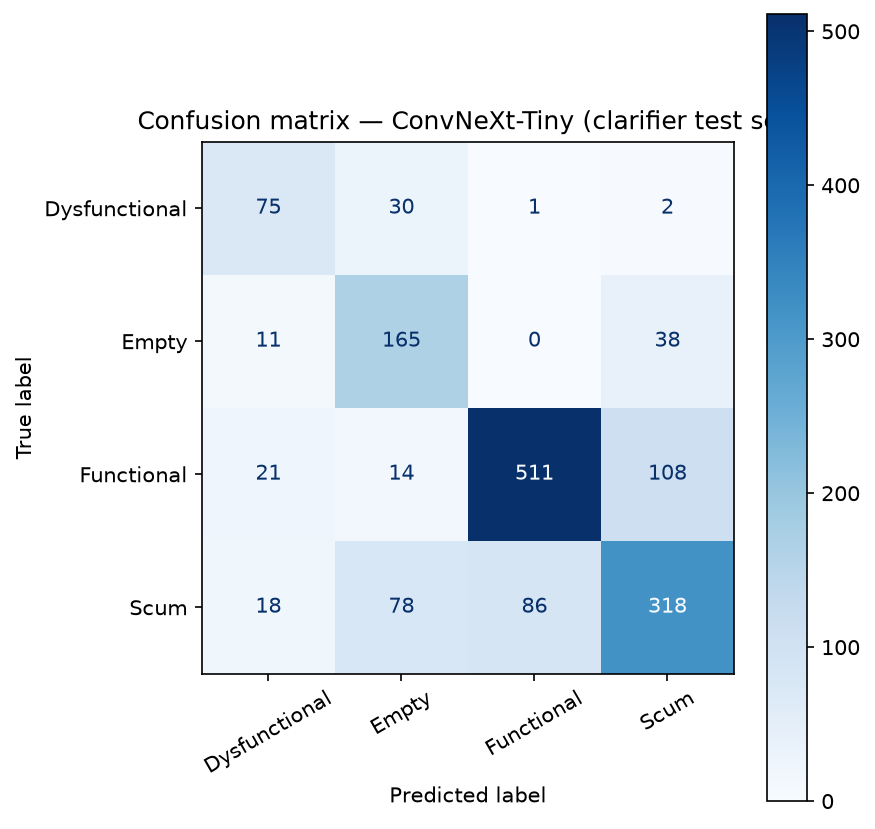

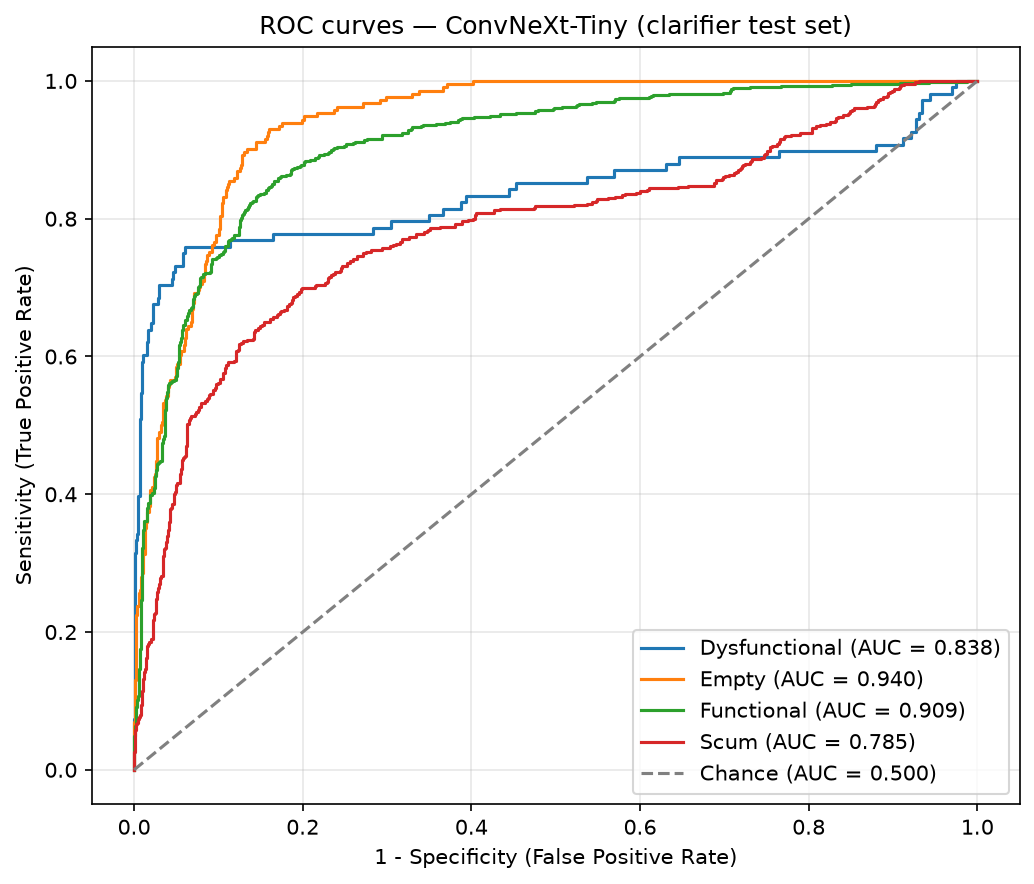

### Waterval (held out)

**ResNet-18** — test accuracy 0.824, mean AUC 0.939

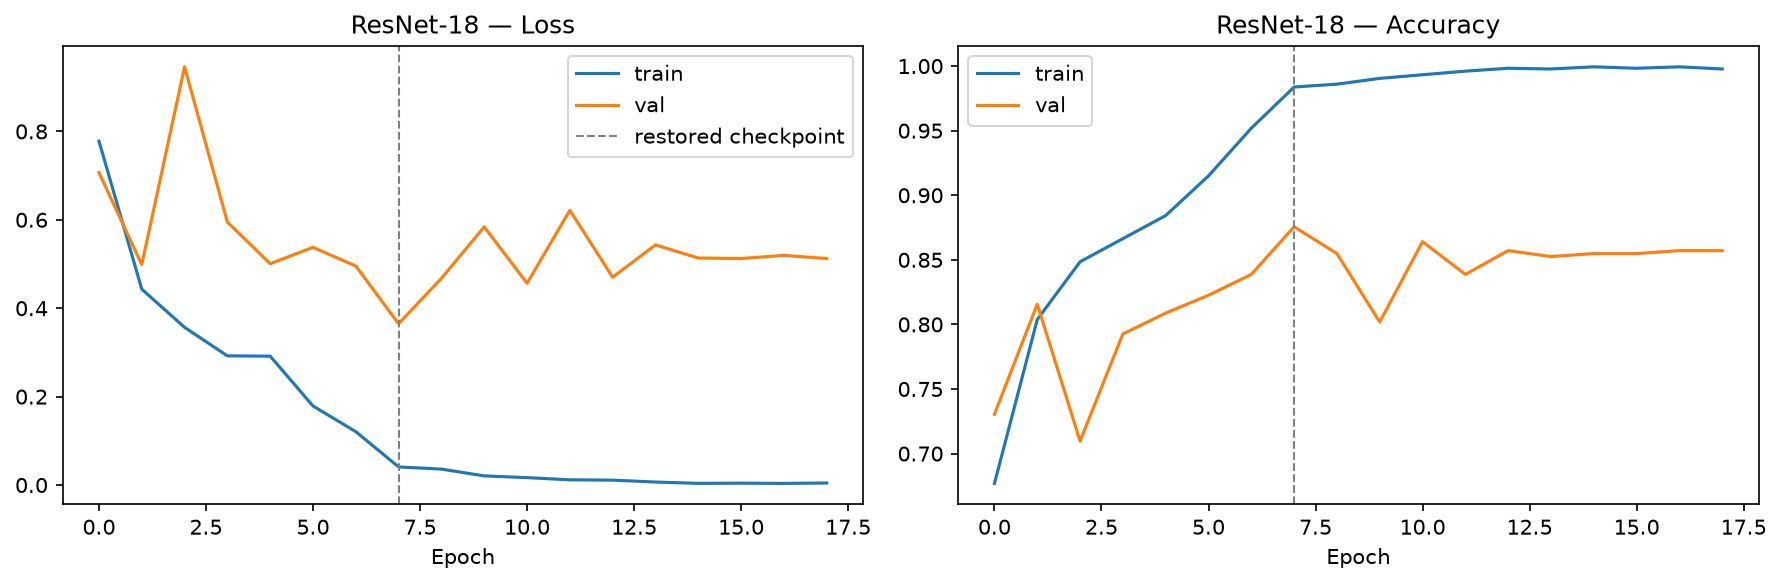

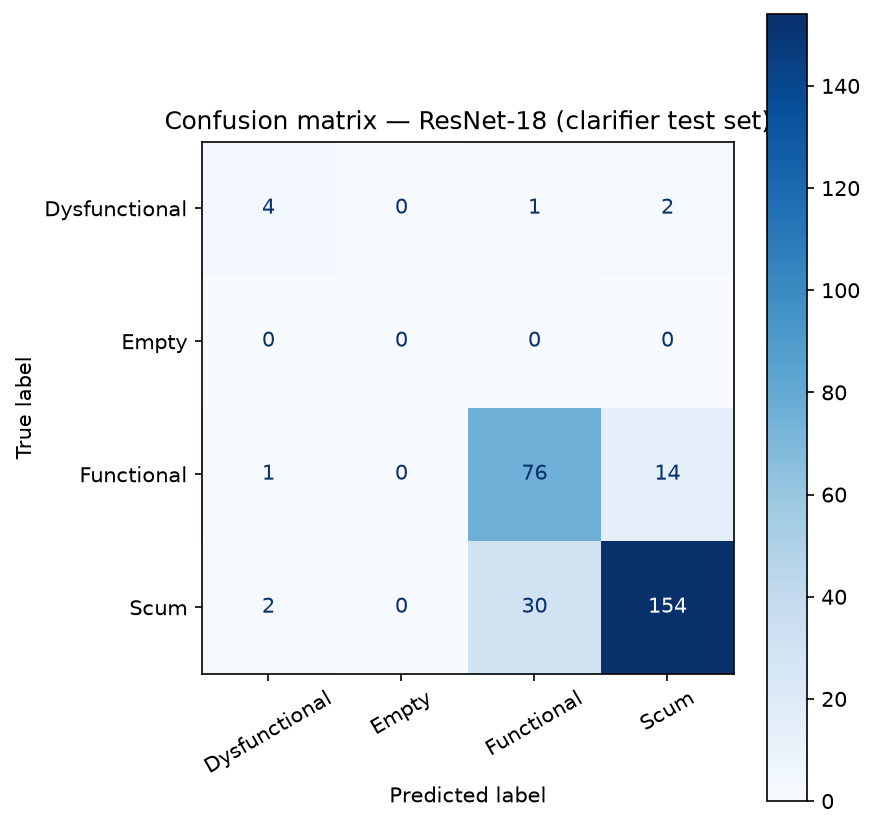

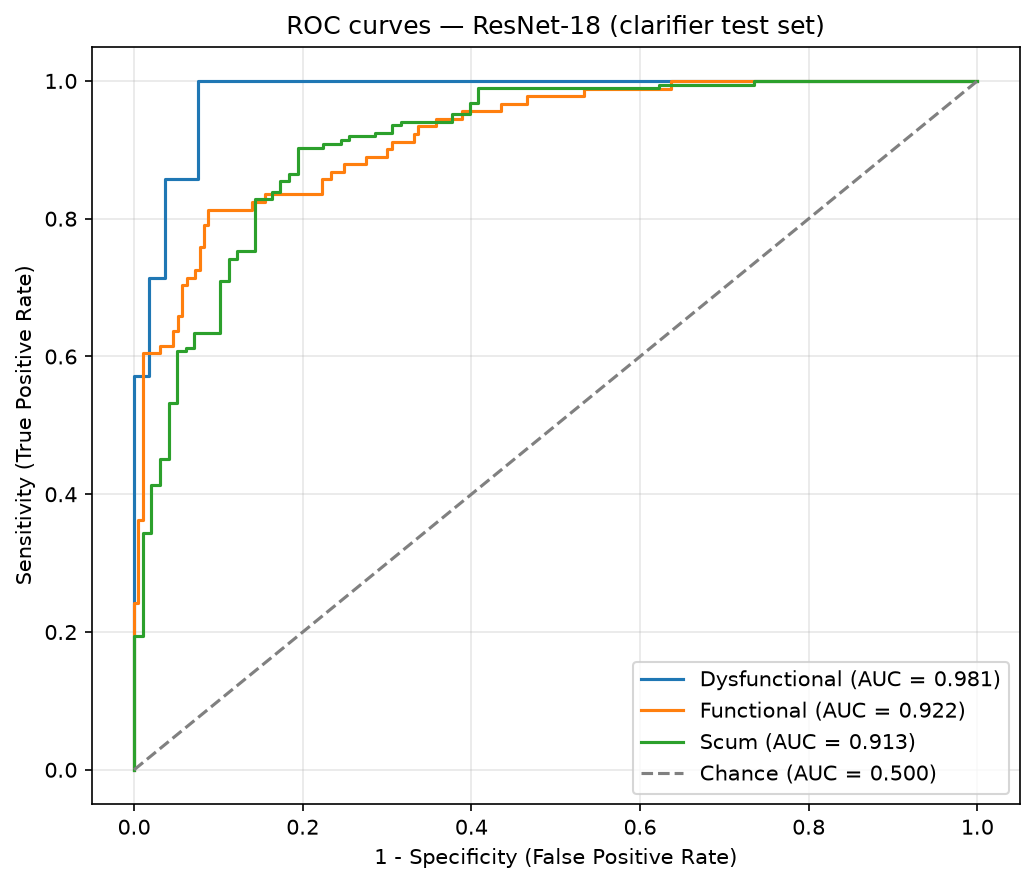

**ResNet-50** — test accuracy 0.761, mean AUC 0.872

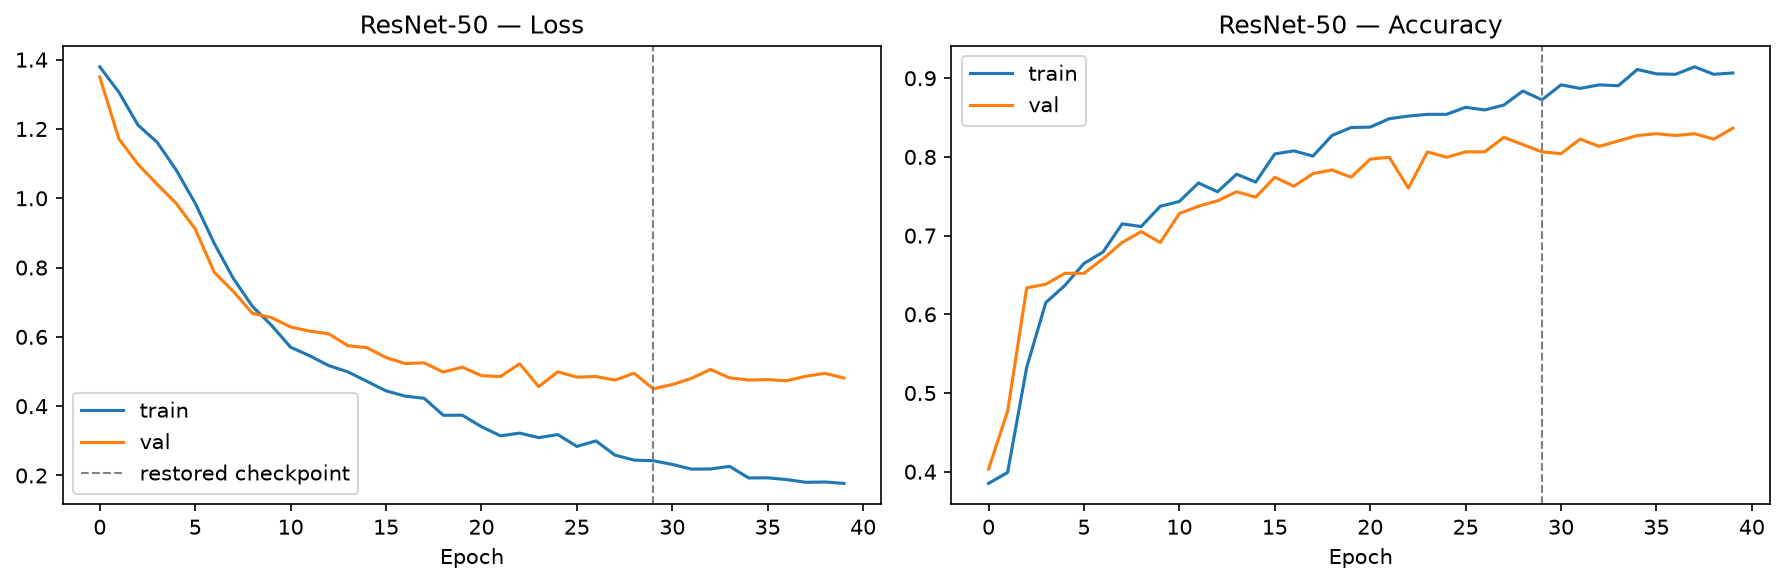

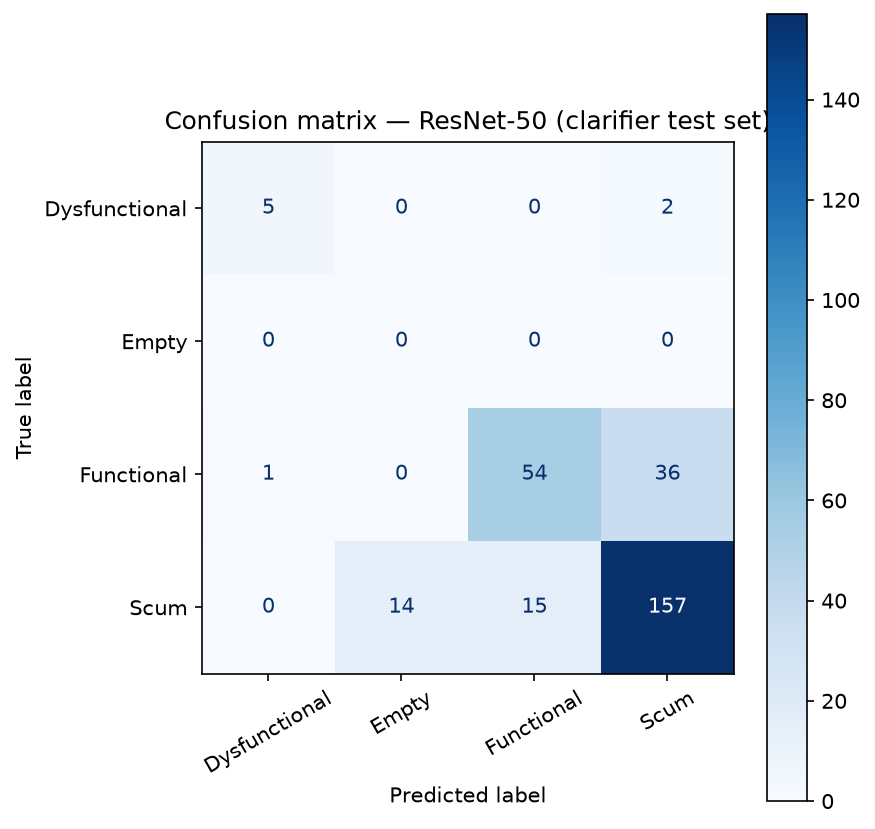

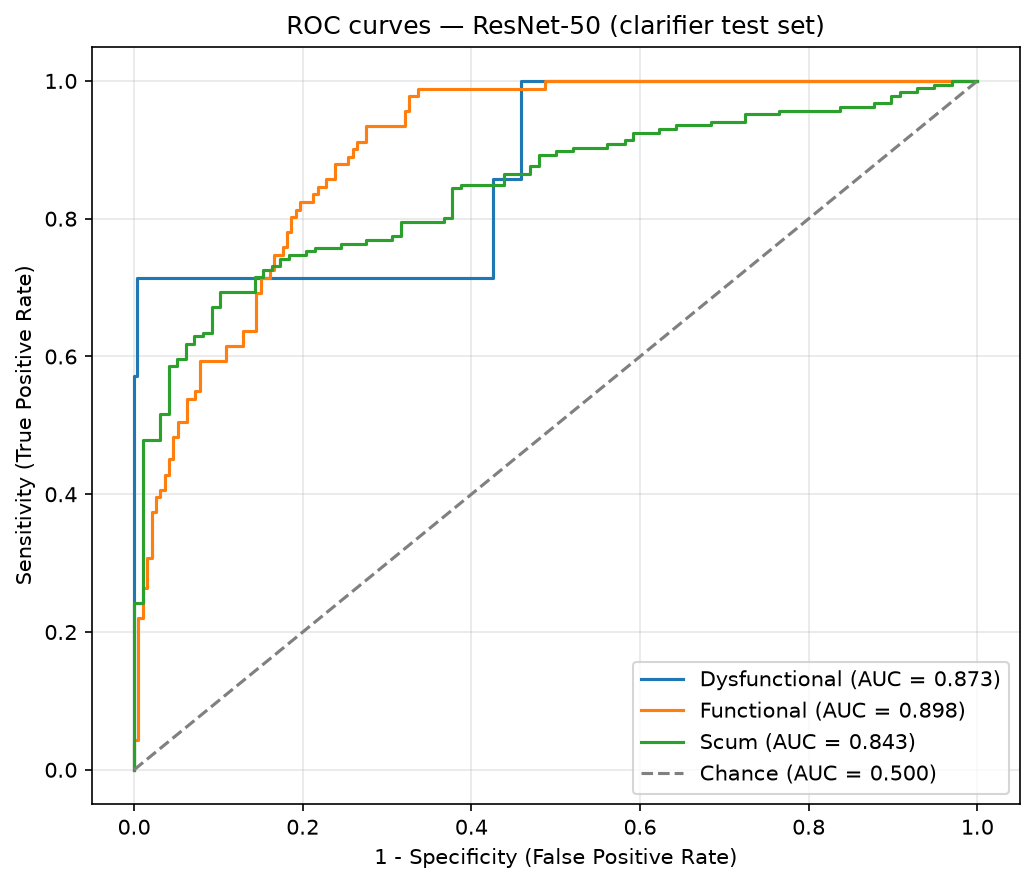

**DenseNet-121** — test accuracy 0.901, mean AUC 0.977

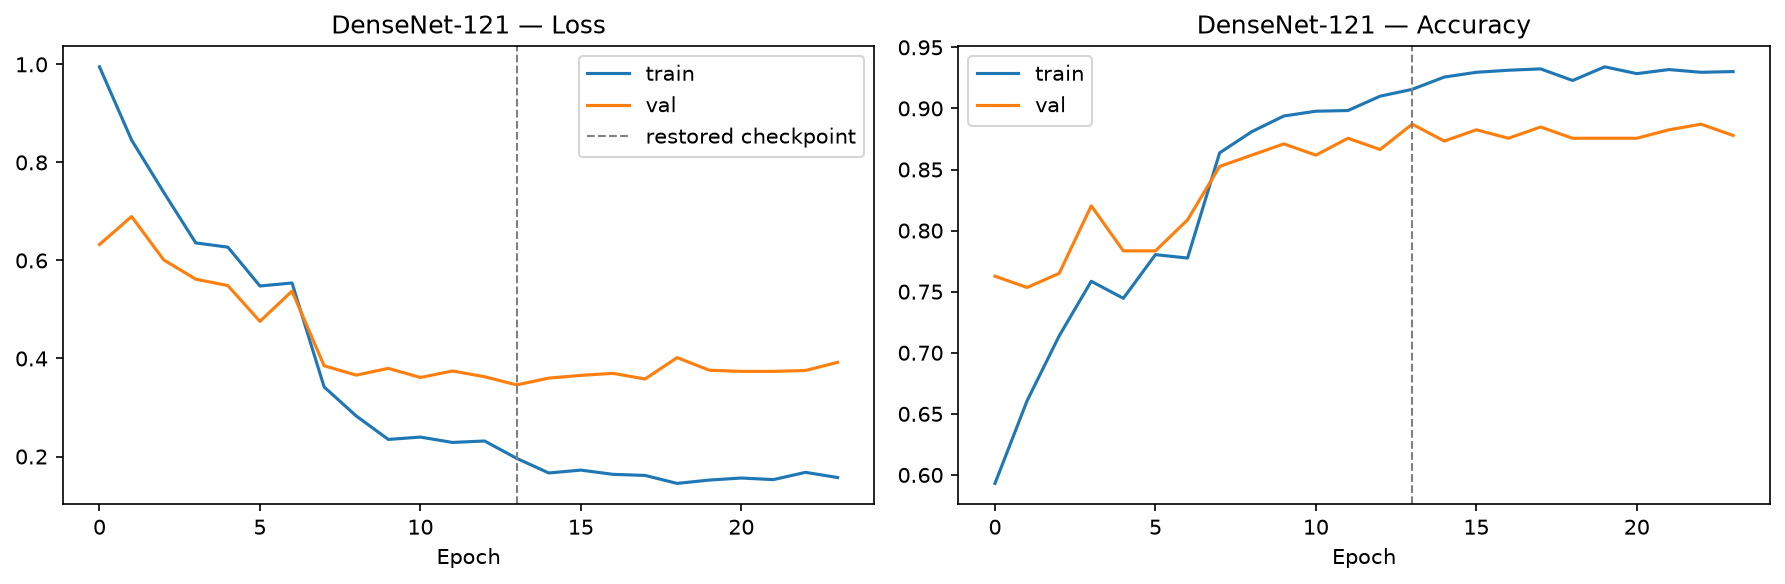

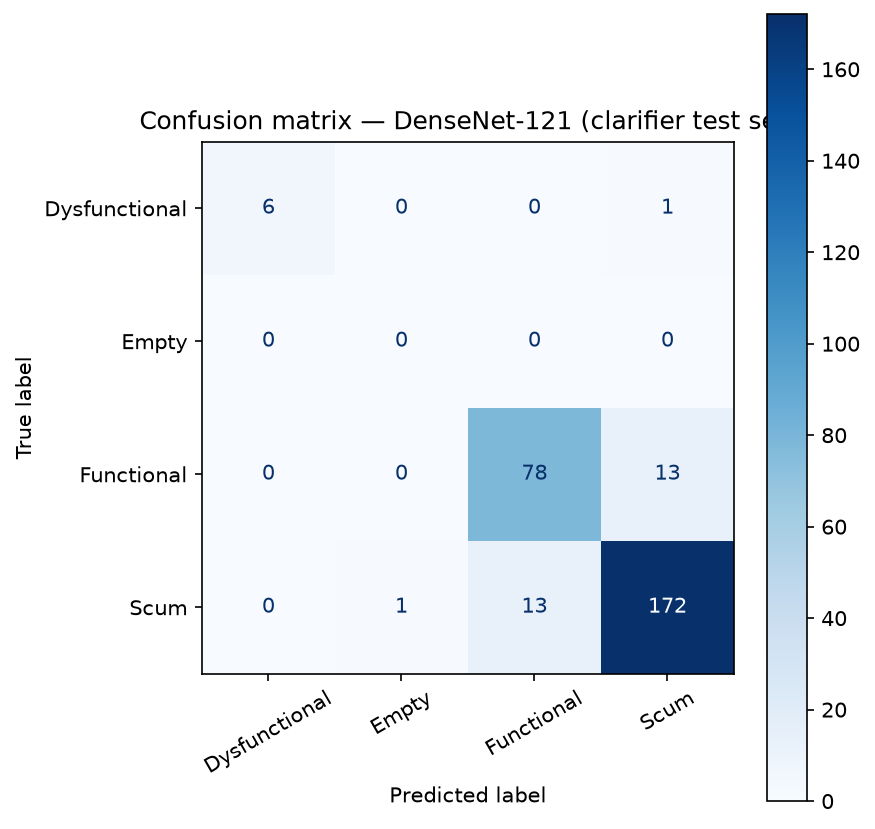

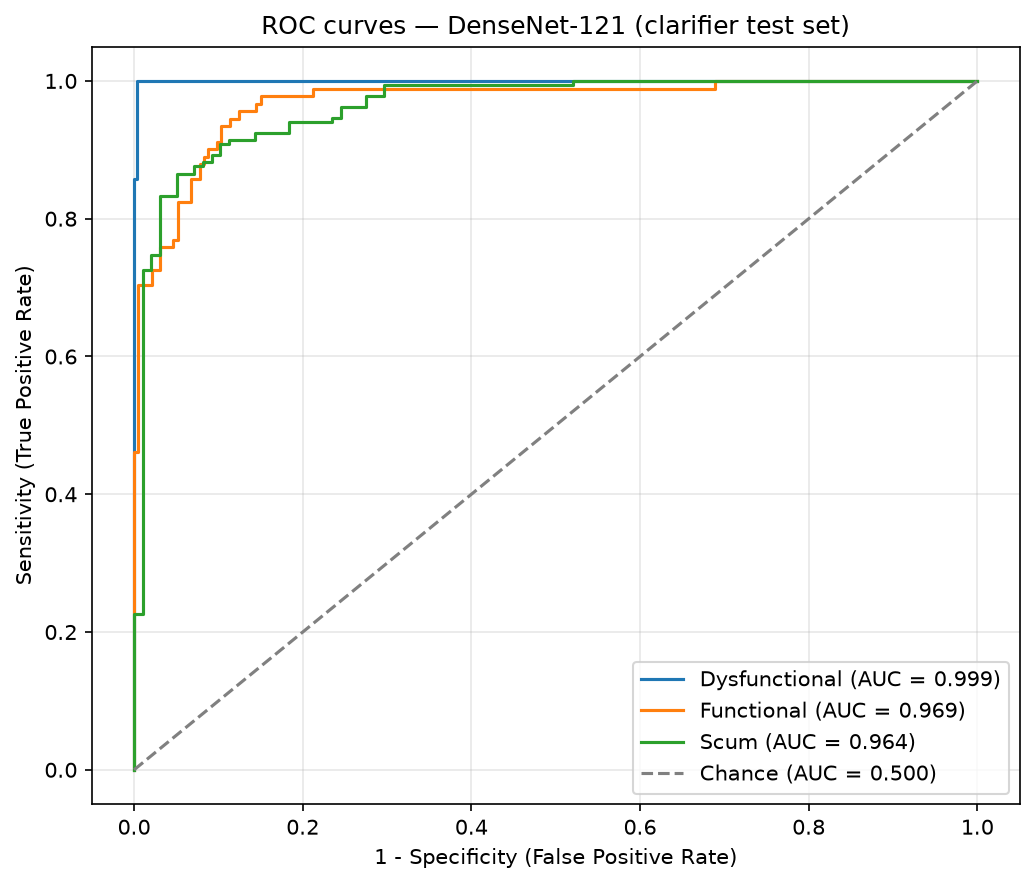

**InceptionNet v3** — test accuracy 0.799, mean AUC 0.929

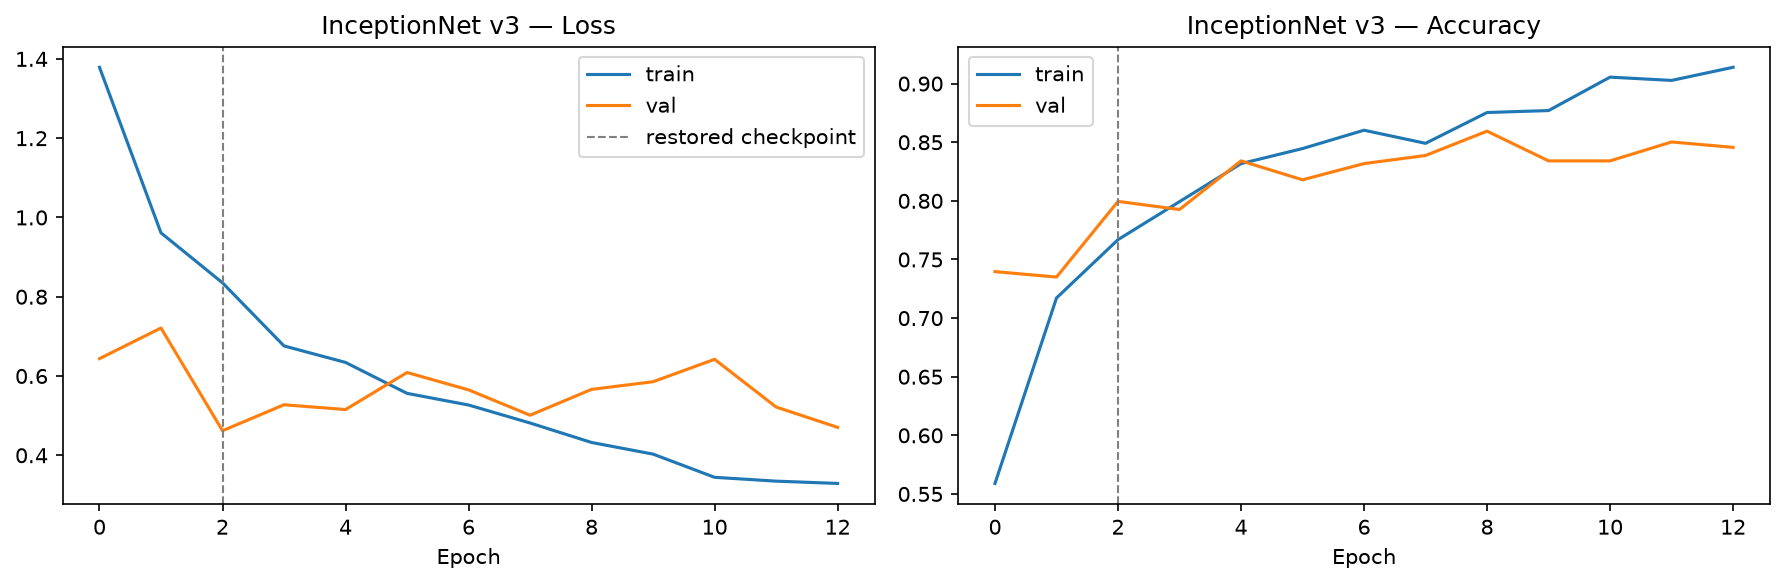

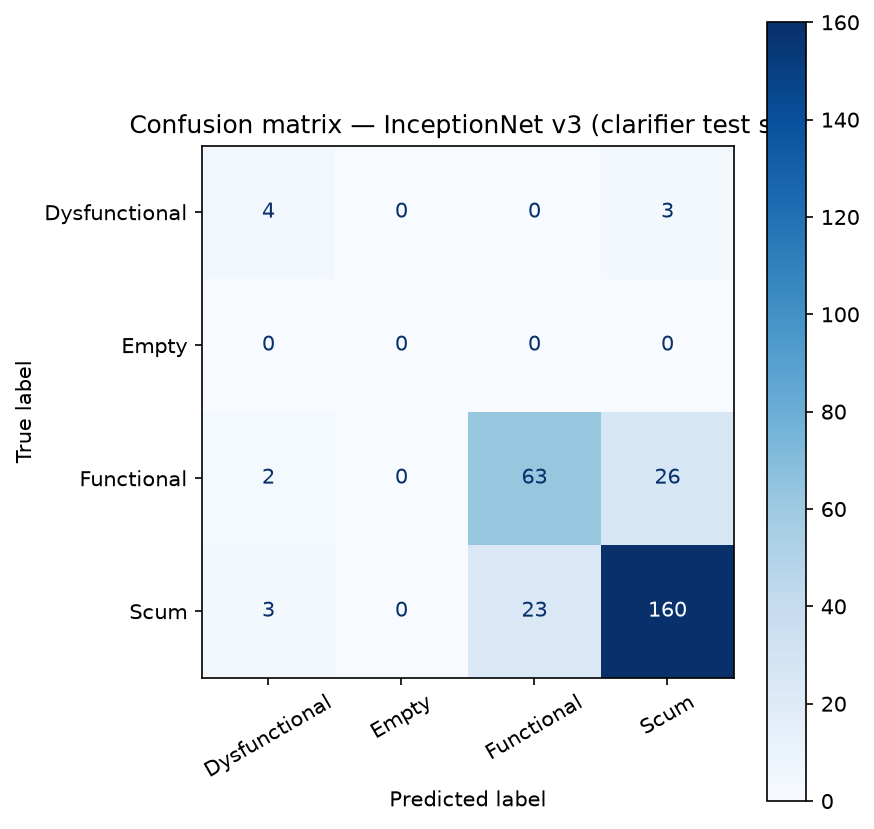

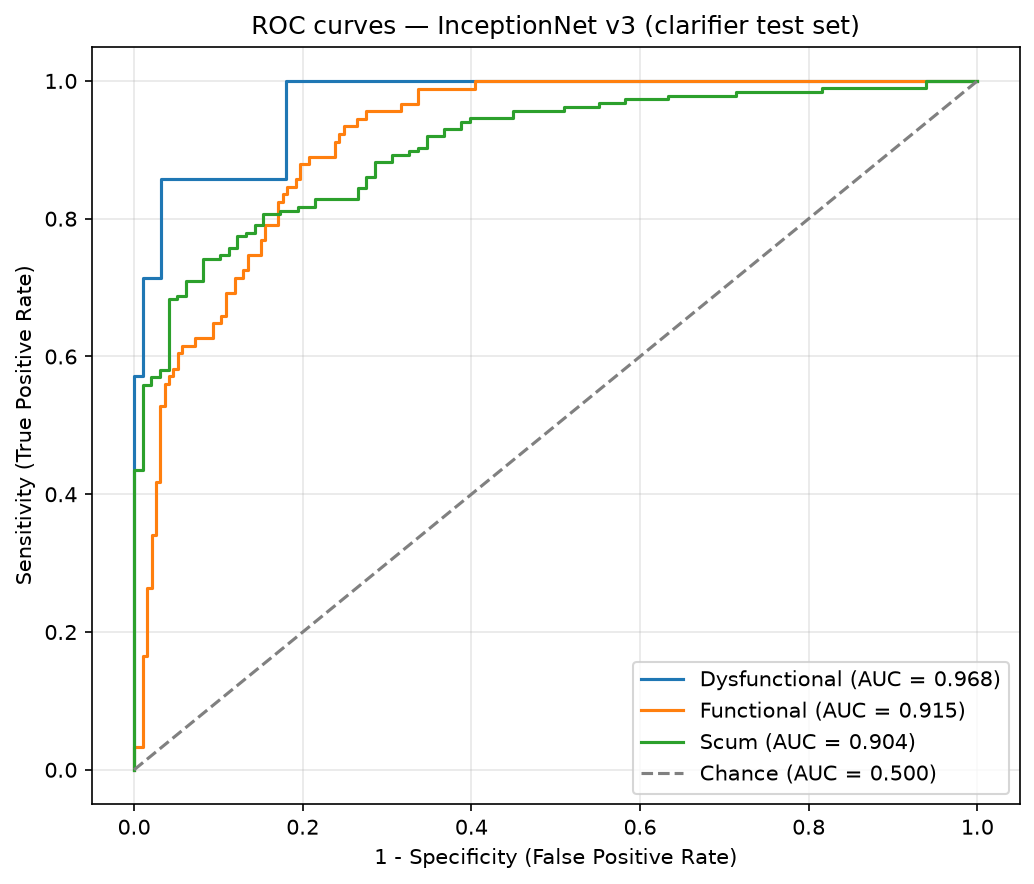

**EfficientNet-B0** — test accuracy 0.845, mean AUC 0.929

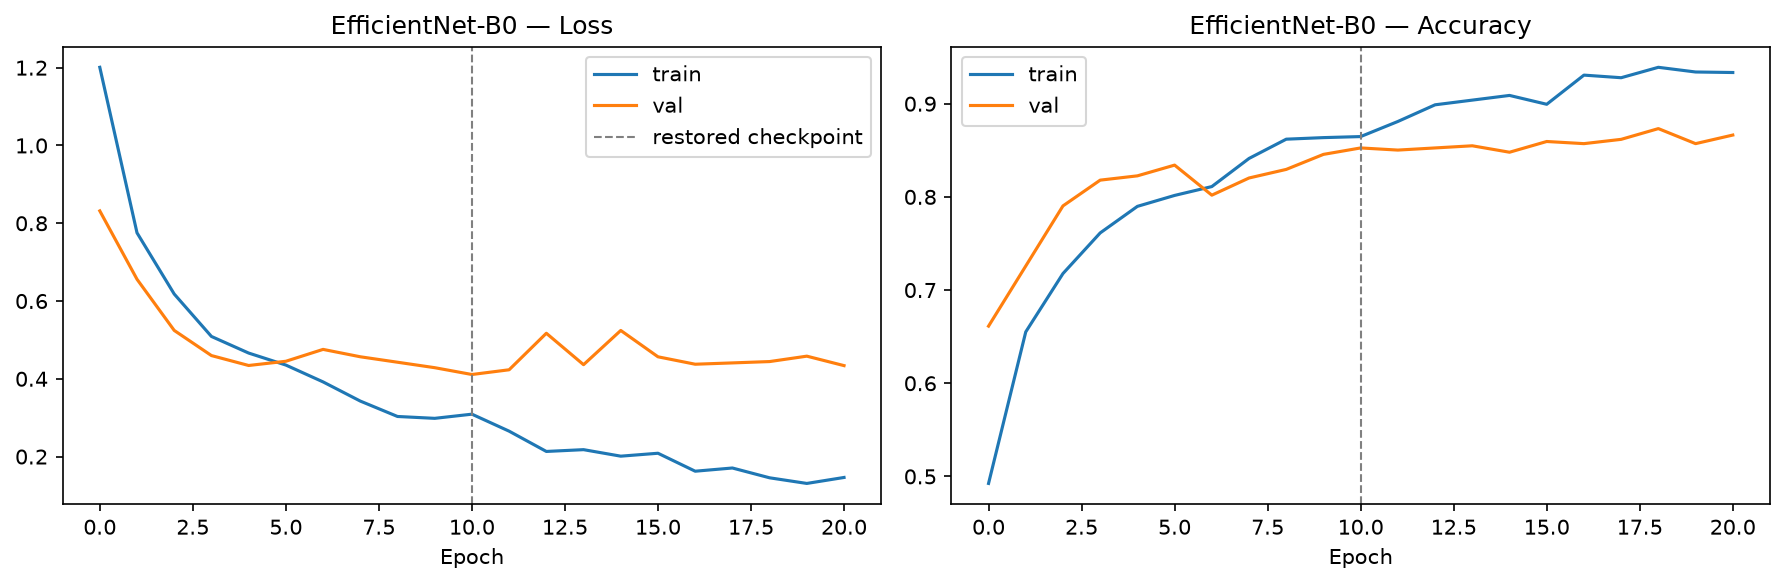

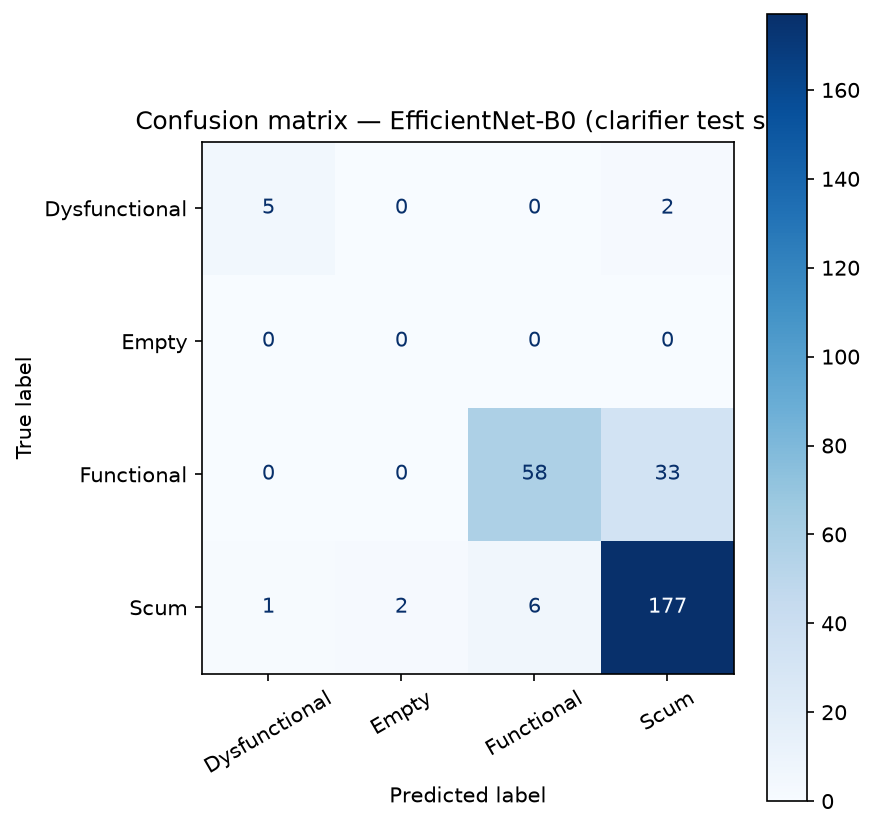

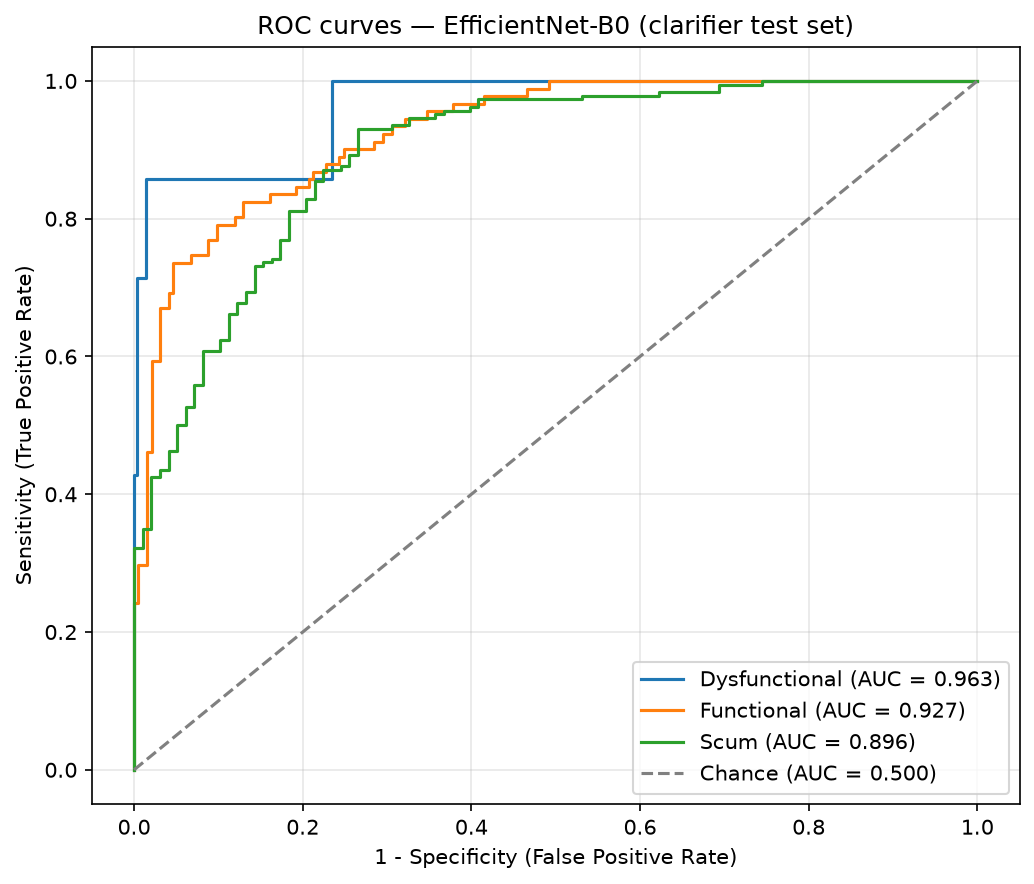

**ConvNeXt-Tiny** — test accuracy 0.792, mean AUC 0.923

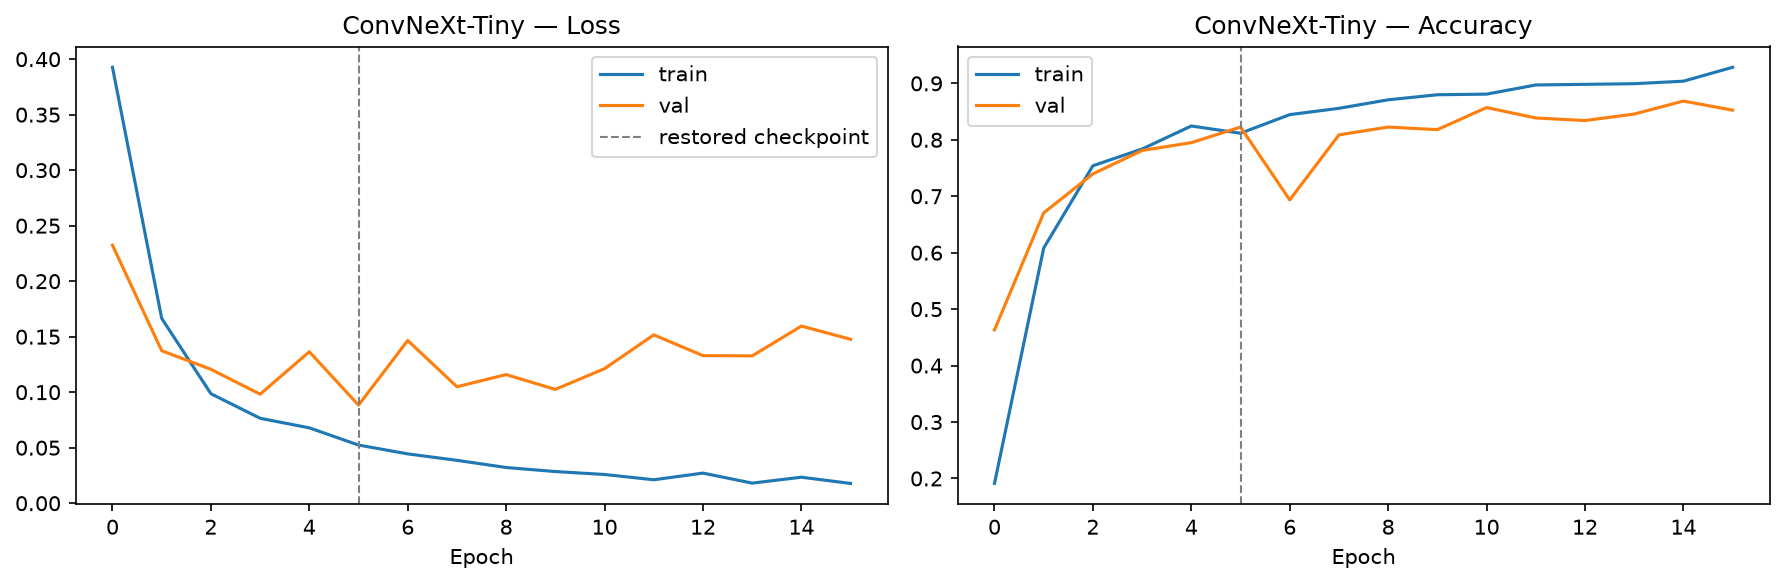

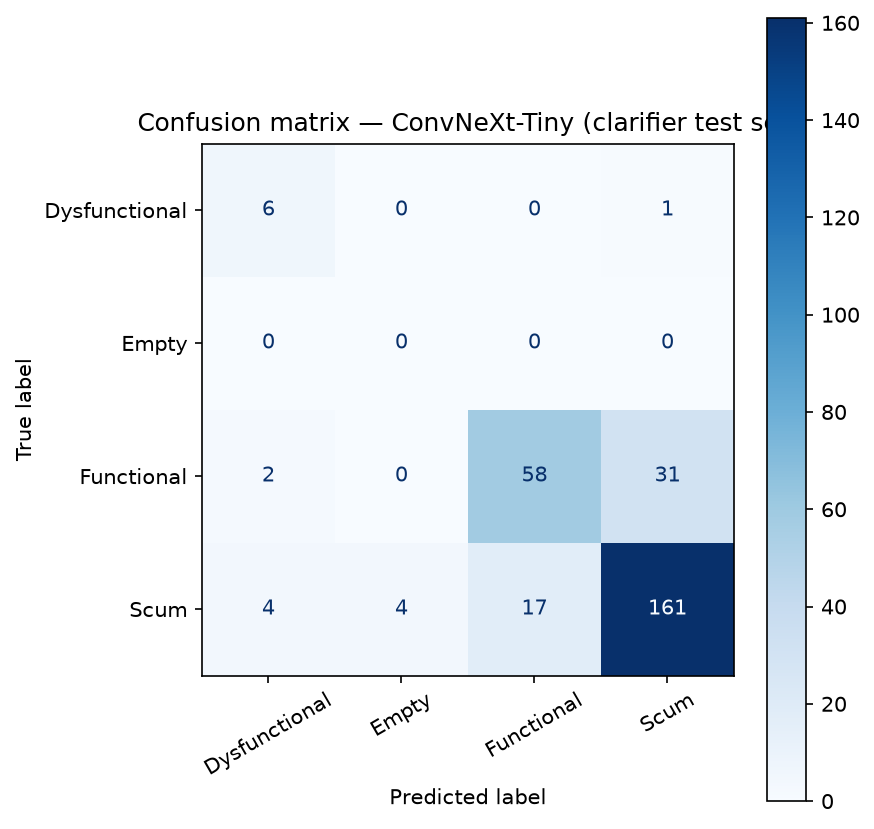

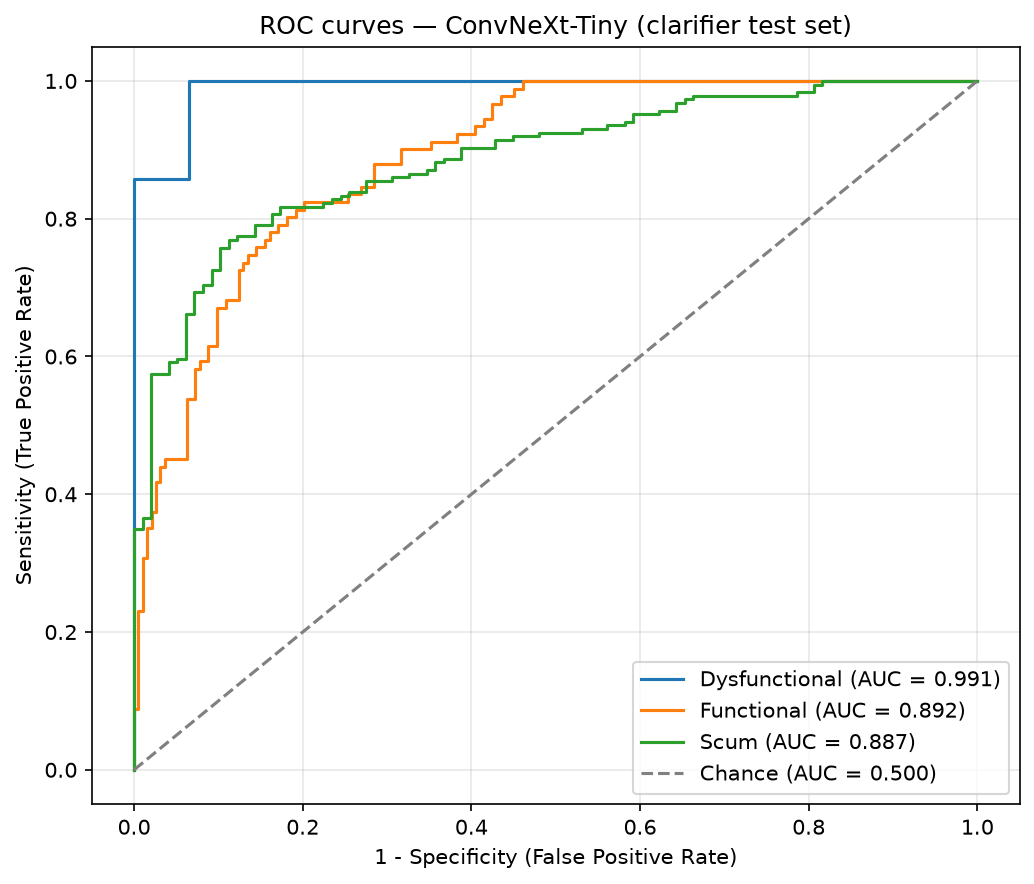

### Fisantekraal (held out)

**ResNet-18** — test accuracy 0.679, mean AUC 0.876

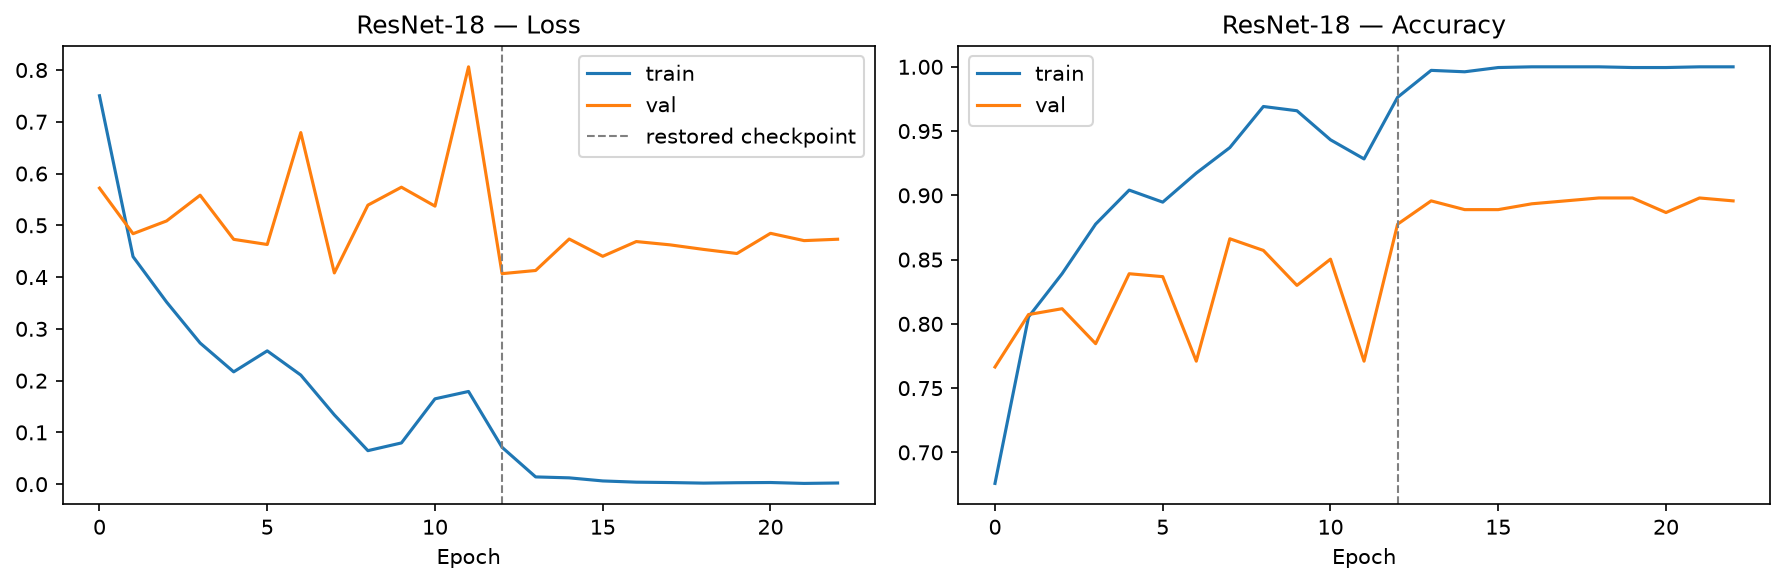

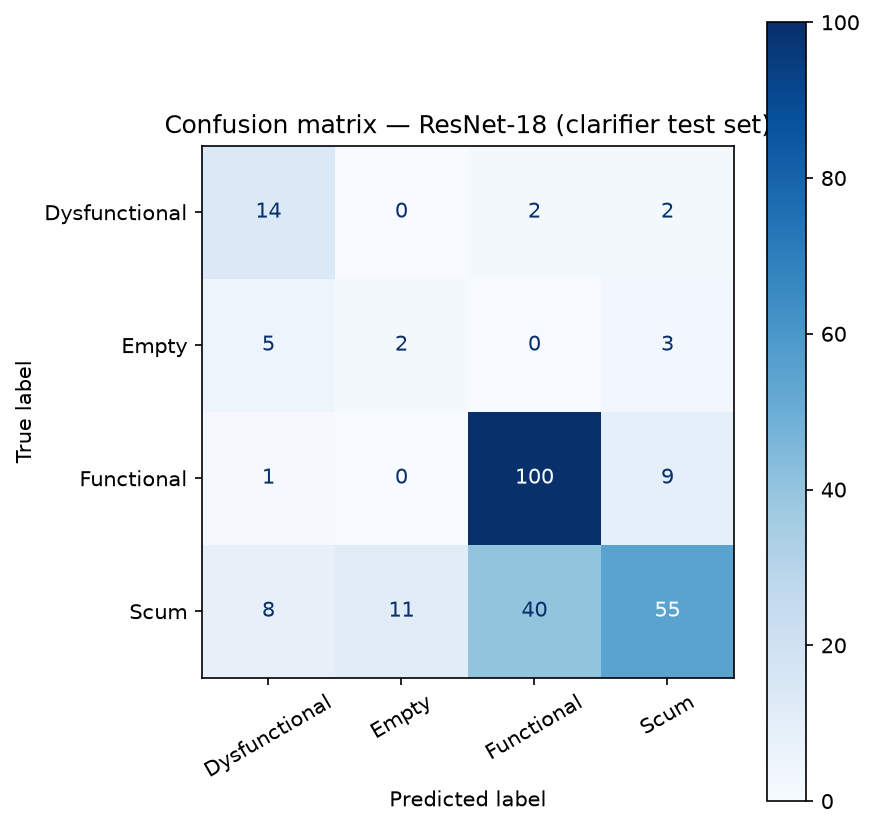

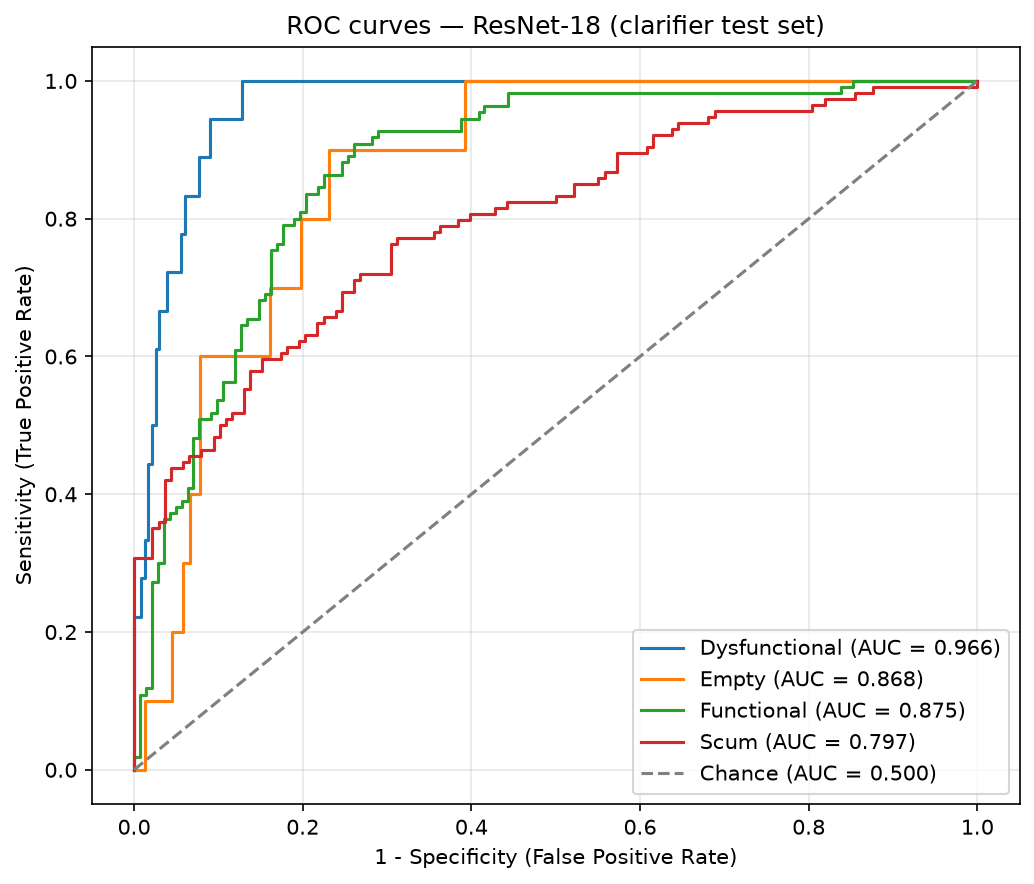

**ResNet-50** — test accuracy 0.738, mean AUC 0.930

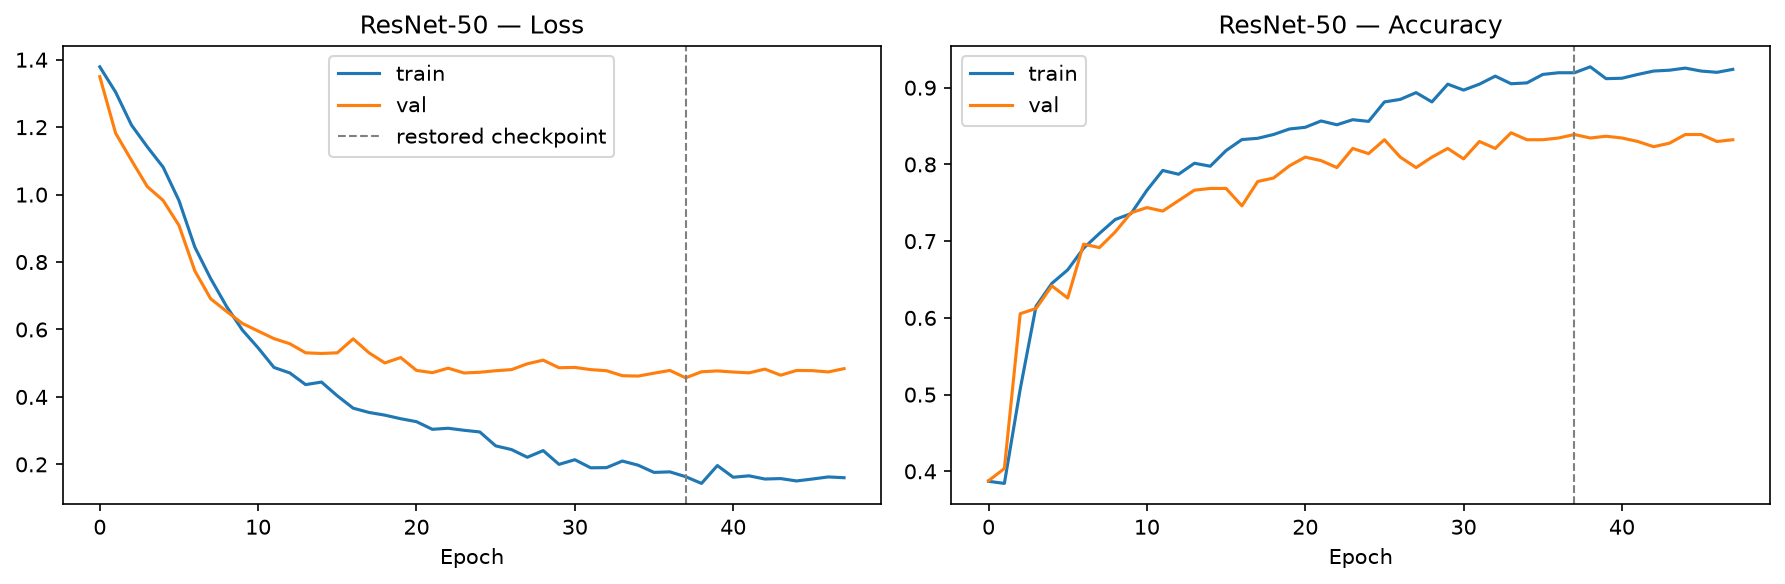

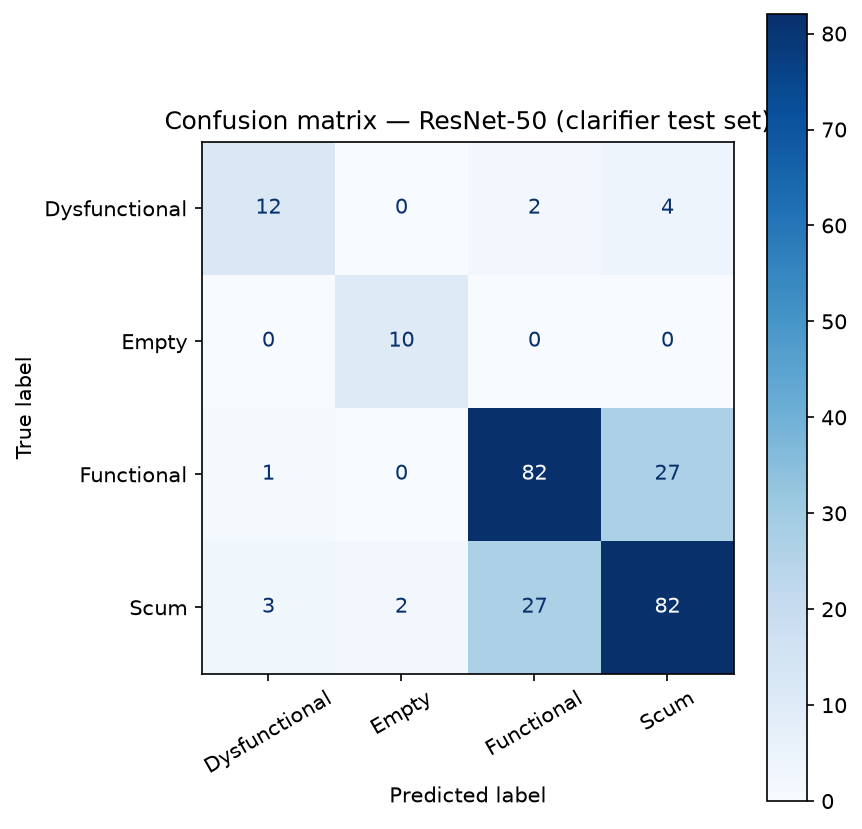

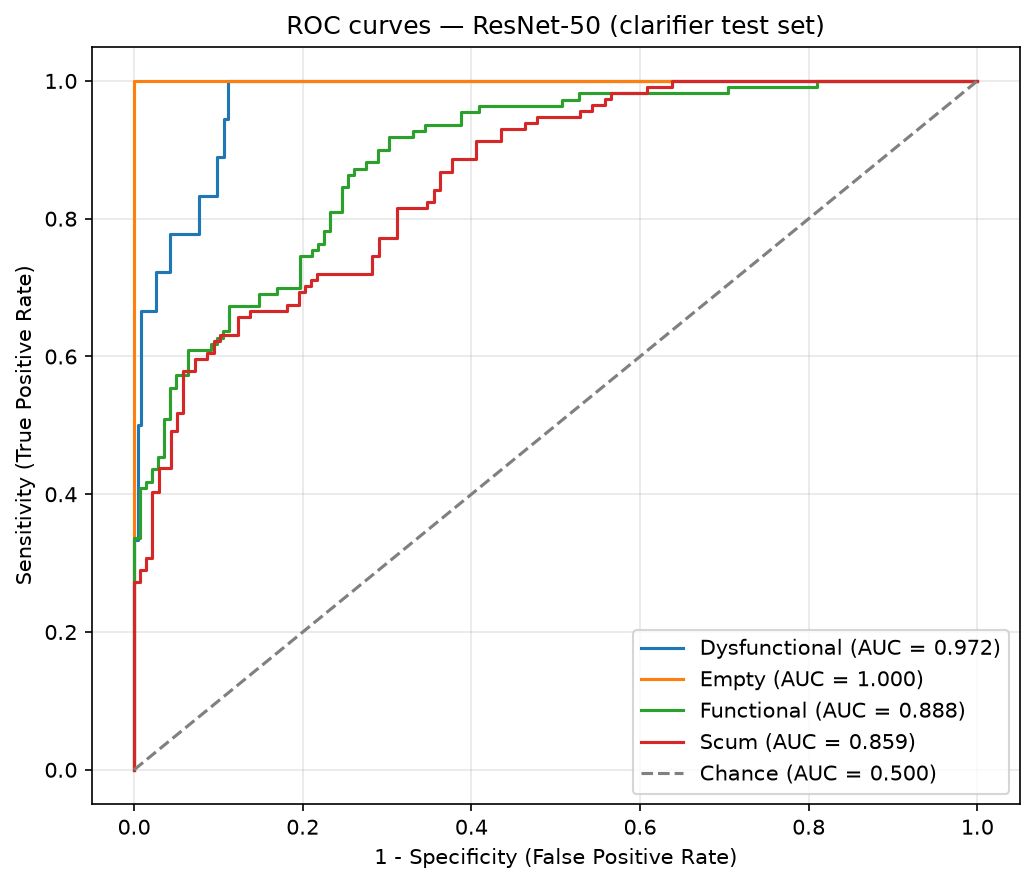

**DenseNet-121** — test accuracy 0.778, mean AUC 0.931

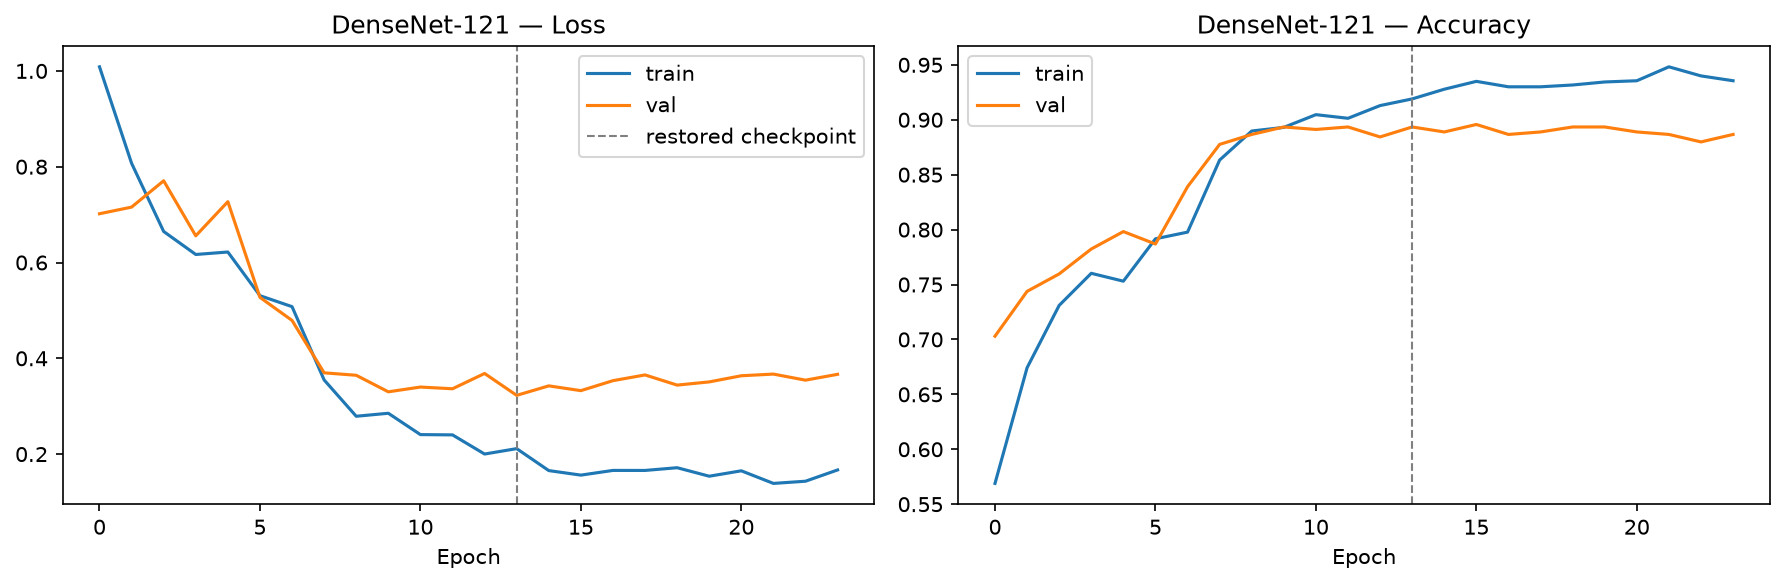

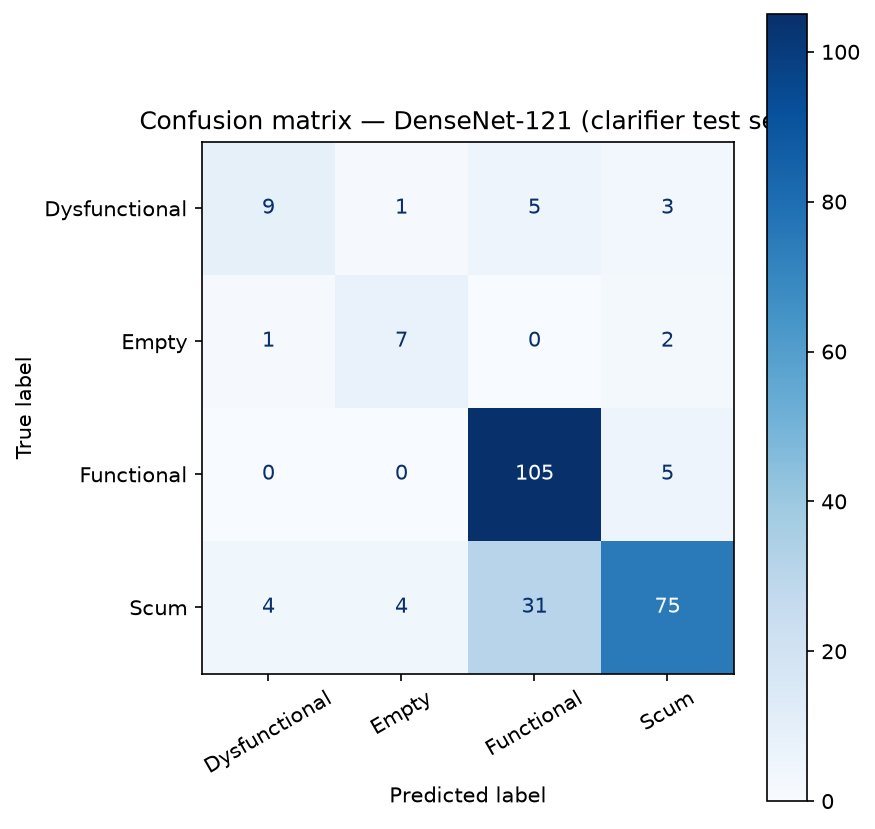

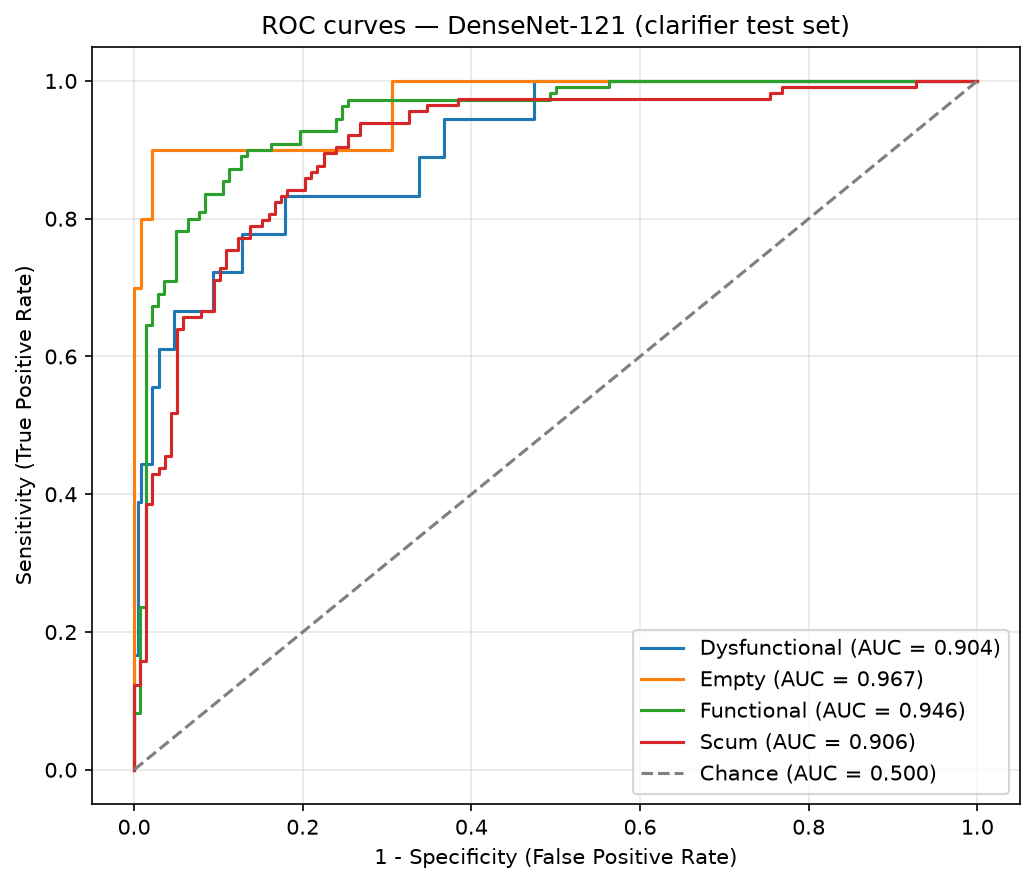

**InceptionNet v3** — test accuracy 0.750, mean AUC 0.925

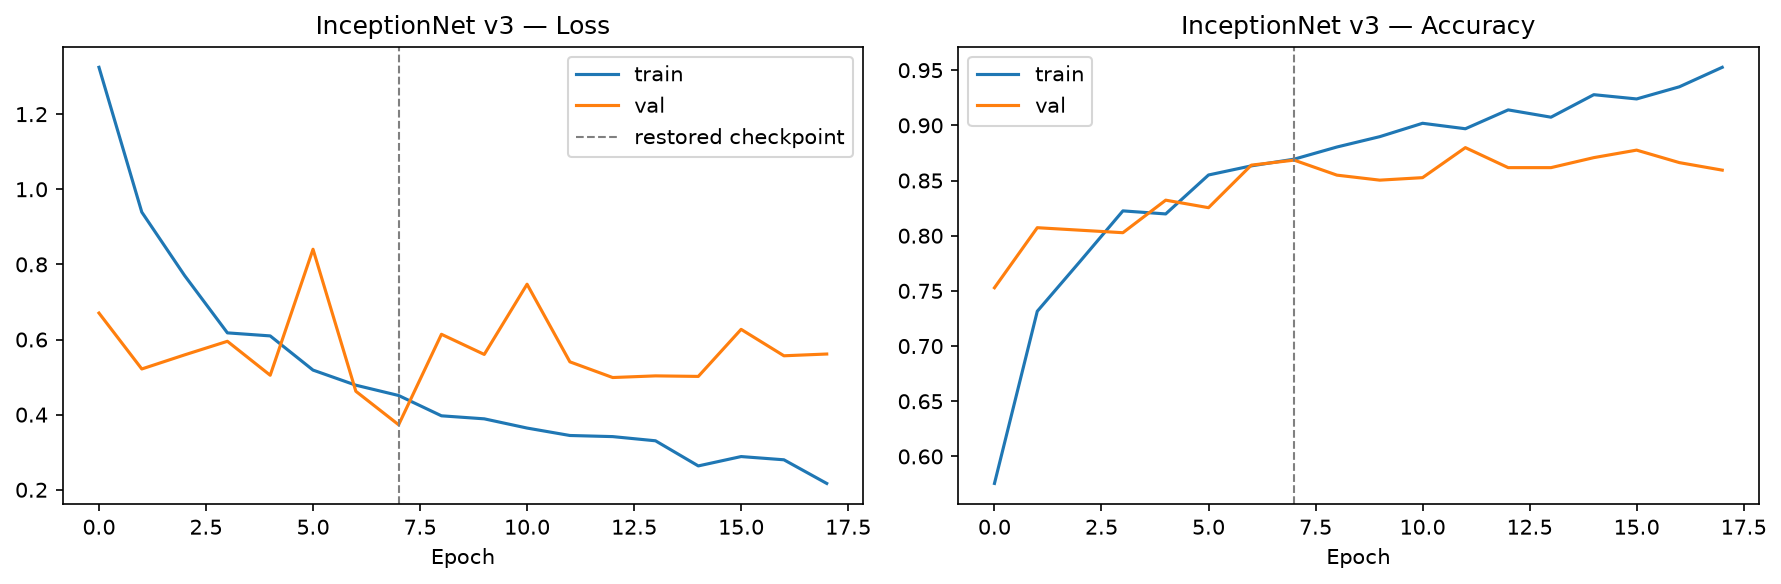

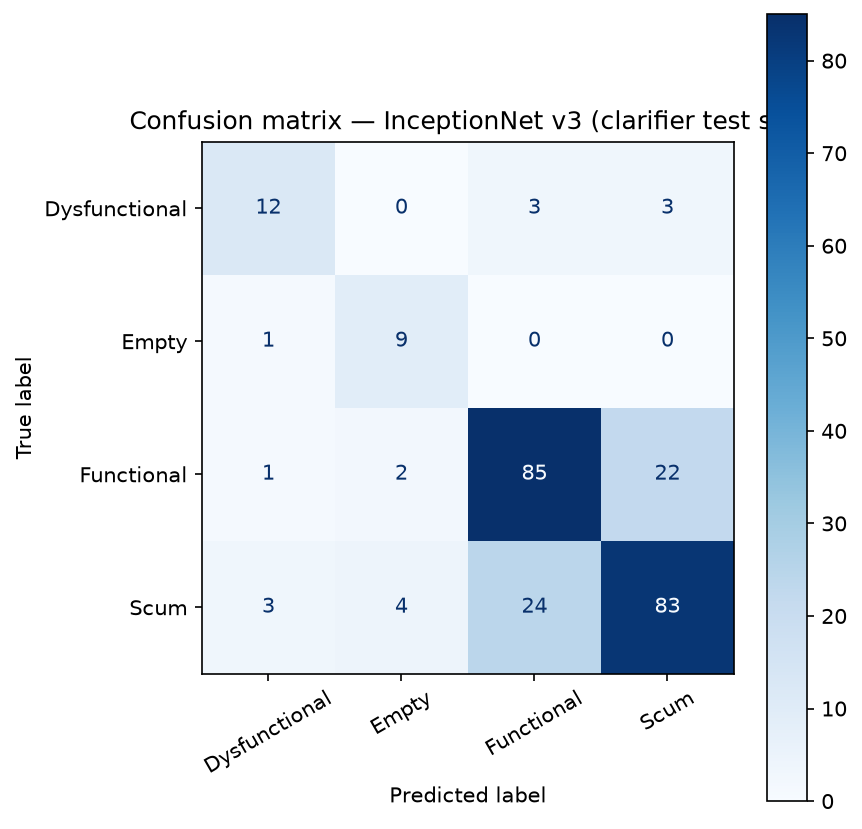

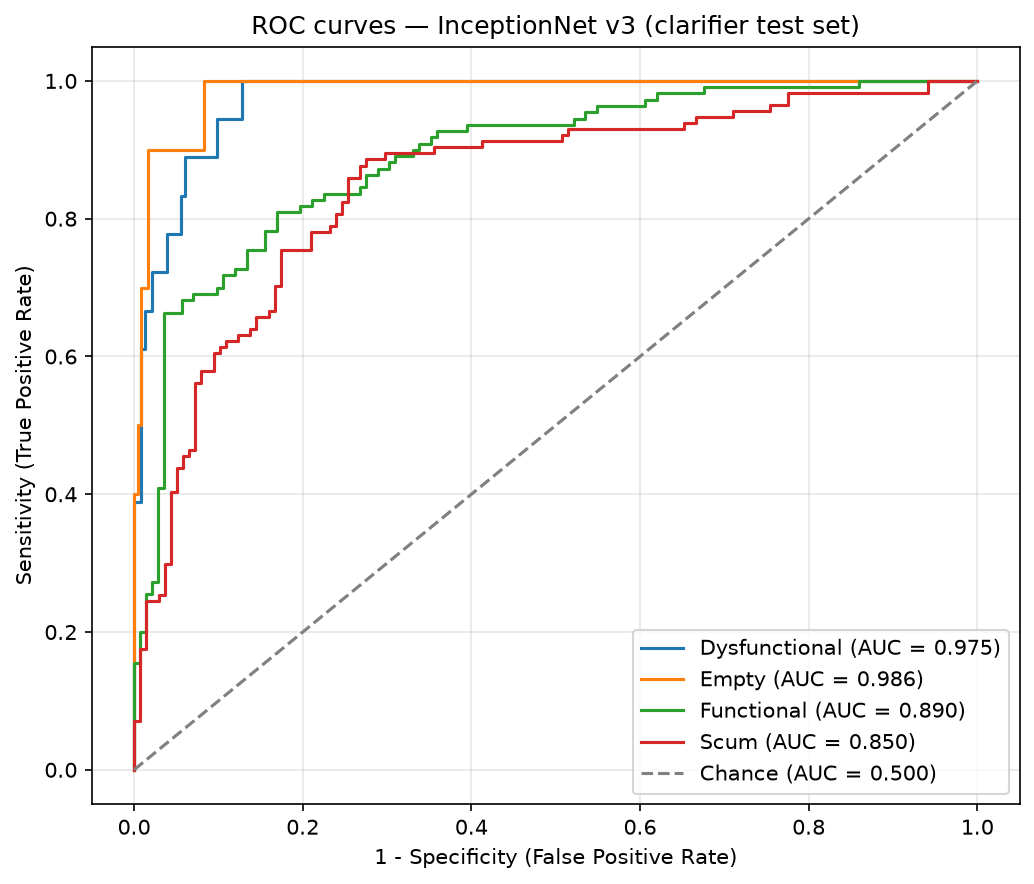

**EfficientNet-B0** — test accuracy 0.750, mean AUC 0.935

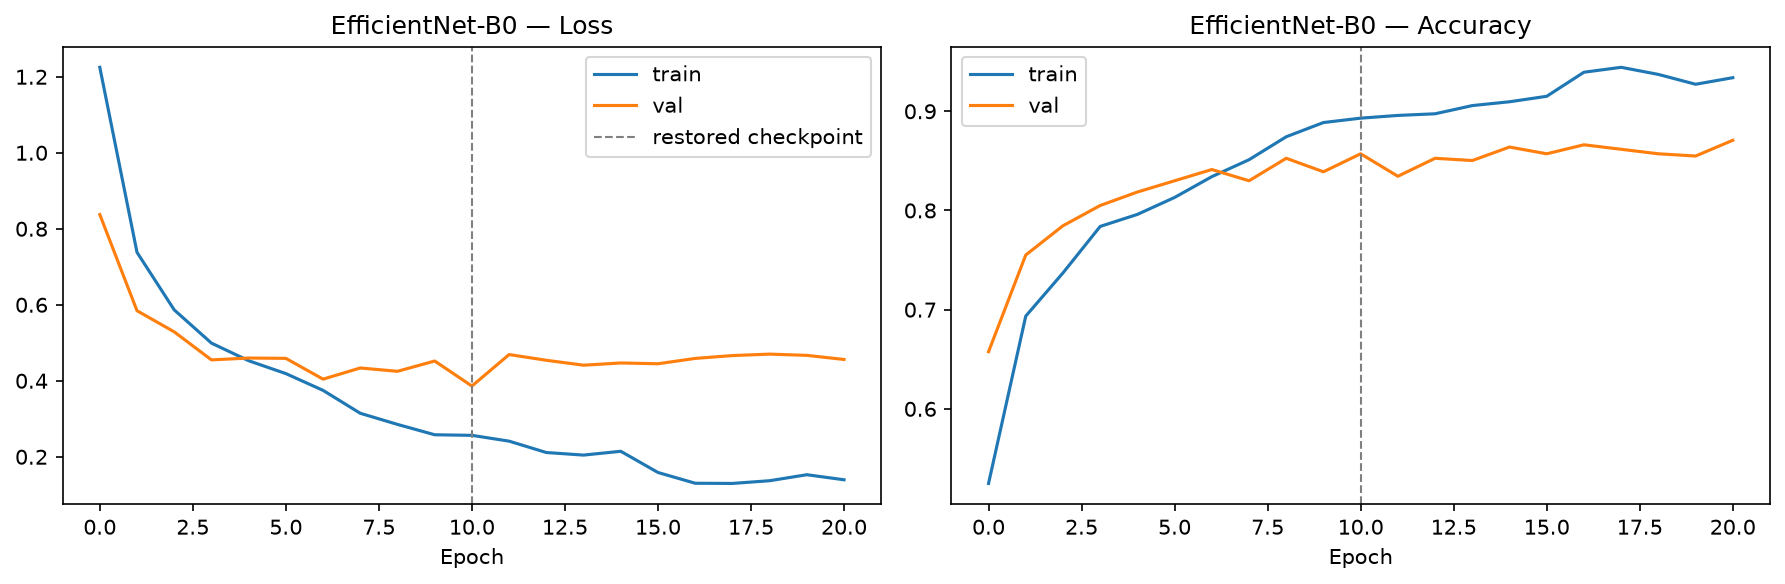

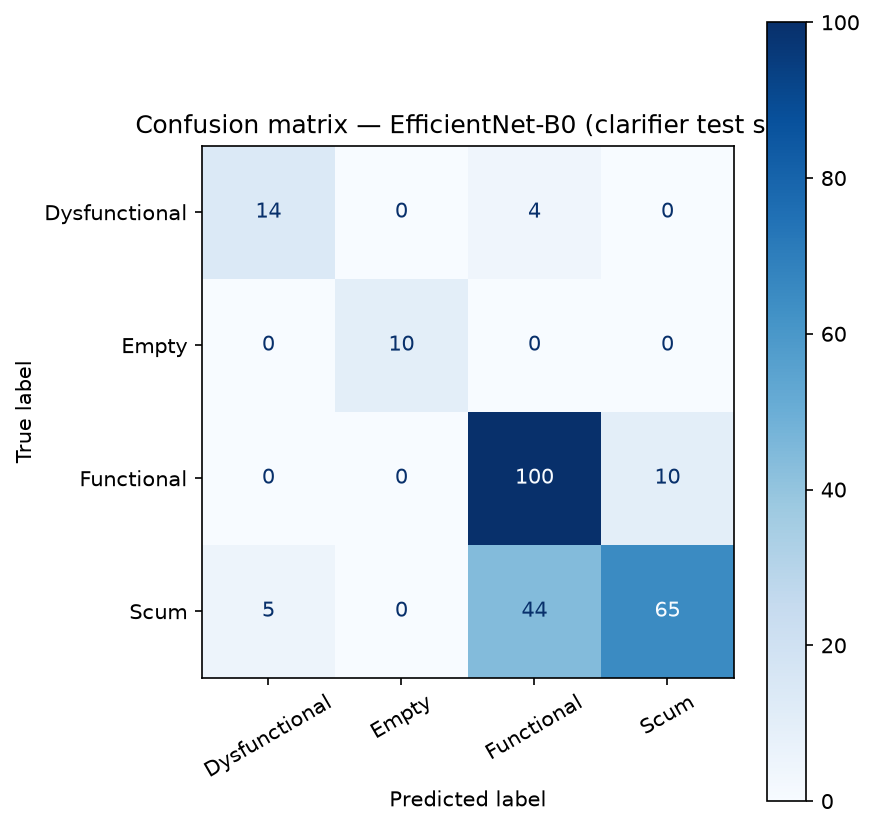

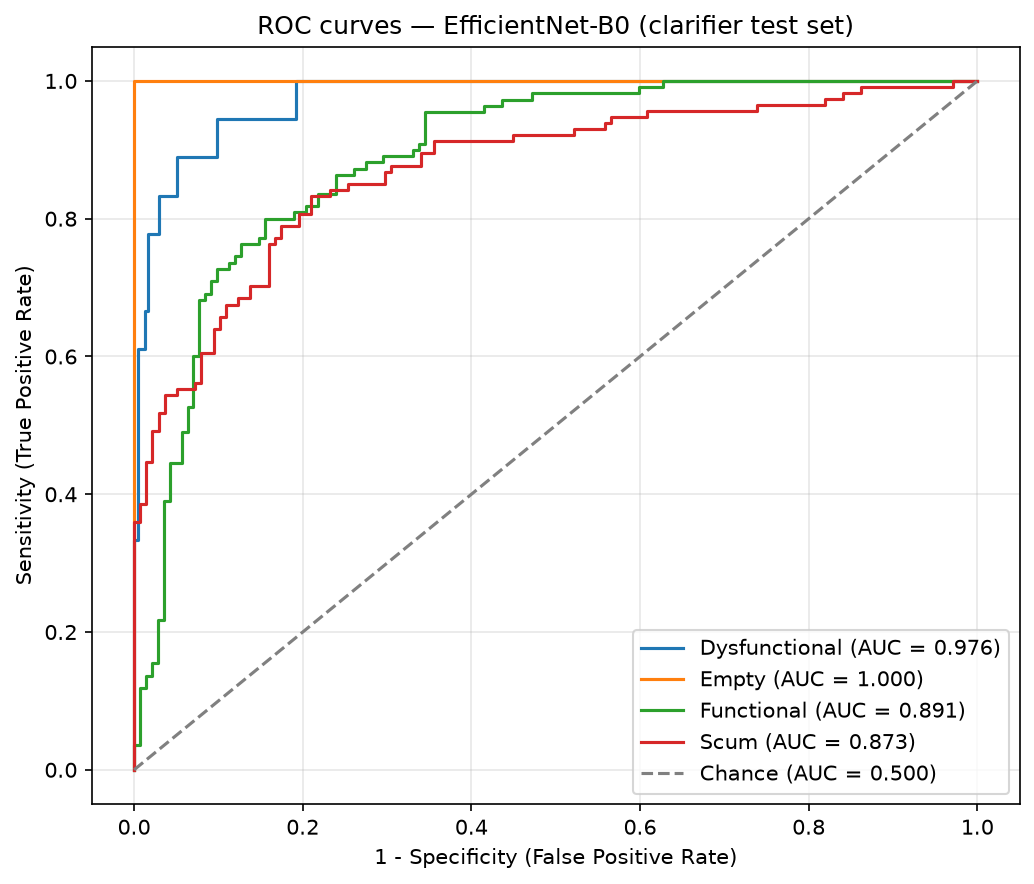

**ConvNeXt-Tiny** — test accuracy 0.603, mean AUC 0.905

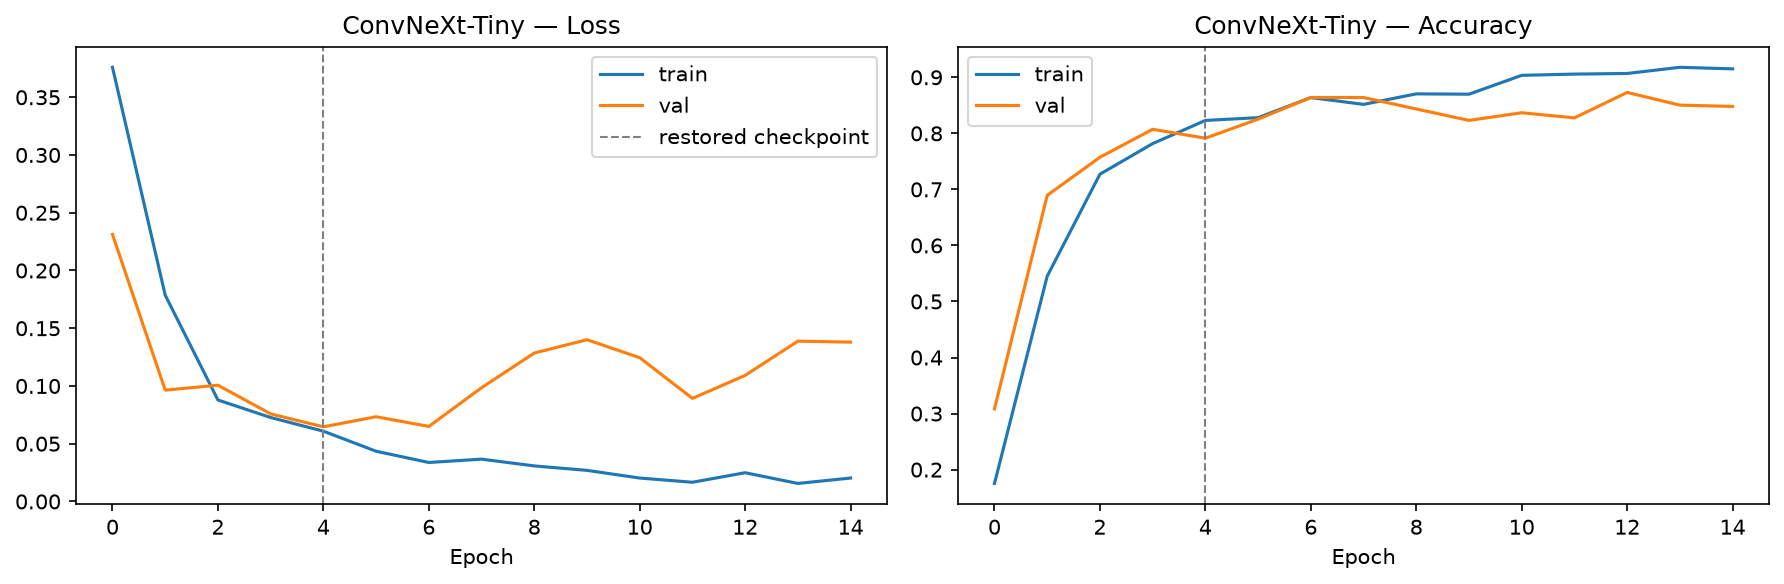

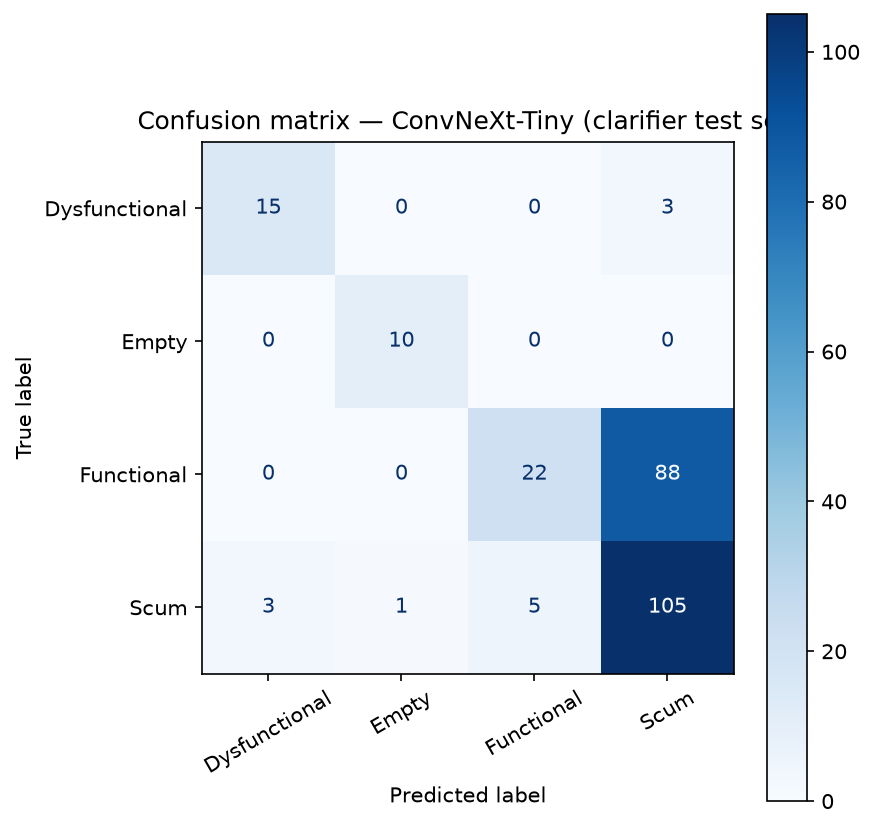

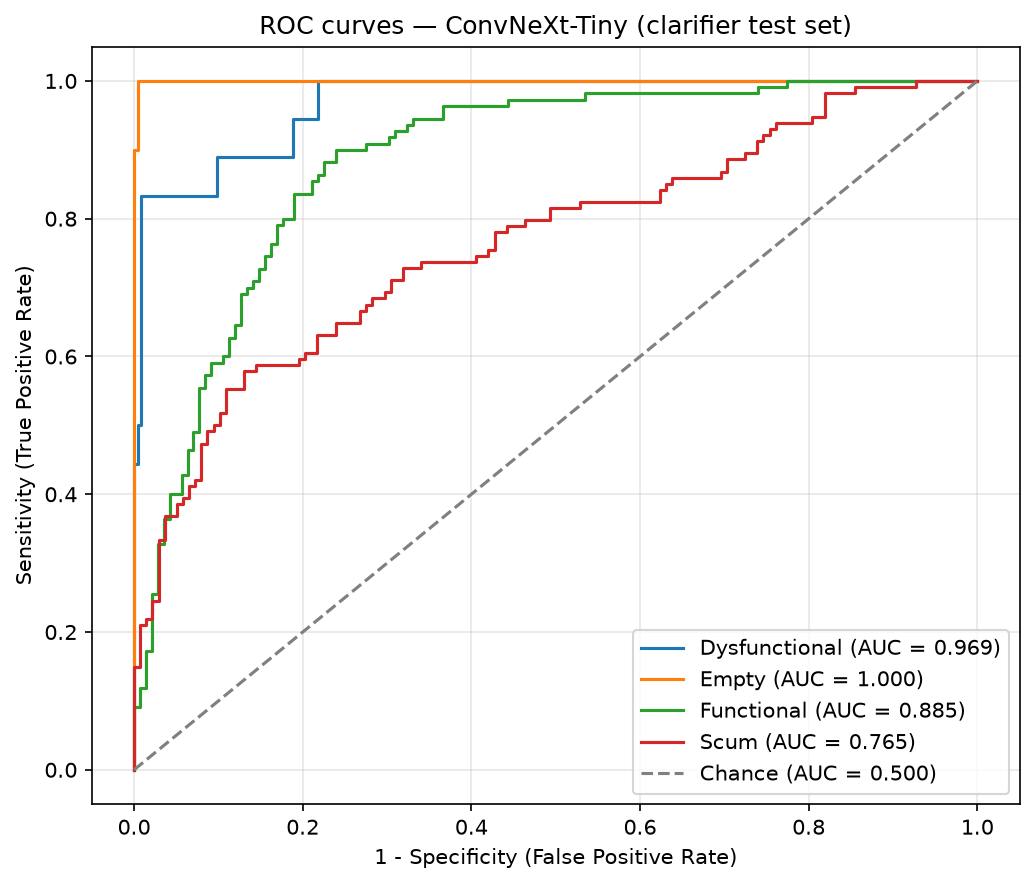

### NoordelikeWerke (held out)

**ResNet-18** — test accuracy 0.802, mean AUC 0.927

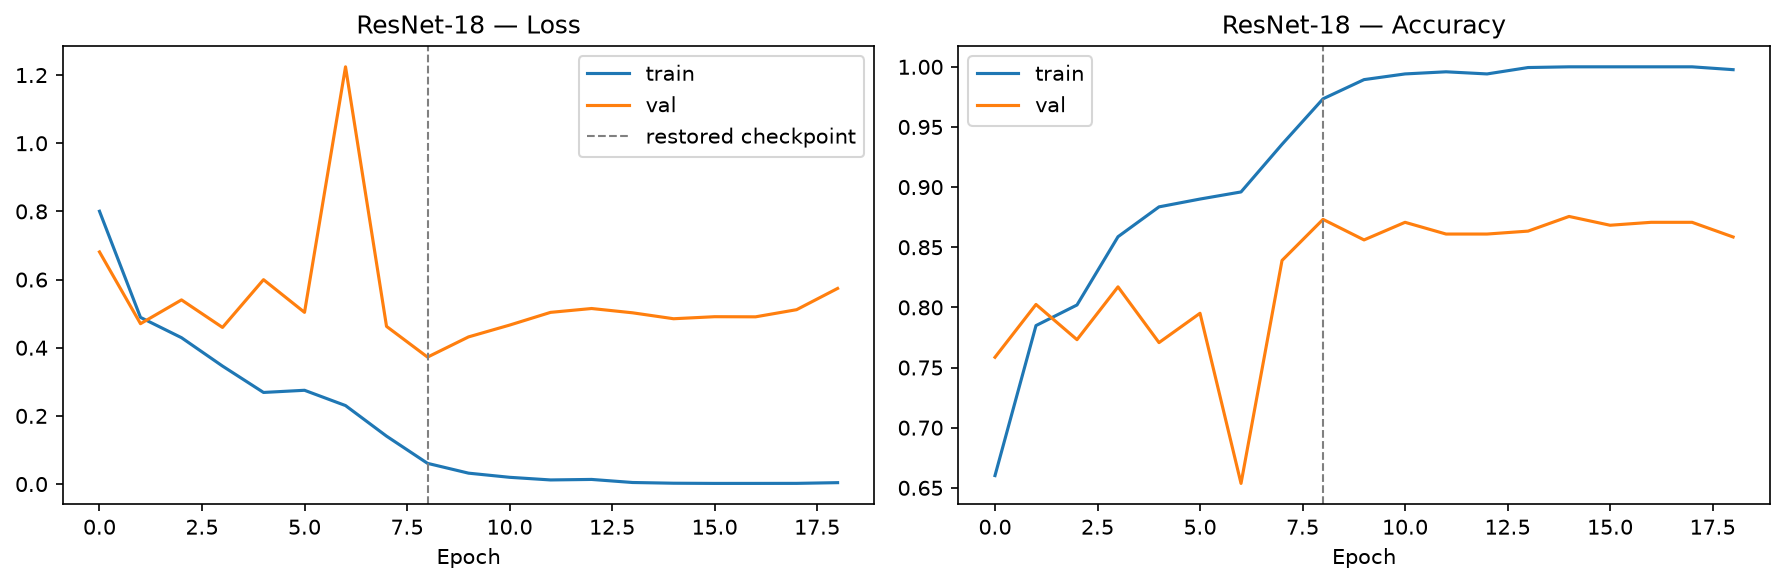

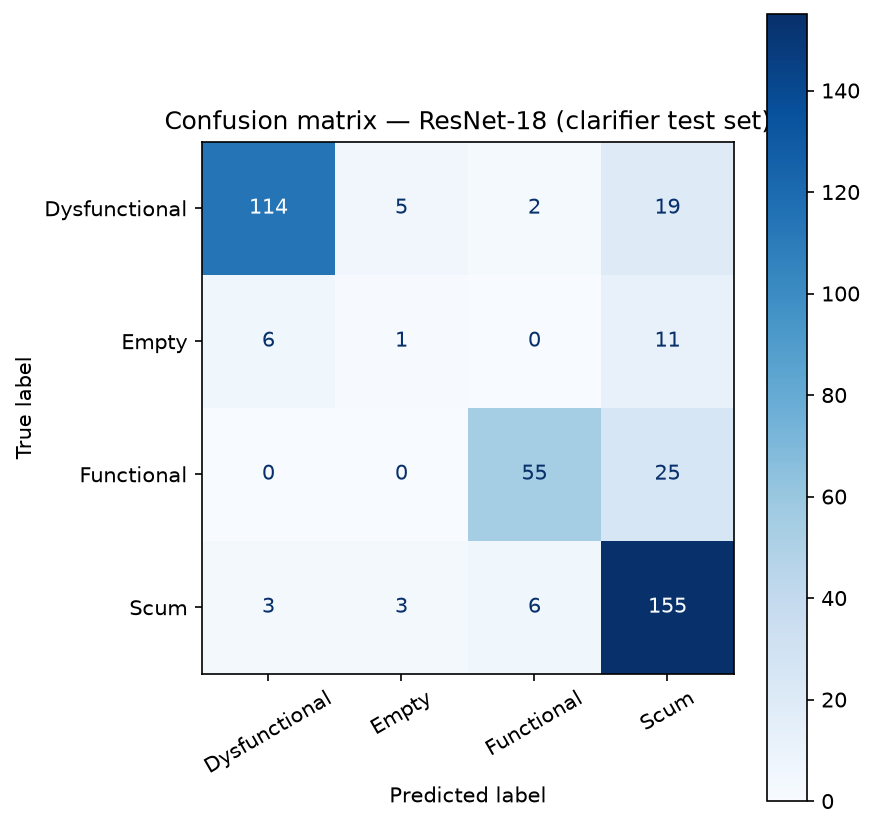

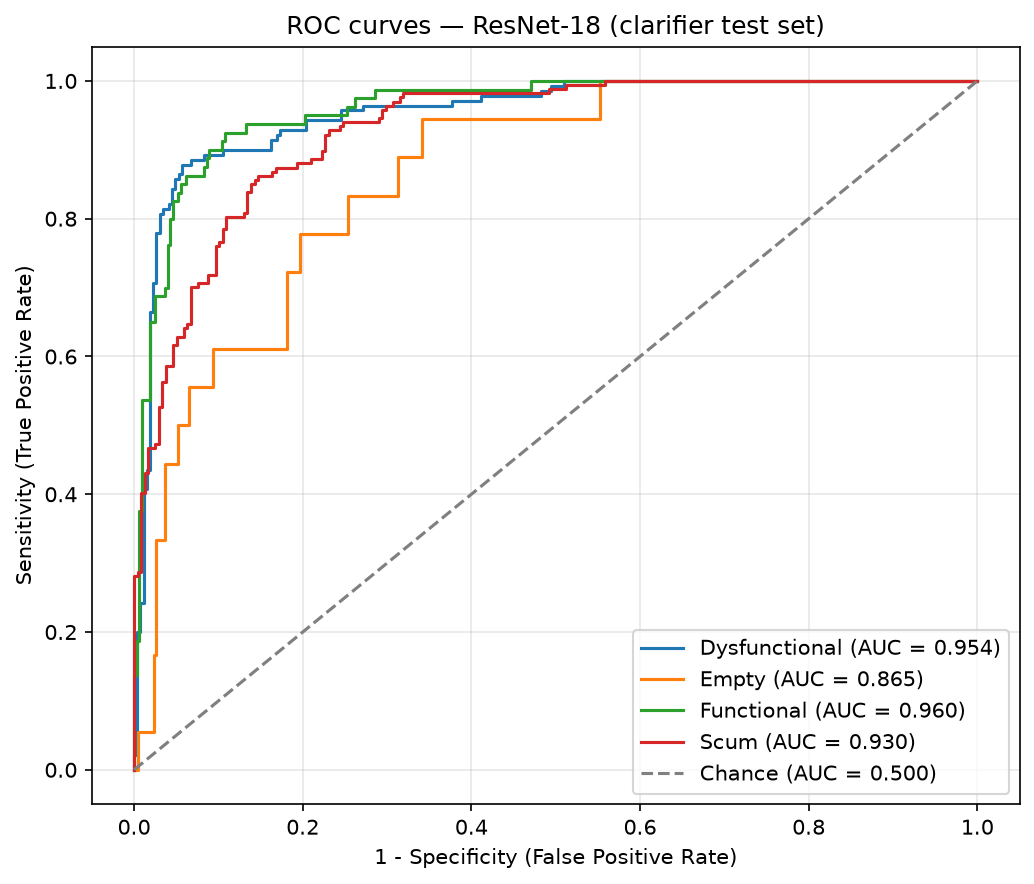

**ResNet-50** — test accuracy 0.726, mean AUC 0.901

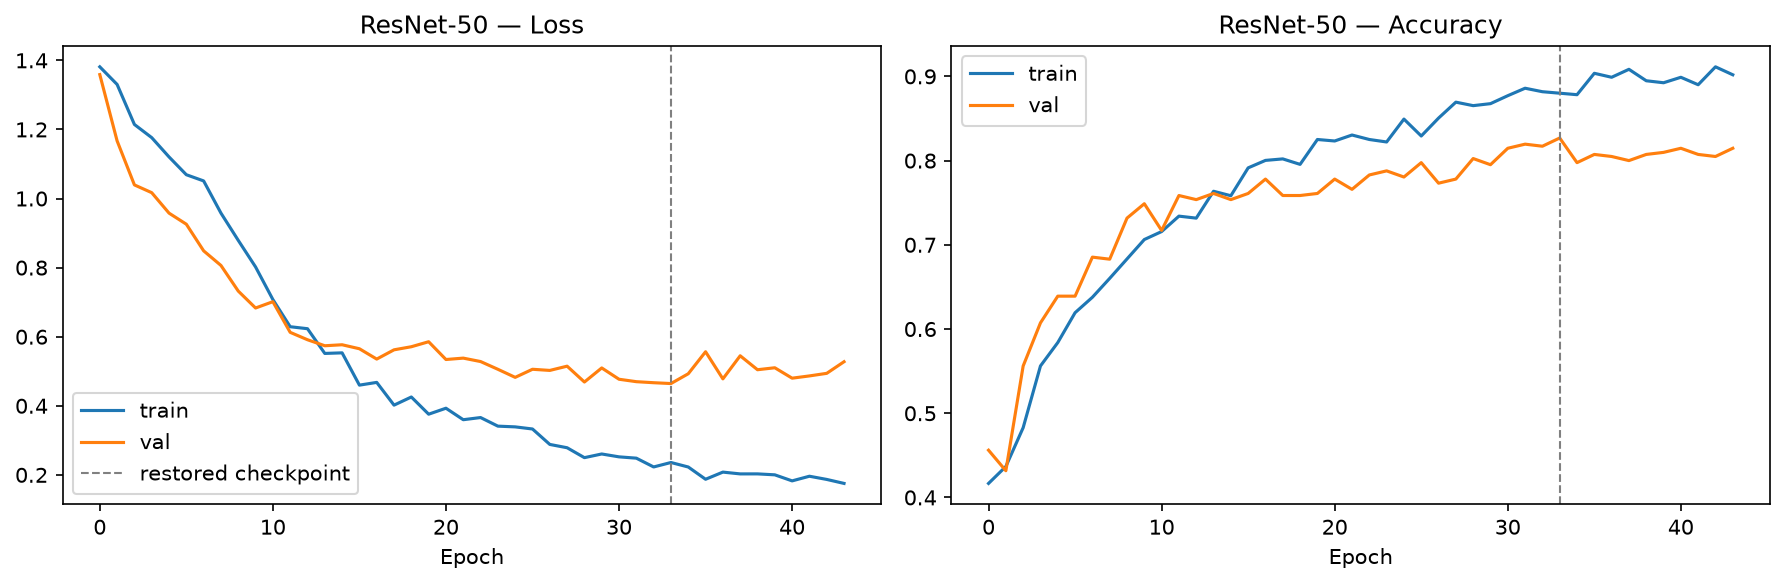

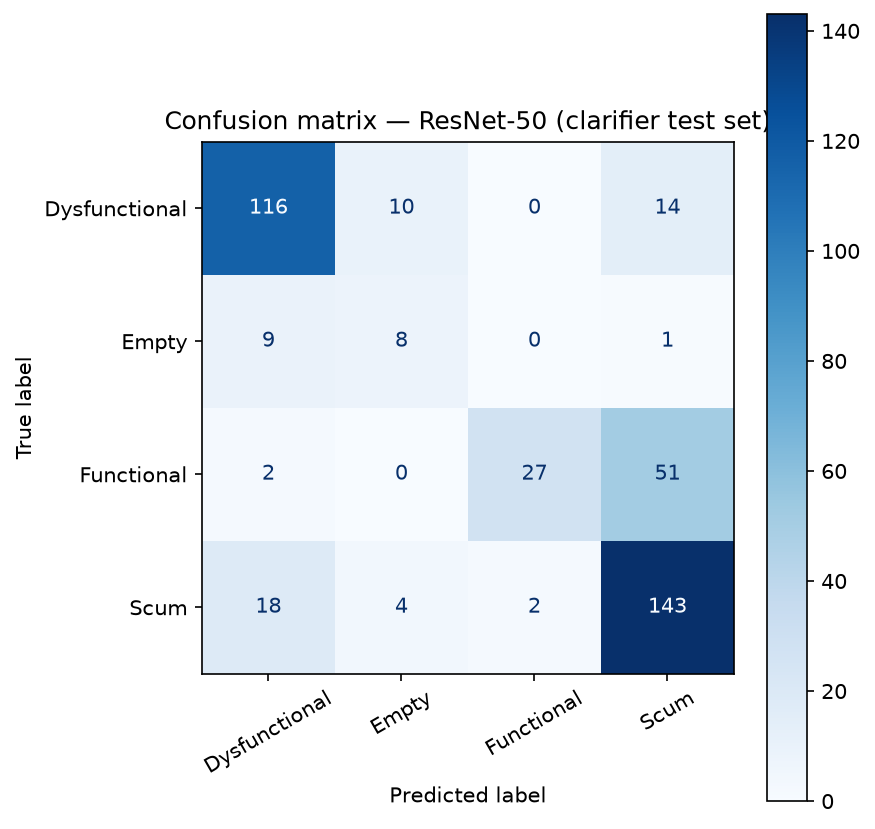

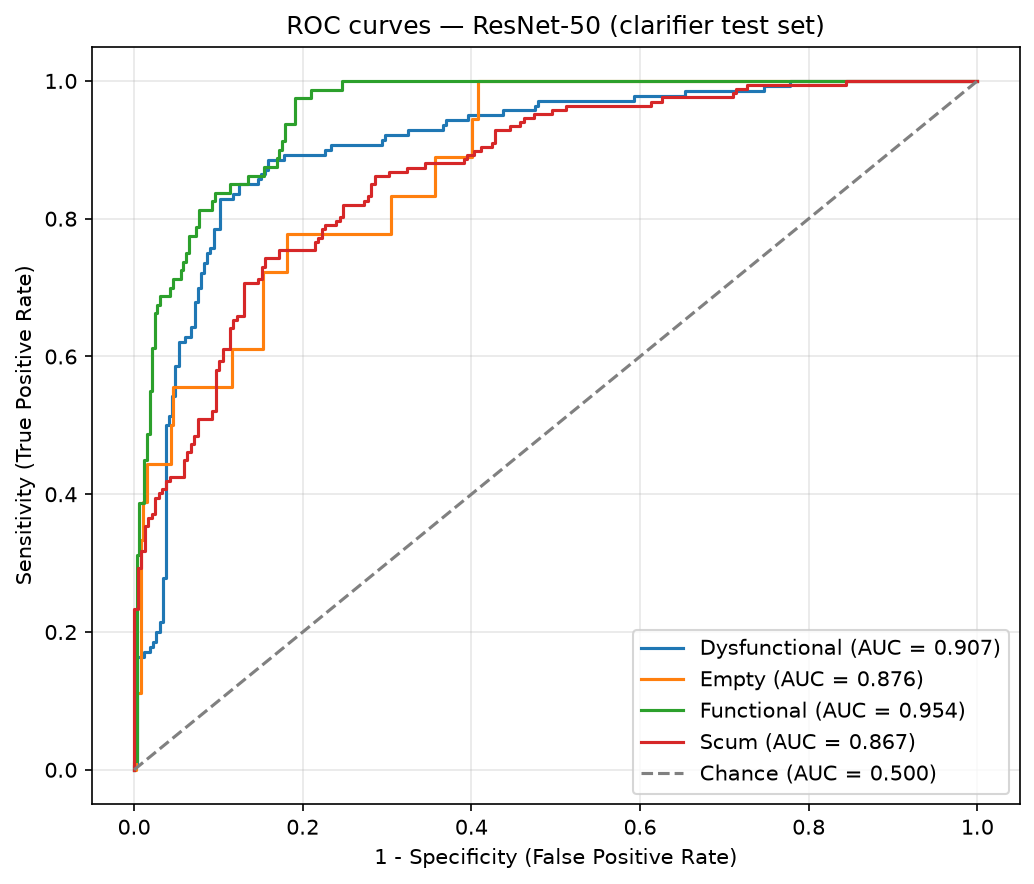

**DenseNet-121** — test accuracy 0.862, mean AUC 0.954

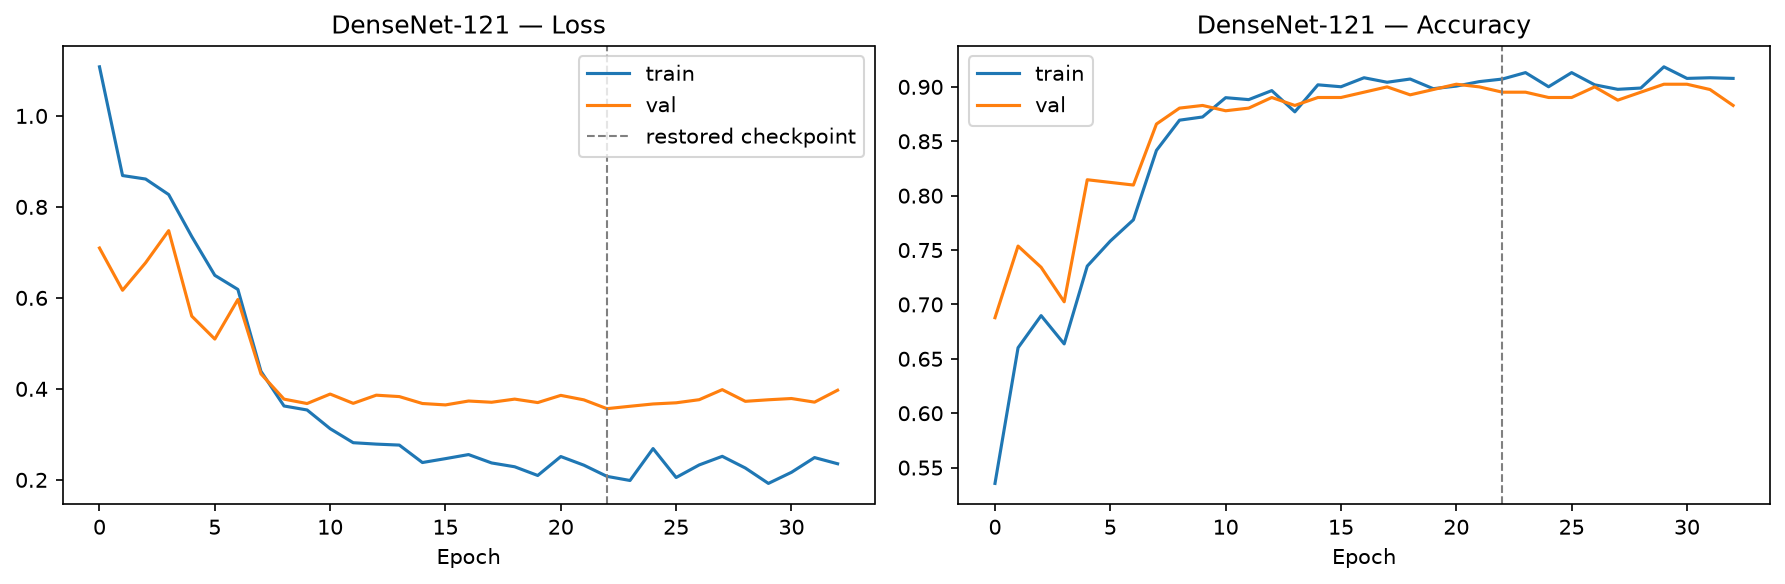

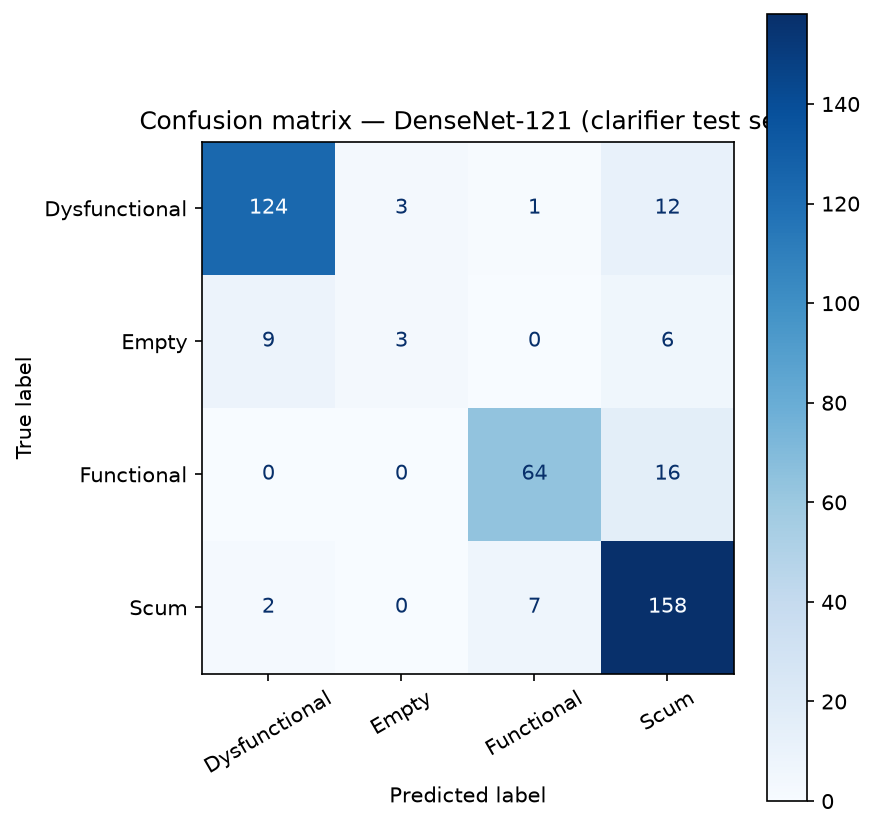

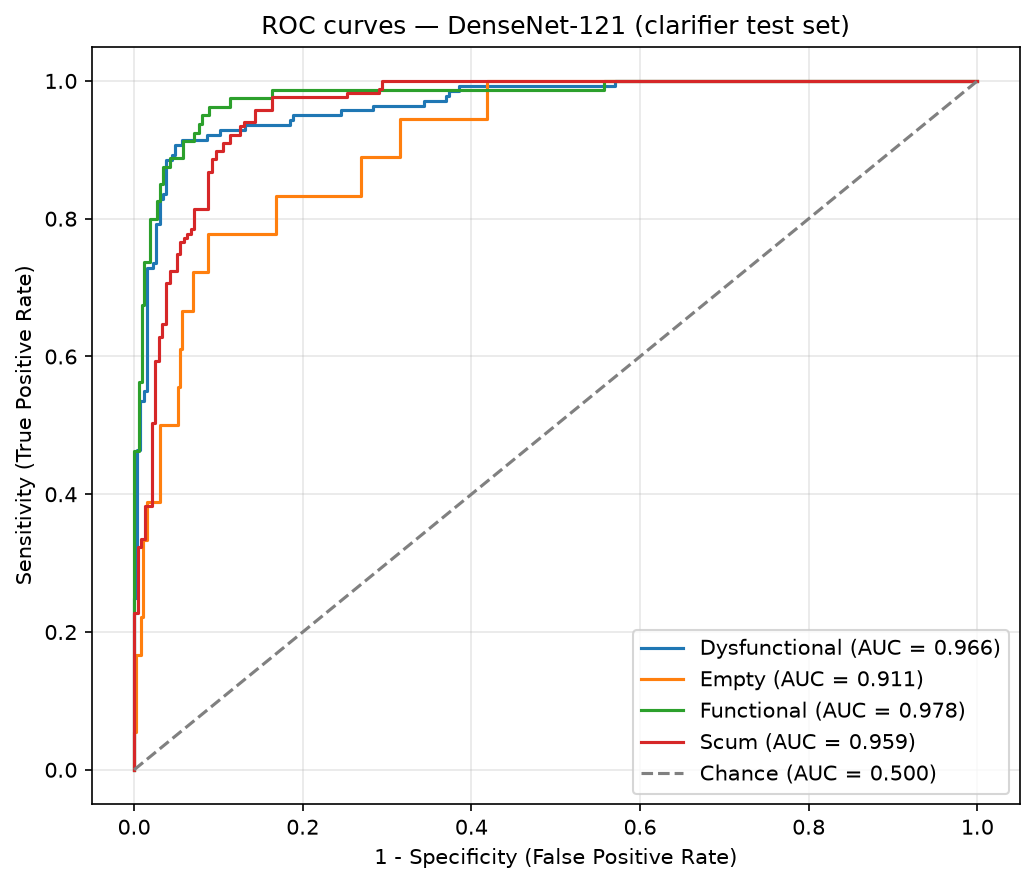

**InceptionNet v3** — test accuracy 0.753, mean AUC 0.919

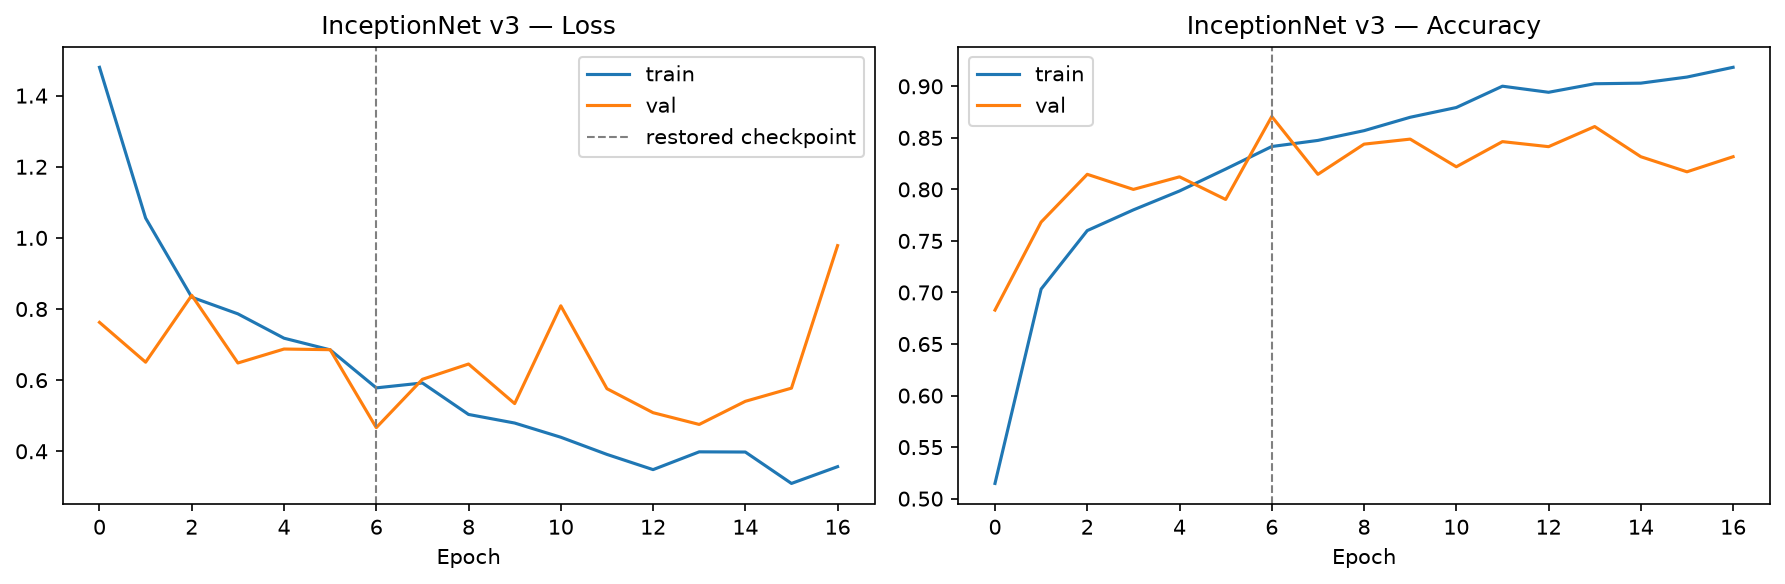

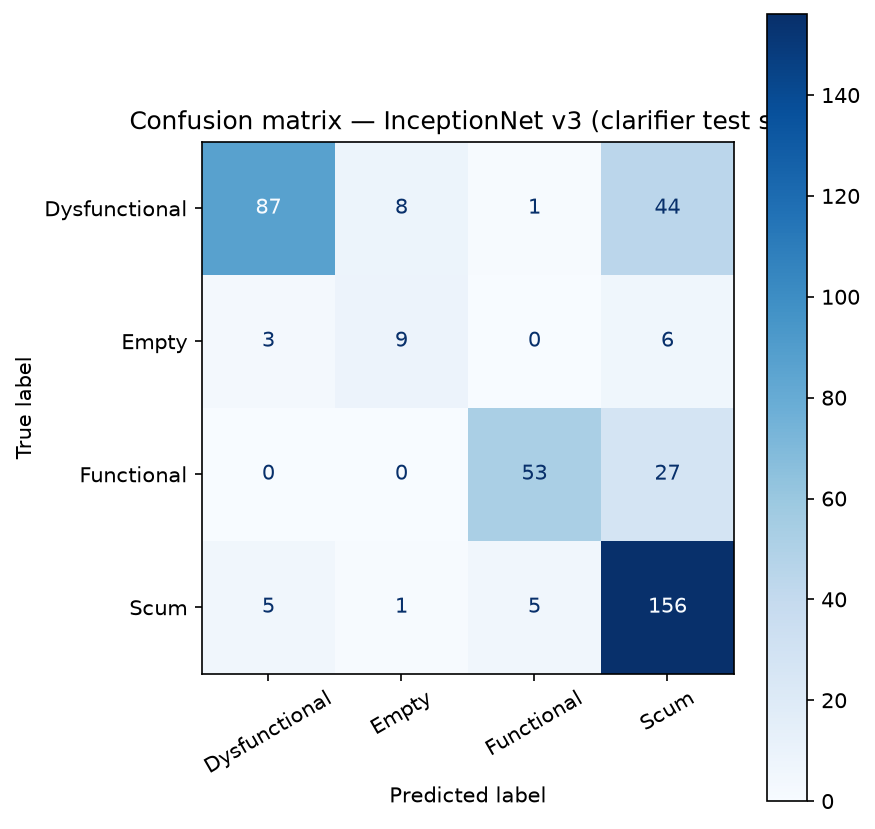

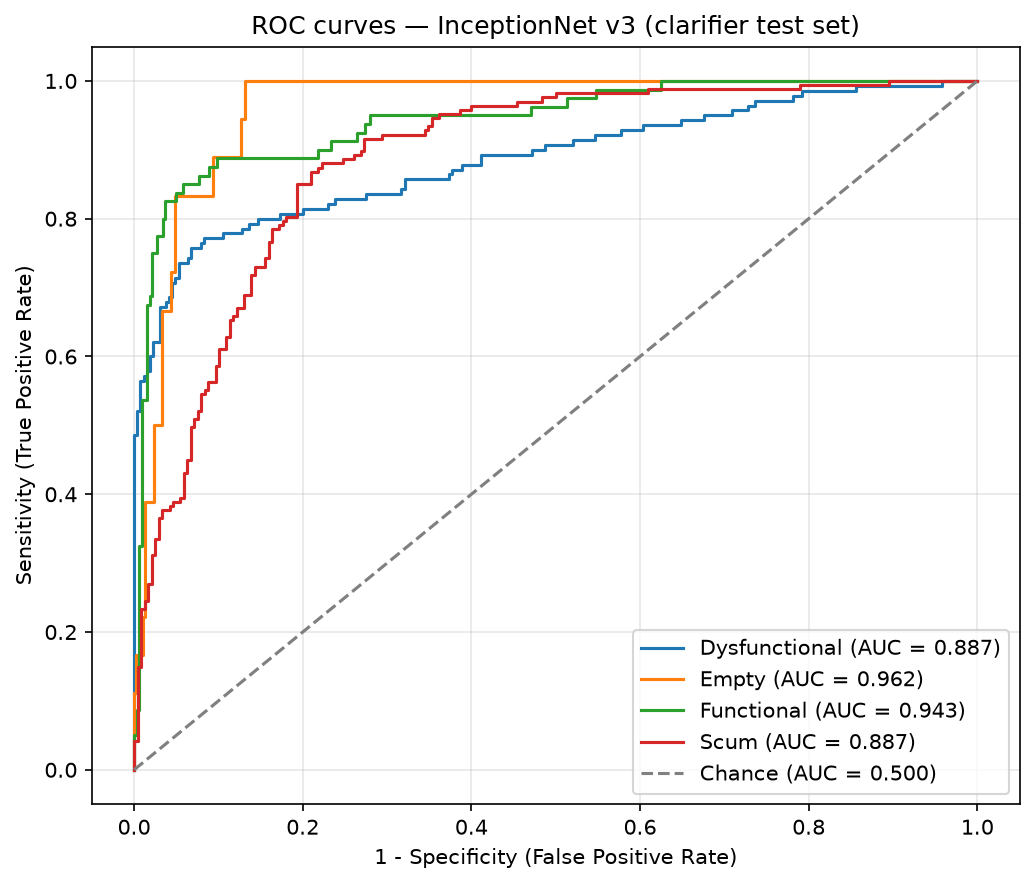

**EfficientNet-B0** — test accuracy 0.780, mean AUC 0.945

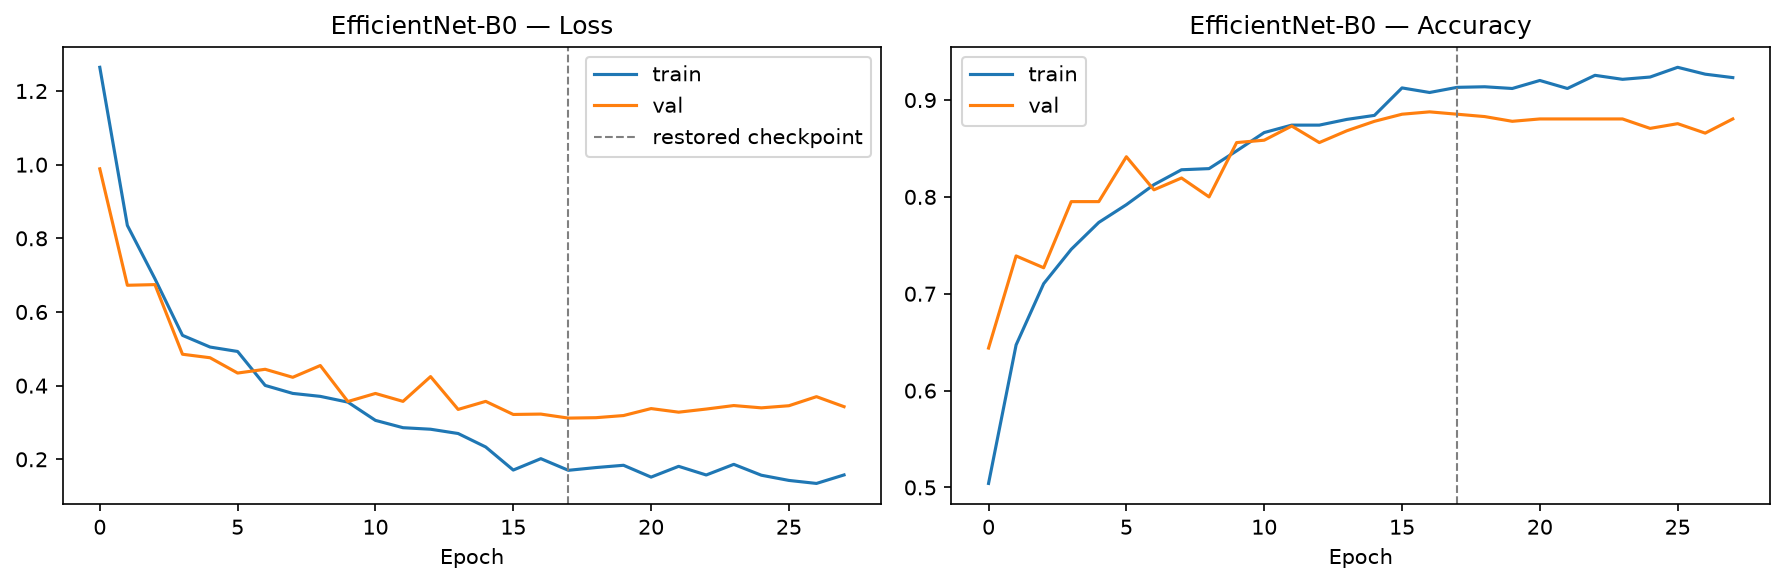

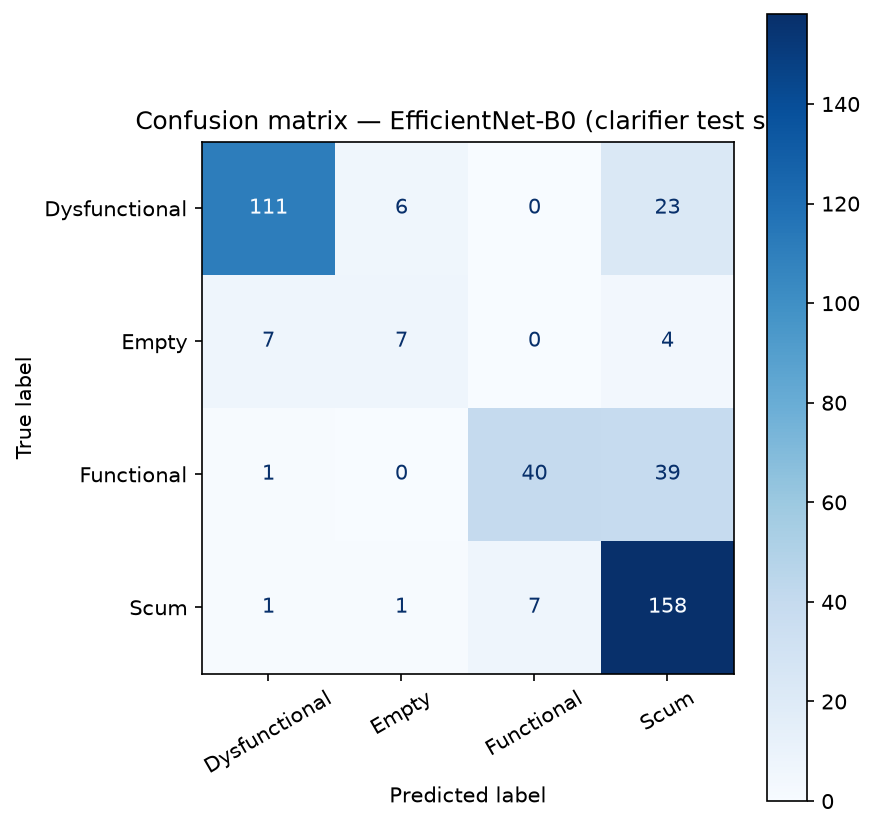

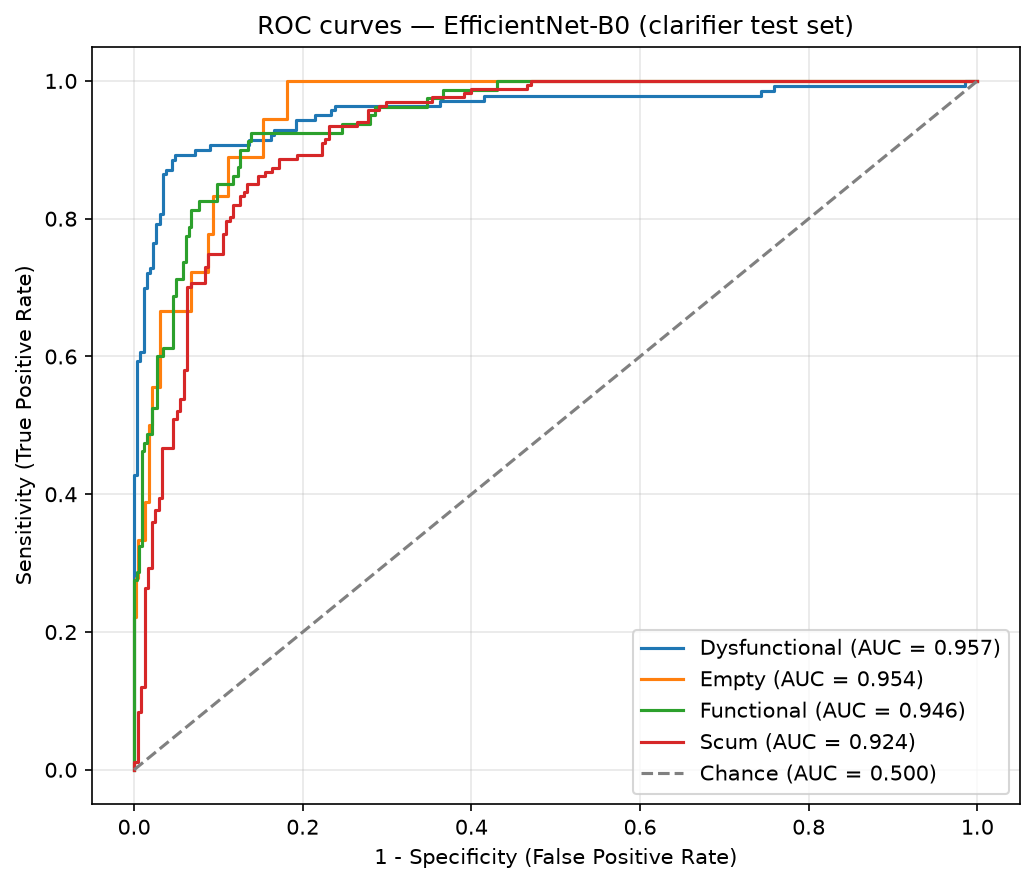

**ConvNeXt-Tiny** — test accuracy 0.798, mean AUC 0.922

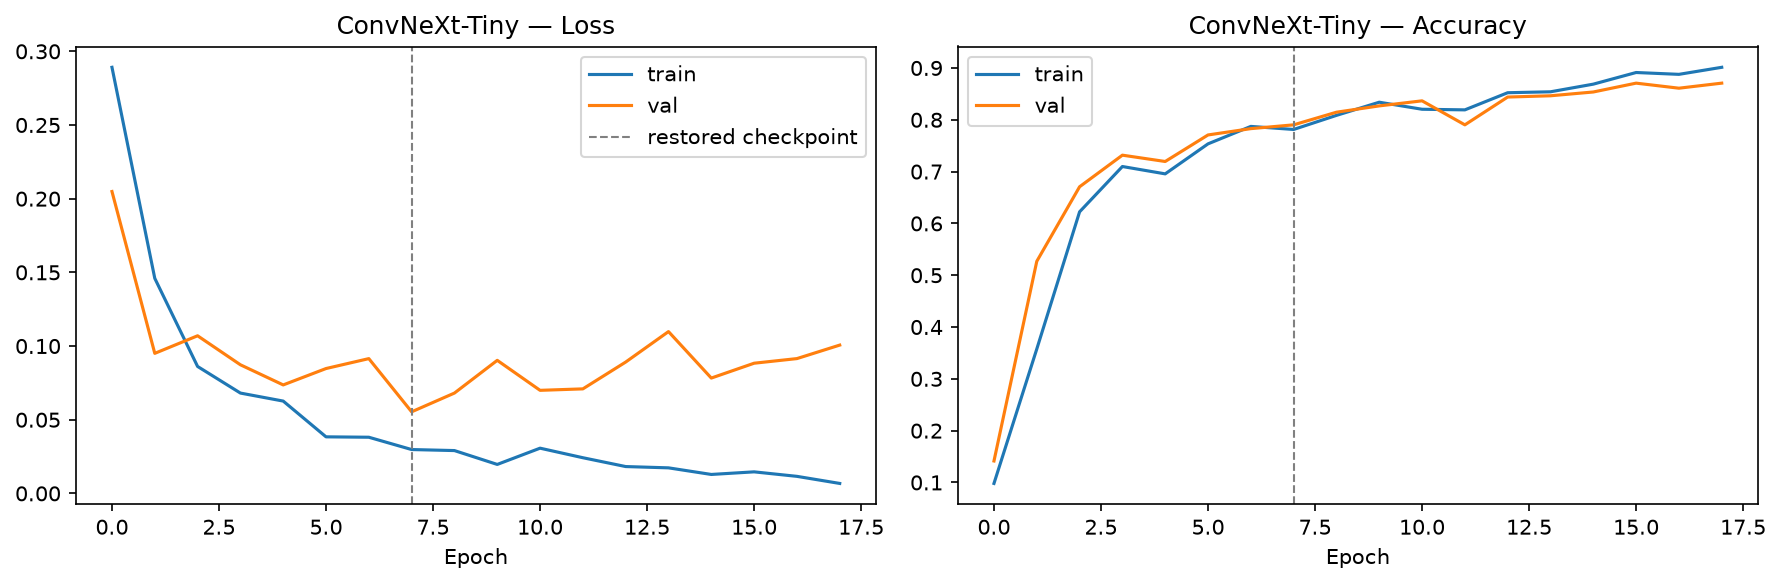

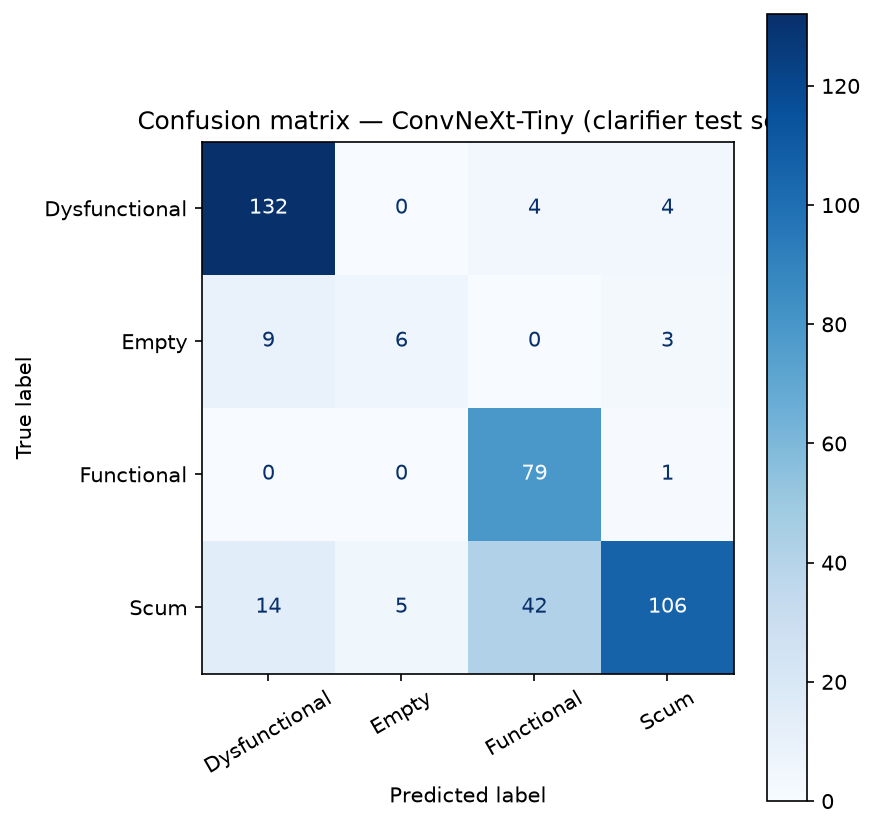

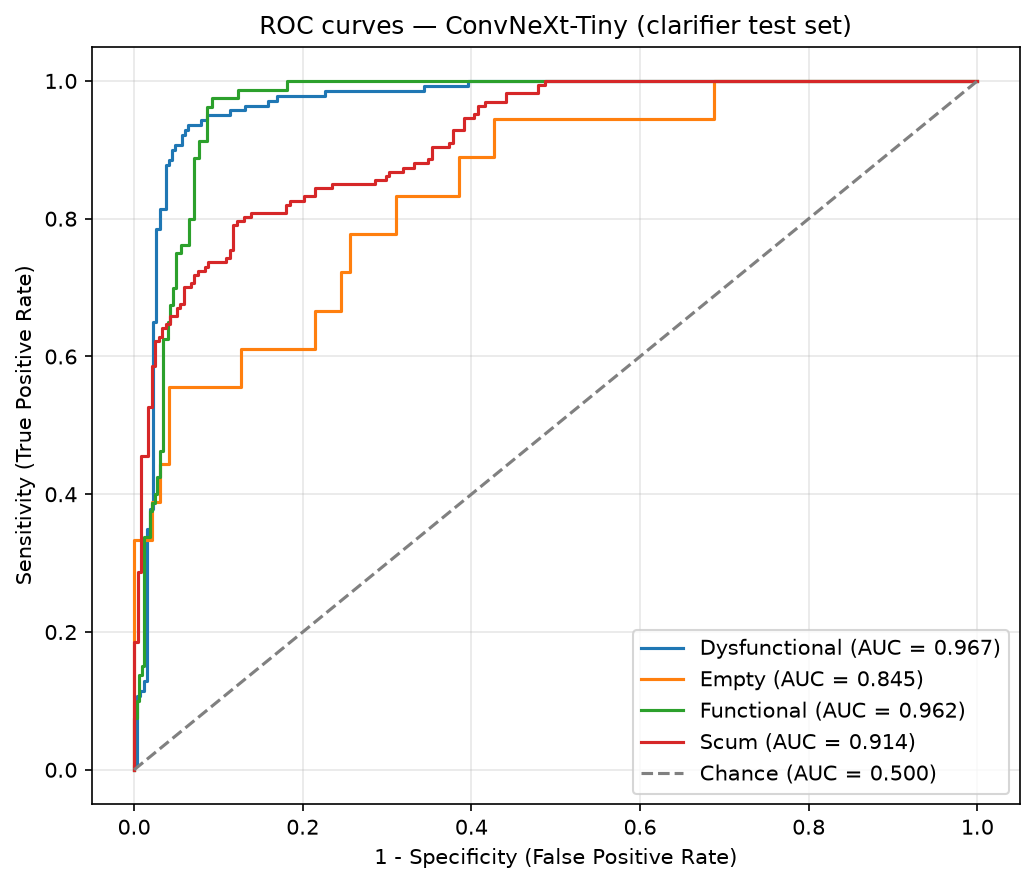

In [5]:
for facility, by_model in results.items():
    if not by_model:
        continue
    display(Markdown(f"### {facility} (held out)"))
    for save_name, r in by_model.items():
        model_name = r["model_name"]
        display(Markdown(f"**{MODELS[save_name]}** — test accuracy {r['test_acc']:.3f}, mean AUC {r['mean_auc']:.3f}"))

        for kind, label in [
            ("training_curves", "Training curves"),
            ("confusion_matrix", "Confusion matrix"),
            ("roc_auc", "ROC / AUC"),
        ]:
            path = figure_path(model_name, facility, kind)
            if path.exists():
                display(Image(filename=str(path)))
            else:
                print(f"  [missing] {label} figure not found: {path}")

## Precision / recall / F1 per class

Per-class breakdown (not just the macro average from the table above) for every
(facility, model) combination that has a persisted classification report.

In [6]:
for facility, by_model in results.items():
    for save_name, r in by_model.items():
        report = r.get("classification_report")
        if not report:
            continue
        class_rows = {
            cls: vals for cls, vals in report.items()
            if cls not in ("accuracy", "macro avg", "weighted avg")
        }
        df = pd.DataFrame(class_rows).T[["precision", "recall", "f1-score", "support"]]
        display(Markdown(f"**{facility} — {MODELS[save_name]}**"))
        display(df)

**Atlantis — ResNet-18**

,precision,recall,f1-score,support
Dysfunctional,0.000000,0.000000,0.000000,0.0
Empty,1.000000,1.000000,1.000000,3.0
Functional,0.673077,1.000000,0.804598,35.0
Scum,1.000000,0.673077,0.804598,52.0


**Atlantis — ResNet-50**

,precision,recall,f1-score,support
Dysfunctional,0.000000,0.000000,0.000000,0.0
Empty,0.750000,1.000000,0.857143,3.0
Functional,0.618182,0.971429,0.755556,35.0
Scum,0.965517,0.538462,0.691358,52.0


**Atlantis — DenseNet-121**

...

,precision,recall,f1-score,support
Dysfunctional,0.915789,0.621429,0.740426,140.0
Empty,0.500000,0.500000,0.500000,18.0
Functional,0.898305,0.662500,0.762590,80.0
Scum,0.669528,0.934132,0.780000,167.0


**NoordelikeWerke — EfficientNet-B0**

,precision,recall,f1-score,support
Dysfunctional,0.925000,0.792857,0.853846,140.0
Empty,0.500000,0.388889,0.437500,18.0
Functional,0.851064,0.500000,0.629921,80.0
Scum,0.705357,0.946108,0.808184,167.0


**NoordelikeWerke — ConvNeXt-Tiny**

,precision,recall,f1-score,support
Dysfunctional,0.851613,0.942857,0.894915,140.0
Empty,0.545455,0.333333,0.413793,18.0
Functional,0.632000,0.987500,0.770732,80.0
Scum,0.929825,0.634731,0.754448,167.0
